In [ ]:
import os

os.makedirs("/content/data/source", exist_ok=True)
os.makedirs("/content/data/reference", exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Chandrayaan-2 source image.jpeg to Chandrayaan-2 source image.jpeg


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving LRO NAC reference image.jpeg to LRO NAC reference image.jpeg


In [ ]:
import shutil
import os

shutil.move(
    "/content/Chandrayaan-2 source image.jpeg",
    "/content/data/source/source.jpeg"
)

shutil.move(
    "/content/LRO NAC reference image.jpeg",
    "/content/data/reference/reference.jpeg"
)

print("Images placed successfully.")

Images placed successfully.


In [ ]:
import os

print("Source folder:")
print(os.listdir("/content/data/source"))

print("\nReference folder:")
print(os.listdir("/content/data/reference"))

Source folder:
['source.jpeg']

Reference folder:
['reference.jpeg']


In [ ]:
import cv2

source = cv2.imread("/content/data/source/source.jpeg")
reference = cv2.imread("/content/data/reference/reference.jpeg")

print("Source loaded:", source is not None)
print("Reference loaded:", reference is not None)

if source is not None:
    print("Source size:", source.shape)

if reference is not None:
    print("Reference size:", reference.shape)

Source loaded: True
Reference loaded: True
Source size: (513, 146, 3)
Reference size: (528, 194, 3)


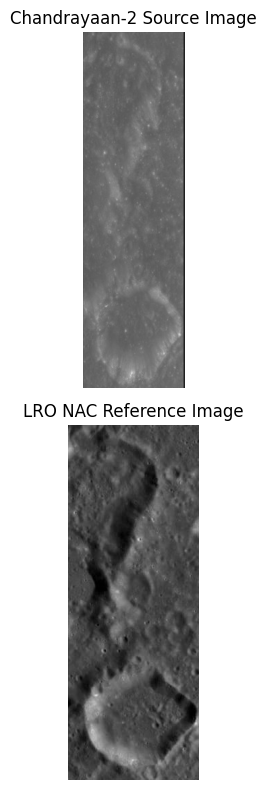

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))

plt.subplot(2, 1, 1)
plt.imshow(cv2.cvtColor(source, cv2.COLOR_BGR2RGB))
plt.title("Chandrayaan-2 Source Image")
plt.axis("off")

plt.subplot(2, 1, 2)
plt.imshow(cv2.cvtColor(reference, cv2.COLOR_BGR2RGB))
plt.title("LRO NAC Reference Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 1. Convert both images to grayscale
source_gray = cv2.cvtColor(source, cv2.COLOR_BGR2GRAY)
reference_gray = cv2.cvtColor(reference, cv2.COLOR_BGR2GRAY)

# 2. Create SIFT
sift = cv2.SIFT_create(nfeatures=5000)

# 3. Detect keypoints and descriptors
kp_source, des_source = sift.detectAndCompute(source_gray, None)
kp_reference, des_reference = sift.detectAndCompute(reference_gray, None)

# 4. Print results
print("Source image shape:", source_gray.shape)
print("Reference image shape:", reference_gray.shape)

print("Source keypoints:", len(kp_source))
print("Reference keypoints:", len(kp_reference))

print("Source descriptor shape:", des_source.shape if des_source is not None else None)
print("Reference descriptor shape:", des_reference.shape if des_reference is not None else None)

Source image shape: (513, 146)
Reference image shape: (528, 194)
Source keypoints: 48
Reference keypoints: 399
Source descriptor shape: (48, 128)
Reference descriptor shape: (399, 128)


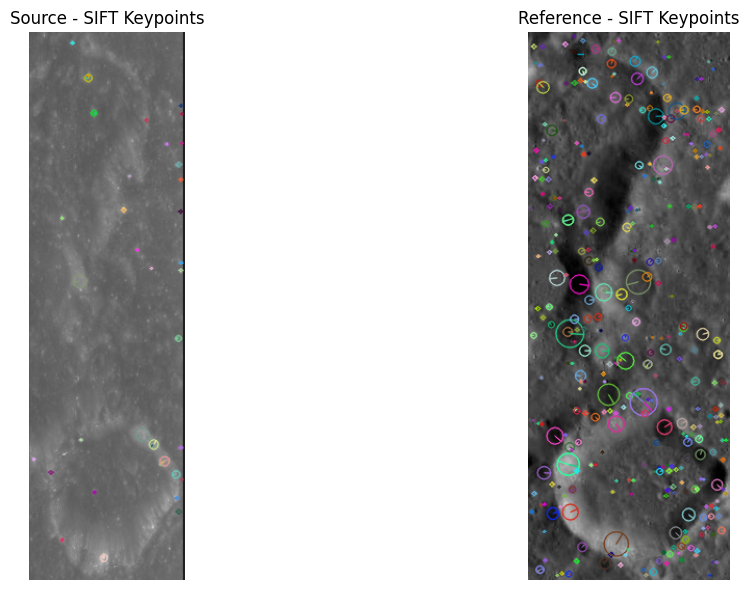

In [ ]:
source_kp_img = cv2.drawKeypoints(
    source_gray,
    kp_source,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

reference_kp_img = cv2.drawKeypoints(
    reference_gray,
    kp_reference,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(source_kp_img, cmap="gray")
plt.title("Source - SIFT Keypoints")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reference_kp_img, cmap="gray")
plt.title("Reference - SIFT Keypoints")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import cv2

# Create Brute-Force matcher
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

# Find 2 nearest neighbours for every source descriptor
knn_matches = bf.knnMatch(
    des_source,
    des_reference,
    k=2
)

print("Total source descriptors:", len(des_source))
print("KNN match pairs:", len(knn_matches))

# Lowe's ratio test
ratio_threshold = 0.75

good_matches = []

for pair in knn_matches:
    if len(pair) != 2:
        continue

    m, n = pair

    if m.distance < ratio_threshold * n.distance:
        good_matches.append(m)

print("Good matches after ratio test:", len(good_matches))

Total source descriptors: 48
KNN match pairs: 48
Good matches after ratio test: 2


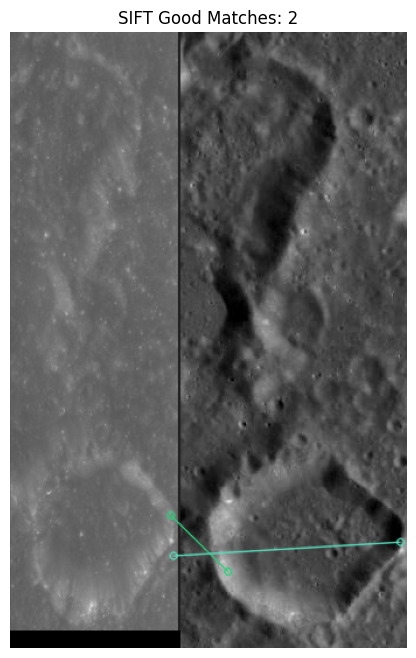

In [ ]:
import cv2
import matplotlib.pyplot as plt

match_img = cv2.drawMatches(
    source_gray,
    kp_source,
    reference_gray,
    kp_reference,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 8))
plt.imshow(match_img, cmap="gray")
plt.title(f"SIFT Good Matches: {len(good_matches)}")
plt.axis("off")
plt.show()

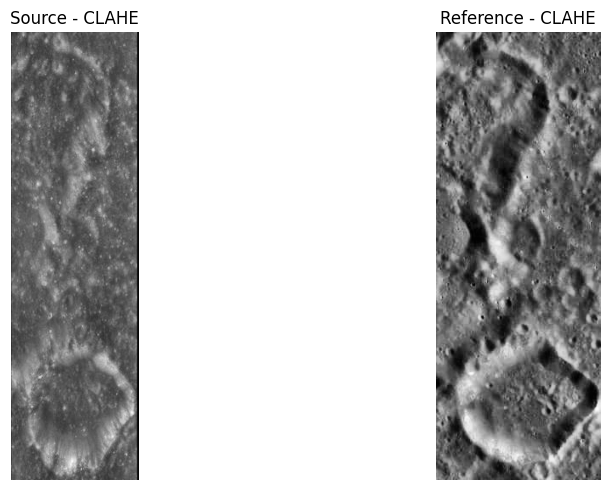

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Create CLAHE
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

# Apply CLAHE
source_clahe = clahe.apply(source_gray)
reference_clahe = clahe.apply(reference_gray)

# Display
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(source_clahe, cmap="gray")
plt.title("Source - CLAHE")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reference_clahe, cmap="gray")
plt.title("Reference - CLAHE")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
sift_clahe = cv2.SIFT_create(nfeatures=5000)

kp_source_c, des_source_c = sift_clahe.detectAndCompute(
    source_clahe, None
)

kp_reference_c, des_reference_c = sift_clahe.detectAndCompute(
    reference_clahe, None
)

print("Source keypoints after CLAHE:", len(kp_source_c))
print("Reference keypoints after CLAHE:", len(kp_reference_c))

Source keypoints after CLAHE: 481
Reference keypoints after CLAHE: 1441


In [ ]:
import cv2

bf_clahe = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

knn_matches_c = bf_clahe.knnMatch(
    des_source_c,
    des_reference_c,
    k=2
)

ratio_threshold = 0.75

good_matches_c = []

for pair in knn_matches_c:
    if len(pair) != 2:
        continue

    m, n = pair

    if m.distance < ratio_threshold * n.distance:
        good_matches_c.append(m)

print("Total source descriptors:", len(des_source_c))
print("KNN match pairs:", len(knn_matches_c))
print("Good matches after CLAHE + ratio test:", len(good_matches_c))

Total source descriptors: 481
KNN match pairs: 481
Good matches after CLAHE + ratio test: 5


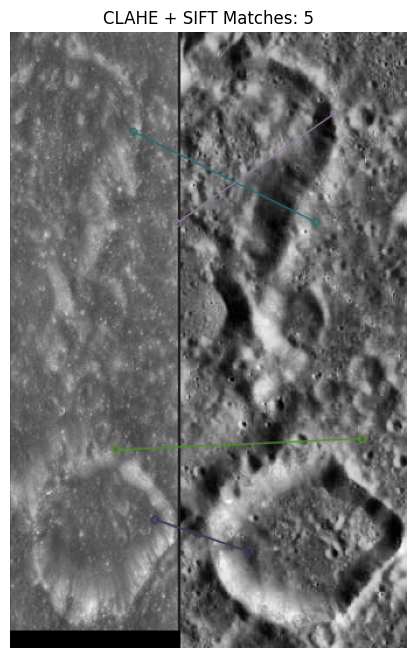

In [ ]:
import cv2
import matplotlib.pyplot as plt

match_img_c = cv2.drawMatches(
    source_clahe,
    kp_source_c,
    reference_clahe,
    kp_reference_c,
    good_matches_c,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 8))
plt.imshow(match_img_c, cmap="gray")
plt.title(f"CLAHE + SIFT Matches: {len(good_matches_c)}")
plt.axis("off")
plt.show()

In [ ]:
import cv2
import numpy as np

# Need at least 4 correspondences for homography
if len(good_matches_c) < 4:
    raise RuntimeError(
        f"Only {len(good_matches_c)} matches found. "
        "At least 4 are required for homography."
    )

# Source and reference coordinates
src_pts = np.float32([
    kp_source_c[m.queryIdx].pt
    for m in good_matches_c
]).reshape(-1, 1, 2)

ref_pts = np.float32([
    kp_reference_c[m.trainIdx].pt
    for m in good_matches_c
]).reshape(-1, 1, 2)

# RANSAC + homography
H, mask_c = cv2.findHomography(
    src_pts,
    ref_pts,
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=5000,
    confidence=0.995
)

print("Homography found:", H is not None)

if mask_c is not None:
    mask_c = mask_c.ravel()

    inlier_count = int(np.sum(mask_c))
    inlier_ratio = inlier_count / len(mask_c)

    print("Total candidate matches:", len(good_matches_c))
    print("RANSAC inliers:", inlier_count)
    print("RANSAC outliers:", len(good_matches_c) - inlier_count)
    print("Inlier ratio:", inlier_ratio)

Homography found: False
Total candidate matches: 5
RANSAC inliers: 0
RANSAC outliers: 5
Inlier ratio: 0.0


In [ ]:
import cv2

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

knn_matches = bf.knnMatch(
    des_source_c,
    des_reference_c,
    k=2
)

thresholds = [0.75, 0.80, 0.85, 0.90]

print("Ratio threshold comparison")
print("-" * 35)

for threshold in thresholds:
    good = []

    for pair in knn_matches:
        if len(pair) != 2:
            continue

        m, n = pair

        if m.distance < threshold * n.distance:
            good.append(m)

    print(f"Threshold {threshold:.2f}: {len(good)} matches")

Ratio threshold comparison
-----------------------------------
Threshold 0.75: 5 matches
Threshold 0.80: 7 matches
Threshold 0.85: 27 matches
Threshold 0.90: 63 matches


In [ ]:
import cv2
import numpy as np

thresholds = [0.75, 0.80, 0.85, 0.90]

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

knn_matches = bf.knnMatch(
    des_source_c,
    des_reference_c,
    k=2
)

print("RANSAC comparison")
print("=" * 60)

for threshold in thresholds:

    # -----------------------------
    # 1. Ratio test
    # -----------------------------
    good = []

    for pair in knn_matches:
        if len(pair) != 2:
            continue

        m, n = pair

        if m.distance < threshold * n.distance:
            good.append(m)

    print(f"\nRatio threshold: {threshold}")
    print(f"Candidate matches: {len(good)}")

    # -----------------------------
    # 2. Need at least 4 matches
    # -----------------------------
    if len(good) < 4:
        print("RANSAC: Not enough matches")
        continue

    # -----------------------------
    # 3. Prepare points
    # -----------------------------
    src_pts = np.float32([
        kp_source_c[m.queryIdx].pt
        for m in good
    ]).reshape(-1, 1, 2)

    ref_pts = np.float32([
        kp_reference_c[m.trainIdx].pt
        for m in good
    ]).reshape(-1, 1, 2)

    # -----------------------------
    # 4. RANSAC
    # -----------------------------
    H, mask = cv2.findHomography(
        src_pts,
        ref_pts,
        method=cv2.RANSAC,
        ransacReprojThreshold=3.0,
        maxIters=5000,
        confidence=0.995
    )

    if H is None or mask is None:
        print("Homography: FAILED")
        print("Inliers: 0")
        print("Inlier ratio: 0.000")
        continue

    mask = mask.ravel()

    inliers = int(np.sum(mask))
    ratio = inliers / len(good)

    print("Homography: FOUND")
    print(f"Inliers: {inliers}")
    print(f"Inlier ratio: {ratio:.3f}")

RANSAC comparison

Ratio threshold: 0.75
Candidate matches: 5
Homography: FAILED
Inliers: 0
Inlier ratio: 0.000

Ratio threshold: 0.8
Candidate matches: 7
Homography: FAILED
Inliers: 0
Inlier ratio: 0.000

Ratio threshold: 0.85
Candidate matches: 27
Homography: FOUND
Inliers: 7
Inlier ratio: 0.259

Ratio threshold: 0.9
Candidate matches: 63
Homography: FOUND
Inliers: 9
Inlier ratio: 0.143


Candidate matches: 27
Inlier matches: 7


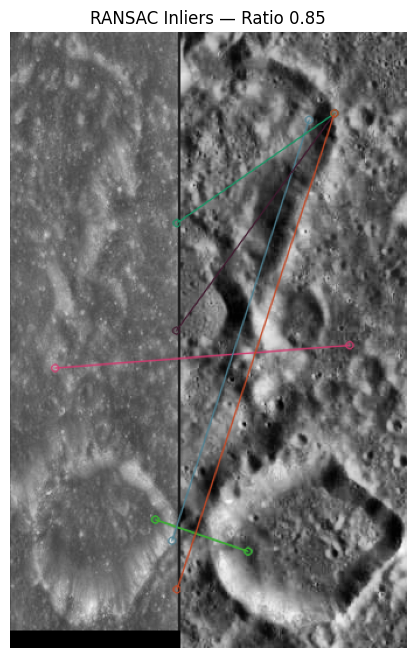

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Recreate the good matches at ratio = 0.85
threshold = 0.85

good_085 = []

for pair in knn_matches:
    if len(pair) != 2:
        continue

    m, n = pair

    if m.distance < threshold * n.distance:
        good_085.append(m)

# Build point arrays
src_pts_085 = np.float32([
    kp_source_c[m.queryIdx].pt
    for m in good_085
]).reshape(-1, 1, 2)

ref_pts_085 = np.float32([
    kp_reference_c[m.trainIdx].pt
    for m in good_085
]).reshape(-1, 1, 2)

# RANSAC
H_085, mask_085 = cv2.findHomography(
    src_pts_085,
    ref_pts_085,
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=5000,
    confidence=0.995
)

mask_085 = mask_085.ravel()

# Keep only inliers
inlier_matches_085 = [
    m for m, keep in zip(good_085, mask_085)
    if keep
]

print("Candidate matches:", len(good_085))
print("Inlier matches:", len(inlier_matches_085))

# Draw ONLY inliers
inlier_img = cv2.drawMatches(
    source_clahe,
    kp_source_c,
    reference_clahe,
    kp_reference_c,
    inlier_matches_085,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 8))
plt.imshow(inlier_img, cmap="gray")
plt.title("RANSAC Inliers — Ratio 0.85")
plt.axis("off")
plt.show()

In [ ]:
import numpy as np

# Source image dimensions
h, w = source_clahe.shape

# 3x3 grid
rows, cols = 3, 3

grid_counts = np.zeros((rows, cols), dtype=int)

for m in inlier_matches_085:
    x, y = kp_source_c[m.queryIdx].pt

    col = min(int(x / (w / cols)), cols - 1)
    row = min(int(y / (h / rows)), rows - 1)

    grid_counts[row, col] += 1

print("3 x 3 spatial distribution of RANSAC inliers:")
print(grid_counts)

print("\nTotal inliers:", grid_counts.sum())

3 x 3 spatial distribution of RANSAC inliers:
[[0 0 1]
 [1 0 1]
 [0 0 4]]

Total inliers: 7


In [ ]:
import cv2

bf_cross = cv2.BFMatcher(
    cv2.NORM_L2,
    crossCheck=True
)

cross_matches = bf_cross.match(
    des_source_c,
    des_reference_c
)

# Sort by descriptor distance
cross_matches = sorted(
    cross_matches,
    key=lambda m: m.distance
)

print("Cross-check matches:", len(cross_matches))

# Show the best 30
best_cross_matches = cross_matches[:30]

print("Showing:", len(best_cross_matches), "best cross-check matches")

Cross-check matches: 240
Showing: 30 best cross-check matches


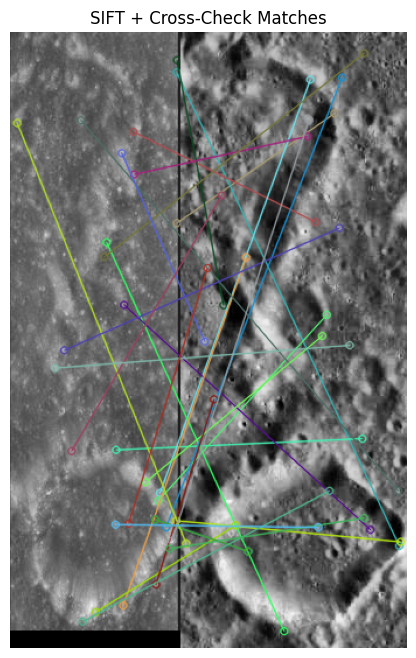

In [ ]:
import matplotlib.pyplot as plt

cross_img = cv2.drawMatches(
    source_clahe,
    kp_source_c,
    reference_clahe,
    kp_reference_c,
    best_cross_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 8))
plt.imshow(cross_img, cmap="gray")
plt.title("SIFT + Cross-Check Matches")
plt.axis("off")
plt.show()

In [ ]:
import cv2
import numpy as np

# Use ALL cross-check matches
cross_matches_all = cross_matches

if len(cross_matches_all) < 4:
    raise RuntimeError("Not enough cross-check matches for homography.")

# Source points
src_pts_cross = np.float32([
    kp_source_c[m.queryIdx].pt
    for m in cross_matches_all
]).reshape(-1, 1, 2)

# Reference points
ref_pts_cross = np.float32([
    kp_reference_c[m.trainIdx].pt
    for m in cross_matches_all
]).reshape(-1, 1, 2)

# RANSAC
H_cross, mask_cross = cv2.findHomography(
    src_pts_cross,
    ref_pts_cross,
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=5000,
    confidence=0.995
)

if H_cross is None or mask_cross is None:
    print("Homography: FAILED")
    print("Inliers: 0")
    print("Inlier ratio: 0.0")
else:
    mask_cross = mask_cross.ravel()

    inlier_count_cross = int(np.sum(mask_cross))
    inlier_ratio_cross = inlier_count_cross / len(cross_matches_all)

    print("Homography: FOUND")
    print("Total cross-check matches:", len(cross_matches_all))
    print("RANSAC inliers:", inlier_count_cross)
    print("RANSAC outliers:", len(cross_matches_all) - inlier_count_cross)
    print("Inlier ratio:", inlier_ratio_cross)

Homography: FOUND
Total cross-check matches: 240
RANSAC inliers: 7
RANSAC outliers: 233
Inlier ratio: 0.029166666666666667


In [ ]:
print("Source:", source_gray.shape)
print("Reference:", reference_gray.shape)

print("Source min/max:", source_gray.min(), source_gray.max())
print("Reference min/max:", reference_gray.min(), reference_gray.max())

Source: (513, 146)
Reference: (528, 194)
Source min/max: 32 224
Reference min/max: 0 227


In [ ]:
import os

print(
    "Source file size:",
    os.path.getsize("/content/data/source/source.jpeg"),
    "bytes"
)

print(
    "Reference file size:",
    os.path.getsize("/content/data/reference/reference.jpeg"),
    "bytes"
)

Source file size: 14760 bytes
Reference file size: 12891 bytes


In [ ]:
from PIL import Image
import os

source_path = "/content/data/source/source.jpeg"
reference_path = "/content/data/reference/reference.jpeg"

source_pil = Image.open(source_path)
reference_pil = Image.open(reference_path)

print("SOURCE")
print("Format:", source_pil.format)
print("Size:", source_pil.size)
print("Mode:", source_pil.mode)
print("DPI:", source_pil.info.get("dpi"))
print("EXIF:", bool(source_pil.getexif()))

print("\nREFERENCE")
print("Format:", reference_pil.format)
print("Size:", reference_pil.size)
print("Mode:", reference_pil.mode)
print("DPI:", reference_pil.info.get("dpi"))
print("EXIF:", bool(reference_pil.getexif()))

SOURCE
Format: JPEG
Size: (146, 513)
Mode: RGB
DPI: None
EXIF: False

REFERENCE
Format: JPEG
Size: (194, 528)
Mode: RGB
DPI: None
EXIF: False


Synthetic test created.
Known scale: 1.5
Known rotation: 10
Known translation: (20, 15)


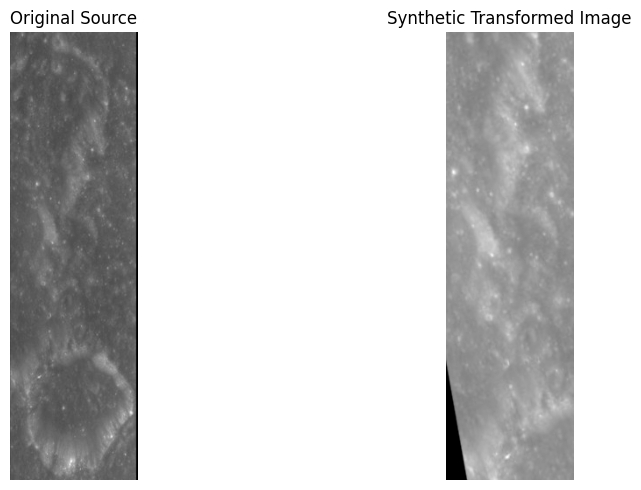

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Start from the source grayscale image
test_img = source_gray.copy()

h, w = test_img.shape

# Create a known scale + rotation + translation
scale = 1.5
angle = 10
tx = 20
ty = 15

center = (w / 2, h / 2)

M = cv2.getRotationMatrix2D(
    center,
    angle,
    scale
)

M[0, 2] += tx
M[1, 2] += ty

synthetic = cv2.warpAffine(
    test_img,
    M,
    (w, h)
)

print("Synthetic test created.")
print("Known scale:", scale)
print("Known rotation:", angle)
print("Known translation:", (tx, ty))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(test_img, cmap="gray")
plt.title("Original Source")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(synthetic, cmap="gray")
plt.title("Synthetic Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np

# SIFT
sift_test = cv2.SIFT_create(nfeatures=5000)

kp_original, des_original = sift_test.detectAndCompute(
    test_img, None
)

kp_synthetic, des_synthetic = sift_test.detectAndCompute(
    synthetic, None
)

print("Original keypoints:", len(kp_original))
print("Synthetic keypoints:", len(kp_synthetic))

# BF matcher
bf_test = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

knn_test = bf_test.knnMatch(
    des_synthetic,
    des_original,
    k=2
)

# Ratio test
ratio = 0.75

good_test = []

for pair in knn_test:
    if len(pair) != 2:
        continue

    m, n = pair

    if m.distance < ratio * n.distance:
        good_test.append(m)

print("Good matches:", len(good_test))

Original keypoints: 48
Synthetic keypoints: 26
Good matches: 5


In [ ]:
import cv2
import numpy as np

# Prepare matched points
src_pts_test = np.float32([
    kp_synthetic[m.queryIdx].pt
    for m in good_test
]).reshape(-1, 1, 2)

ref_pts_test = np.float32([
    kp_original[m.trainIdx].pt
    for m in good_test
]).reshape(-1, 1, 2)

print("Candidate matches:", len(good_test))

# RANSAC affine transformation
M_est, inlier_mask = cv2.estimateAffinePartial2D(
    src_pts_test,
    ref_pts_test,
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=5000,
    confidence=0.995
)

if M_est is None or inlier_mask is None:
    print("Affine estimation: FAILED")
else:
    inlier_mask = inlier_mask.ravel()

    inliers = int(np.sum(inlier_mask))
    inlier_ratio = inliers / len(good_test)

    print("Affine estimation: FOUND")
    print("Inliers:", inliers)
    print("Inlier ratio:", inlier_ratio)

    print("\nEstimated transformation:")
    print(M_est)

Candidate matches: 5
Affine estimation: FOUND
Inliers: 4
Inlier ratio: 0.8

Estimated transformation:
[[ 0.65651754 -0.11583307 43.48405671]
 [ 0.11583307  0.65651754 67.52649716]]


In [ ]:
import numpy as np
import math

# Estimated matrix from your result
a = M_est[0, 0]
b = M_est[0, 1]
c = M_est[1, 0]
d = M_est[1, 1]

# Estimated scale
estimated_scale = np.sqrt(a*a + c*c)

# Estimated rotation
estimated_angle = math.degrees(math.atan2(c, a))

print("Estimated scale:", estimated_scale)
print("Estimated rotation:", estimated_angle)
print("Estimated translation:", M_est[:, 2])

# Expected inverse transformation
true_scale_inverse = 1 / 1.5
true_angle_inverse = -10

A = np.array([
    [1.5 * math.cos(math.radians(10)),
     -1.5 * math.sin(math.radians(10))],
    [1.5 * math.sin(math.radians(10)),
      1.5 * math.cos(math.radians(10))]
])

true_translation = np.array([20, 15])

A_inv = np.linalg.inv(A)
true_inverse_translation = -A_inv @ true_translation

print("\nExpected inverse scale:", true_scale_inverse)
print("Expected inverse rotation:", true_angle_inverse)
print("Expected inverse translation:", true_inverse_translation)

Estimated scale: 0.6666577657600857
Estimated rotation: 10.006035977333372
Estimated translation: [43.48405671 67.52649716]

Expected inverse scale: 0.6666666666666666
Expected inverse rotation: -10
Expected inverse translation: [-14.86725182  -7.53276849]


In [ ]:
import cv2

# More sensitive SIFT configuration
sift_sensitive = cv2.SIFT_create(
    nfeatures=10000,
    contrastThreshold=0.01,
    edgeThreshold=10,
    sigma=1.6
)

kp_original_s, des_original_s = sift_sensitive.detectAndCompute(
    test_img, None
)

kp_synthetic_s, des_synthetic_s = sift_sensitive.detectAndCompute(
    synthetic, None
)

print("Sensitive SIFT")
print("----------------")
print("Original keypoints:", len(kp_original_s))
print("Synthetic keypoints:", len(kp_synthetic_s))

Sensitive SIFT
----------------
Original keypoints: 911
Synthetic keypoints: 661


In [ ]:
import cv2

bf_sensitive = cv2.BFMatcher(
    cv2.NORM_L2,
    crossCheck=False
)

knn_sensitive = bf_sensitive.knnMatch(
    des_synthetic_s,
    des_original_s,
    k=2
)

ratio = 0.75

good_sensitive = []

for pair in knn_sensitive:
    if len(pair) != 2:
        continue

    m, n = pair

    if m.distance < ratio * n.distance:
        good_sensitive.append(m)

print("Sensitive SIFT")
print("----------------")
print("Candidate KNN pairs:", len(knn_sensitive))
print("Good matches:", len(good_sensitive))

Sensitive SIFT
----------------
Candidate KNN pairs: 661
Good matches: 226


In [ ]:
import cv2
import numpy as np

# Prepare matched points
src_pts_sensitive = np.float32([
    kp_synthetic_s[m.queryIdx].pt
    for m in good_sensitive
]).reshape(-1, 1, 2)

ref_pts_sensitive = np.float32([
    kp_original_s[m.trainIdx].pt
    for m in good_sensitive
]).reshape(-1, 1, 2)

print("Candidate matches:", len(good_sensitive))

# Estimate affine transformation with RANSAC
M_sensitive, mask_sensitive = cv2.estimateAffinePartial2D(
    src_pts_sensitive,
    ref_pts_sensitive,
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=10000,
    confidence=0.999
)

if M_sensitive is None or mask_sensitive is None:
    print("Affine estimation: FAILED")
else:
    mask_sensitive = mask_sensitive.ravel()

    inliers = int(np.sum(mask_sensitive))
    inlier_ratio = inliers / len(good_sensitive)

    print("Affine estimation: FOUND")
    print("Inliers:", inliers)
    print("Outliers:", len(good_sensitive) - inliers)
    print("Inlier ratio:", inlier_ratio)

    print("\nEstimated transformation:")
    print(M_sensitive)

Candidate matches: 226
Affine estimation: FOUND
Inliers: 220
Outliers: 6
Inlier ratio: 0.9734513274336283

Estimated transformation:
[[ 0.65659815 -0.11570714 43.46649759]
 [ 0.11570714  0.65659815 67.53381509]]


In [ ]:
import cv2
import numpy as np

# Select a set of points across the ORIGINAL image
h, w = test_img.shape

test_points = np.float32([
    [w * 0.10, h * 0.10],
    [w * 0.50, h * 0.10],
    [w * 0.90, h * 0.10],
    [w * 0.10, h * 0.50],
    [w * 0.50, h * 0.50],
    [w * 0.90, h * 0.50],
    [w * 0.10, h * 0.90],
    [w * 0.50, h * 0.90],
    [w * 0.90, h * 0.90]
], dtype=np.float32)

# Convert our 2x3 affine matrices into 3x3 form
M_true_3x3 = np.vstack([
    M,
    [0, 0, 1]
])

M_est_3x3 = np.vstack([
    M_sensitive,
    [0, 0, 1]
])

# Transform original points using the TRUE transformation
original_h = np.hstack([
    test_points,
    np.ones((len(test_points), 1), dtype=np.float32)
])

synthetic_points = (
    M_true_3x3 @ original_h.T
).T

synthetic_points = synthetic_points[:, :2]

# Transform synthetic points back using ESTIMATED inverse transformation
recovered_points = (
    M_est_3x3 @
    np.hstack([
        synthetic_points,
        np.ones((len(synthetic_points), 1), dtype=np.float32)
    ]).T
).T

recovered_points = recovered_points[:, :2]

# Point-wise error
errors = np.linalg.norm(
    test_points - recovered_points,
    axis=1
)

print("Point-wise reconstruction errors:")
print(errors)

print("\nMean error:", np.mean(errors))
print("RMSE:", np.sqrt(np.mean(errors ** 2)))

TypeError: function takes at most 1 argument (2 given)

In [ ]:
import numpy as np

print(np.__version__)

2.1.3


In [ ]:
import cv2
import numpy as np

# Image dimensions
h, w = test_img.shape

# Select test points across the ORIGINAL image
test_points = np.array([
    [w * 0.10, h * 0.10],
    [w * 0.50, h * 0.10],
    [w * 0.90, h * 0.10],
    [w * 0.10, h * 0.50],
    [w * 0.50, h * 0.50],
    [w * 0.90, h * 0.50],
    [w * 0.10, h * 0.90],
    [w * 0.50, h * 0.90],
    [w * 0.90, h * 0.90]
], dtype=np.float32)

# Convert TRUE transformation to 3x3
M_true_3x3 = np.vstack([
    M,
    [0, 0, 1]
])

# Convert ESTIMATED transformation to 3x3
M_est_3x3 = np.vstack([
    M_sensitive,
    [0, 0, 1]
])

# Homogeneous coordinates
original_h = np.hstack([
    test_points,
    np.ones((len(test_points), 1), dtype=np.float32)
])

# Original → Synthetic
synthetic_points = (
    M_true_3x3 @ original_h.T
).T[:, :2]

# Synthetic → Original using estimated transformation
synthetic_h = np.hstack([
    synthetic_points,
    np.ones((len(synthetic_points), 1), dtype=np.float32)
])

recovered_points = (
    M_est_3x3 @ synthetic_h.T
).T[:, :2]

# Calculate errors
errors = np.linalg.norm(
    test_points - recovered_points,
    axis=1
)

print("Point-wise errors:")
print(errors)

print("\nMean error:", np.mean(errors))
print("RMSE:", np.sqrt(np.mean(errors ** 2)))

Point-wise errors:
[0.10436351 0.10535259 0.1068334  0.12993248 0.13072825 0.13192454
 0.15553618 0.15620157 0.15720413]

Mean error: 0.13089740480041667
RMSE: 0.13253270673763484


In [ ]:
import cv2

# Sensitive SIFT for the REAL lunar pair
sift_real_sensitive = cv2.SIFT_create(
    nfeatures=10000,
    contrastThreshold=0.01,
    edgeThreshold=10,
    sigma=1.6
)

kp_source_rs, des_source_rs = sift_real_sensitive.detectAndCompute(
    source_clahe, None
)

kp_reference_rs, des_reference_rs = sift_real_sensitive.detectAndCompute(
    reference_clahe, None
)

print("REAL LUNAR PAIR - Sensitive SIFT")
print("---------------------------------")
print("Source keypoints:", len(kp_source_rs))
print("Reference keypoints:", len(kp_reference_rs))

REAL LUNAR PAIR - Sensitive SIFT
---------------------------------
Source keypoints: 1540
Reference keypoints: 2210


In [ ]:
import cv2

bf_real = cv2.BFMatcher(
    cv2.NORM_L2,
    crossCheck=False
)

knn_real = bf_real.knnMatch(
    des_source_rs,
    des_reference_rs,
    k=2
)

ratio = 0.75

good_real = []

for pair in knn_real:
    if len(pair) != 2:
        continue

    m, n = pair

    if m.distance < ratio * n.distance:
        good_real.append(m)

print("REAL LUNAR PAIR - Sensitive SIFT Matching")
print("-------------------------------------------")
print("Source descriptors:", len(des_source_rs))
print("Reference descriptors:", len(des_reference_rs))
print("Candidate KNN pairs:", len(knn_real))
print("Good matches @ ratio 0.75:", len(good_real))

REAL LUNAR PAIR - Sensitive SIFT Matching
-------------------------------------------
Source descriptors: 1540
Reference descriptors: 2210
Candidate KNN pairs: 1540
Good matches @ ratio 0.75: 9


In [ ]:
import cv2
import numpy as np

if len(good_real) < 4:
    print("Not enough matches for homography.")
else:

    src_pts_real = np.float32([
        kp_source_rs[m.queryIdx].pt
        for m in good_real
    ]).reshape(-1, 1, 2)

    ref_pts_real = np.float32([
        kp_reference_rs[m.trainIdx].pt
        for m in good_real
    ]).reshape(-1, 1, 2)

    H_real, mask_real = cv2.findHomography(
        src_pts_real,
        ref_pts_real,
        method=cv2.RANSAC,
        ransacReprojThreshold=3.0,
        maxIters=10000,
        confidence=0.995
    )

    if H_real is None or mask_real is None:
        print("Homography: FAILED")
        print("Inliers: 0")
        print("Inlier ratio: 0.0")
    else:
        mask_real = mask_real.ravel()

        inliers_real = int(np.sum(mask_real))
        inlier_ratio_real = inliers_real / len(good_real)

        print("Homography: FOUND")
        print("Candidate matches:", len(good_real))
        print("Inliers:", inliers_real)
        print("Outliers:", len(good_real) - inliers_real)
        print("Inlier ratio:", inlier_ratio_real)

Homography: FOUND
Candidate matches: 9
Inliers: 5
Outliers: 4
Inlier ratio: 0.5555555555555556


Candidate matches: 9
RANSAC inliers: 5


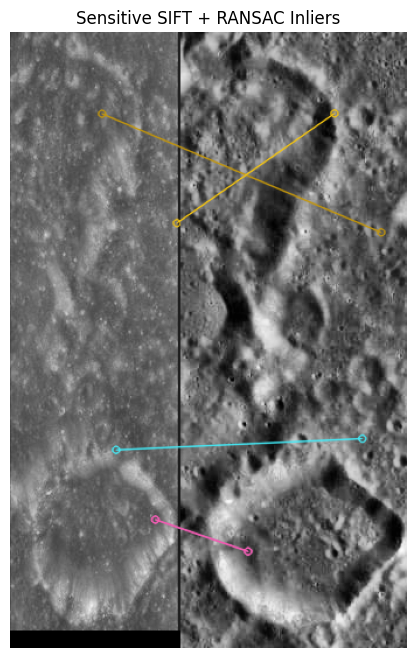

In [ ]:
import cv2
import matplotlib.pyplot as plt

inlier_matches_real = [
    m for m, keep in zip(good_real, mask_real)
    if keep
]

print("Candidate matches:", len(good_real))
print("RANSAC inliers:", len(inlier_matches_real))

inlier_img_real = cv2.drawMatches(
    source_clahe,
    kp_source_rs,
    reference_clahe,
    kp_reference_rs,
    inlier_matches_real,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 8))
plt.imshow(inlier_img_real, cmap="gray")
plt.title("Sensitive SIFT + RANSAC Inliers")
plt.axis("off")
plt.show()

In [ ]:
!pip install -q kornia

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 94.8 MB/s eta 0:00:00


In [ ]:
import torch
import kornia

from kornia.feature import LoFTR

print("Kornia version:", kornia.__version__)
print("PyTorch version:", torch.__version__)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

matcher = LoFTR(pretrained="outdoor").to(device)
matcher.eval()

print("LoFTR loaded successfully.")

Kornia version: 0.8.3
PyTorch version: 2.11.0+cpu
Device: cpu
Downloading: "http://cmp.felk.cvut.cz/~mishkdmy/models/loftr_outdoor.ckpt" to /root/.cache/torch/hub/checkpoints/loftr_outdoor.ckpt


100%|██████████| 44.2M/44.2M [00:03<00:00, 15.3MB/s]


LoFTR loaded successfully.


In [ ]:
import torch
import numpy as np
import cv2

# Use the CLAHE images we already created
img_source = source_clahe
img_reference = reference_clahe

# Convert uint8 [0,255] -> float32 [0,1]
img_source = img_source.astype(np.float32) / 255.0
img_reference = img_reference.astype(np.float32) / 255.0

# Convert to PyTorch tensors
source_tensor = torch.from_numpy(img_source)[None, None]
reference_tensor = torch.from_numpy(img_reference)[None, None]

# Move to CPU/GPU
source_tensor = source_tensor.to(device)
reference_tensor = reference_tensor.to(device)

print("Source tensor shape:", source_tensor.shape)
print("Reference tensor shape:", reference_tensor.shape)
print("Source range:", source_tensor.min().item(), source_tensor.max().item())
print("Reference range:", reference_tensor.min().item(), reference_tensor.max().item())

Source tensor shape: torch.Size([1, 1, 513, 146])
Reference tensor shape: torch.Size([1, 1, 528, 194])
Source range: 0.08627451211214066 0.9450980424880981
Reference range: 0.0 0.9882352948188782


In [ ]:
import time
import torch

# Prepare LoFTR input
input_data = {
    "image0": source_tensor,
    "image1": reference_tensor,
}

print("Running LoFTR...")
start = time.perf_counter()

with torch.no_grad():
    output = matcher(input_data)

elapsed = time.perf_counter() - start

# Extract matches
mkpts0 = output["keypoints0"].cpu().numpy()
mkpts1 = output["keypoints1"].cpu().numpy()

print("LoFTR completed.")
print("Number of matches:", len(mkpts0))
print("Runtime:", elapsed, "seconds")

Running LoFTR...
LoFTR completed.
Number of matches: 166
Runtime: 8.337619841999185 seconds


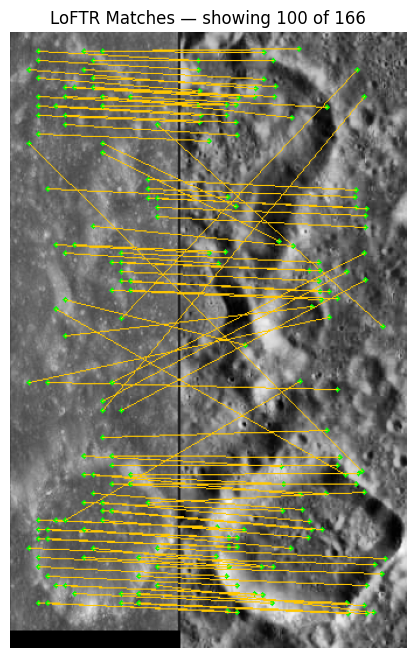

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Convert grayscale images to RGB for drawing
source_vis = cv2.cvtColor(source_clahe, cv2.COLOR_GRAY2BGR)
reference_vis = cv2.cvtColor(reference_clahe, cv2.COLOR_GRAY2BGR)

# Make a combined canvas
h0, w0 = source_vis.shape[:2]
h1, w1 = reference_vis.shape[:2]

canvas_height = max(h0, h1)
canvas_width = w0 + w1

canvas = np.zeros(
    (canvas_height, canvas_width, 3),
    dtype=np.uint8
)

canvas[:h0, :w0] = source_vis
canvas[:h1, w0:w0 + w1] = reference_vis

# Draw a subset of matches to keep visualization readable
num_to_draw = min(100, len(mkpts0))

# Use evenly spaced matches
indices = np.linspace(
    0,
    len(mkpts0) - 1,
    num_to_draw,
    dtype=int
)

for idx in indices:
    x0, y0 = mkpts0[idx]
    x1, y1 = mkpts1[idx]

    p0 = (int(round(x0)), int(round(y0)))
    p1 = (int(round(x1 + w0)), int(round(y1)))

    cv2.circle(canvas, p0, 2, (0, 255, 0), -1)
    cv2.circle(canvas, p1, 2, (0, 255, 0), -1)

    cv2.line(
        canvas,
        p0,
        p1,
        (0, 200, 255),
        1
    )

plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title(f"LoFTR Matches — showing {num_to_draw} of {len(mkpts0)}")
plt.axis("off")
plt.show()

In [ ]:
import cv2
import numpy as np

# Convert LoFTR matches to OpenCV point arrays
src_pts_loftr = np.float32(mkpts0).reshape(-1, 1, 2)
ref_pts_loftr = np.float32(mkpts1).reshape(-1, 1, 2)

print("LoFTR candidate matches:", len(src_pts_loftr))

# RANSAC + Homography
H_loftr, mask_loftr = cv2.findHomography(
    src_pts_loftr,
    ref_pts_loftr,
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=10000,
    confidence=0.995
)

if H_loftr is None or mask_loftr is None:
    print("Homography: FAILED")
    print("Inliers: 0")
    print("Inlier ratio: 0.0")

else:
    mask_loftr = mask_loftr.ravel()

    loftr_inliers = int(np.sum(mask_loftr))
    loftr_inlier_ratio = loftr_inliers / len(mask_loftr)

    print("Homography: FOUND")
    print("Candidate matches:", len(mask_loftr))
    print("Inliers:", loftr_inliers)
    print("Outliers:", len(mask_loftr) - loftr_inliers)
    print("Inlier ratio:", loftr_inlier_ratio)

LoFTR candidate matches: 166
Homography: FOUND
Candidate matches: 166
Inliers: 49
Outliers: 117
Inlier ratio: 0.29518072289156627


LoFTR inliers: 49


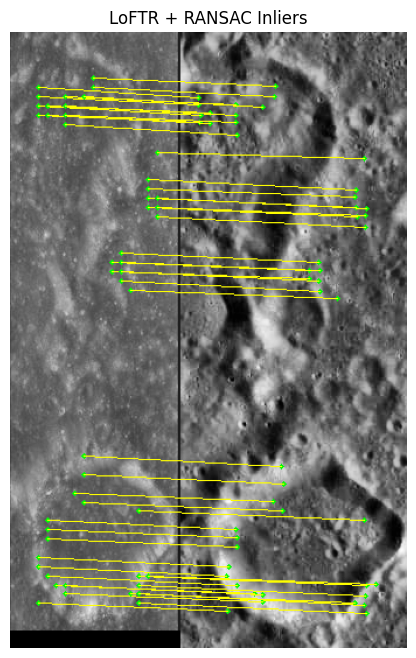

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Keep only RANSAC inliers
loftr_inlier_indices = np.where(mask_loftr == 1)[0]

print("LoFTR inliers:", len(loftr_inlier_indices))

# Create visualization canvas
source_vis = cv2.cvtColor(
    source_clahe,
    cv2.COLOR_GRAY2BGR
)

reference_vis = cv2.cvtColor(
    reference_clahe,
    cv2.COLOR_GRAY2BGR
)

h0, w0 = source_vis.shape[:2]
h1, w1 = reference_vis.shape[:2]

canvas_height = max(h0, h1)
canvas_width = w0 + w1

canvas = np.zeros(
    (canvas_height, canvas_width, 3),
    dtype=np.uint8
)

canvas[:h0, :w0] = source_vis
canvas[:h1, w0:w0 + w1] = reference_vis

# Draw ALL inliers
for idx in loftr_inlier_indices:

    x0, y0 = mkpts0[idx]
    x1, y1 = mkpts1[idx]

    p0 = (int(round(x0)), int(round(y0)))
    p1 = (int(round(x1 + w0)), int(round(y1)))

    cv2.circle(canvas, p0, 2, (0, 255, 0), -1)
    cv2.circle(canvas, p1, 2, (0, 255, 0), -1)

    cv2.line(
        canvas,
        p0,
        p1,
        (0, 255, 255),
        1
    )

plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title("LoFTR + RANSAC Inliers")
plt.axis("off")
plt.show()

In [ ]:
import numpy as np

# Source image dimensions
h, w = source_clahe.shape

rows, cols = 3, 3

loftr_grid = np.zeros((rows, cols), dtype=int)

# Go through only RANSAC inliers
for idx in loftr_inlier_indices:

    x, y = mkpts0[idx]

    col = min(int(x / (w / cols)), cols - 1)
    row = min(int(y / (h / rows)), rows - 1)

    loftr_grid[row, col] += 1

print("3 x 3 spatial distribution of LoFTR + RANSAC inliers:")
print(loftr_grid)

print("\nTotal inliers:", loftr_grid.sum())

3 x 3 spatial distribution of LoFTR + RANSAC inliers:
[[10  3  8]
 [ 0  6  1]
 [10  4  7]]

Total inliers: 49


In [ ]:
import numpy as np

grid = loftr_grid.astype(float)

mean_count = grid.mean()
std_count = grid.std()

cv = std_count / mean_count if mean_count > 0 else float("inf")

occupied_cells = np.count_nonzero(grid)
occupancy_ratio = occupied_cells / grid.size

print("Mean matches per cell:", mean_count)
print("Std deviation:", std_count)
print("Spatial CV:", cv)
print("Occupied cells:", occupied_cells, "/", grid.size)
print("Occupancy ratio:", occupancy_ratio)

Mean matches per cell: 5.444444444444445
Std deviation: 3.467663674294941
Spatial CV: 0.6369178177276422
Occupied cells: 8 / 9
Occupancy ratio: 0.8888888888888888


In [ ]:
sift_grid = np.array([
    [0, 0, 1],
    [1, 0, 1],
    [0, 0, 4]
], dtype=float)

sift_mean = sift_grid.mean()
sift_std = sift_grid.std()

sift_cv = sift_std / sift_mean if sift_mean > 0 else float("inf")
sift_occupied = np.count_nonzero(sift_grid)
sift_occupancy = sift_occupied / sift_grid.size

print("SIFT spatial CV:", sift_cv)
print("SIFT occupancy ratio:", sift_occupancy)

SIFT spatial CV: 1.5779087167410373
SIFT occupancy ratio: 0.4444444444444444


In [ ]:
import numpy as np

# Number of matches to keep from each grid cell
MAX_PER_CELL = 6

# Image dimensions
h, w = source_clahe.shape

rows, cols = 3, 3

# Store indices of RANSAC inliers by cell
cell_matches = {
    (r, c): []
    for r in range(rows)
    for c in range(cols)
}

# Put each LoFTR inlier into its spatial cell
for idx in loftr_inlier_indices:

    x, y = mkpts0[idx]

    col = min(int(x / (w / cols)), cols - 1)
    row = min(int(y / (h / rows)), rows - 1)

    cell_matches[(row, col)].append(idx)

# Select up to MAX_PER_CELL from each cell
selected_indices = []

for cell, indices in cell_matches.items():

    if not indices:
        continue

    # For now, keep the first MAX_PER_CELL.
    # Later we will rank by match confidence/error.
    selected_indices.extend(indices[:MAX_PER_CELL])

selected_indices = np.array(selected_indices, dtype=int)

print("Original LoFTR inliers:", len(loftr_inlier_indices))
print("Spatially selected matches:", len(selected_indices))

Original LoFTR inliers: 49
Spatially selected matches: 38


In [ ]:
import cv2
import numpy as np

# Selected LoFTR inlier points
selected_src = np.float32([
    mkpts0[idx]
    for idx in selected_indices
]).reshape(-1, 1, 2)

selected_ref = np.float32([
    mkpts1[idx]
    for idx in selected_indices
]).reshape(-1, 1, 2)

print("Selected matches:", len(selected_indices))

# Re-estimate homography using the spatially balanced set
H_selected, mask_selected = cv2.findHomography(
    selected_src,
    selected_ref,
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=10000,
    confidence=0.995
)

if H_selected is None or mask_selected is None:
    print("Homography: FAILED")
else:
    mask_selected = mask_selected.ravel()

    selected_inliers = int(np.sum(mask_selected))
    selected_ratio = selected_inliers / len(selected_indices)

    print("Homography: FOUND")
    print("Selected matches:", len(selected_indices))
    print("New inliers:", selected_inliers)
    print("New inlier ratio:", selected_ratio)

Selected matches: 38
Homography: FOUND
Selected matches: 38
New inliers: 36
New inlier ratio: 0.9473684210526315


In [ ]:
import numpy as np

h, w = source_clahe.shape

rows, cols = 3, 3

selected_grid = np.zeros((rows, cols), dtype=int)

for idx in selected_indices:

    x, y = mkpts0[idx]

    col = min(int(x / (w / cols)), cols - 1)
    row = min(int(y / (h / rows)), rows - 1)

    selected_grid[row, col] += 1

mean_selected = selected_grid.mean()
std_selected = selected_grid.std()

cv_selected = (
    std_selected / mean_selected
    if mean_selected > 0
    else float("inf")
)

occupied_selected = np.count_nonzero(selected_grid)
occupancy_selected = occupied_selected / selected_grid.size

print("Selected 3x3 distribution:")
print(selected_grid)

print("\nTotal selected:", selected_grid.sum())
print("Occupied cells:", occupied_selected, "/", selected_grid.size)
print("Occupancy ratio:", occupancy_selected)
print("Spatial CV:", cv_selected)

Selected 3x3 distribution:
[[6 3 6]
 [0 6 1]
 [6 4 6]]

Total selected: 38
Occupied cells: 8 / 9
Occupancy ratio: 0.8888888888888888
Spatial CV: 0.5328541245083313


In [ ]:
print(output.keys())

dict_keys(['keypoints0', 'keypoints1', 'confidence', 'batch_indexes'])


In [ ]:
confidence = output["confidence"].detach().cpu().numpy()

print("Number of confidence values:", len(confidence))
print("Minimum confidence:", confidence.min())
print("Maximum confidence:", confidence.max())
print("Mean confidence:", confidence.mean())

Number of confidence values: 166
Minimum confidence: 0.20214392
Maximum confidence: 0.9560843
Mean confidence: 0.42496556


In [ ]:
# Confidence values for all LoFTR matches
confidence = output["confidence"].detach().cpu().numpy()

# Keep confidence only for RANSAC inliers
inlier_confidence = confidence[loftr_inlier_indices]

print("LoFTR inlier confidence statistics")
print("-----------------------------------")
print("Number of inliers:", len(inlier_confidence))
print("Minimum:", inlier_confidence.min())
print("Maximum:", inlier_confidence.max())
print("Mean:", inlier_confidence.mean())
print("Median:", np.median(inlier_confidence))

LoFTR inlier confidence statistics
-----------------------------------
Number of inliers: 49
Minimum: 0.20776352
Maximum: 0.9560843
Mean: 0.48988825
Median: 0.46443355


In [ ]:
import numpy as np

# --------------------------------------------------
# Parameters
# --------------------------------------------------

ROWS = 3
COLS = 3
MAX_PER_CELL = 6

# --------------------------------------------------
# Source image dimensions
# --------------------------------------------------

h, w = source_clahe.shape

# --------------------------------------------------
# Confidence values for all LoFTR matches
# --------------------------------------------------

confidence = output["confidence"].detach().cpu().numpy()

# --------------------------------------------------
# Group ONLY RANSAC inliers by spatial cell
# --------------------------------------------------

cell_matches = {
    (r, c): []
    for r in range(ROWS)
    for c in range(COLS)
}

for idx in loftr_inlier_indices:

    x, y = mkpts0[idx]

    col = min(int(x / (w / COLS)), COLS - 1)
    row = min(int(y / (h / ROWS)), ROWS - 1)

    cell_matches[(row, col)].append(idx)

# --------------------------------------------------
# Select highest-confidence matches in each cell
# --------------------------------------------------

selected_confidence_indices = []

for (row, col), indices in cell_matches.items():

    if not indices:
        continue

    # Sort by confidence, highest first
    sorted_indices = sorted(
        indices,
        key=lambda idx: confidence[idx],
        reverse=True
    )

    # Keep strongest matches from this cell
    selected_confidence_indices.extend(
        sorted_indices[:MAX_PER_CELL]
    )

selected_confidence_indices = np.array(
    selected_confidence_indices,
    dtype=int
)

print("Original RANSAC inliers:", len(loftr_inlier_indices))
print(
    "Confidence-ranked spatial matches:",
    len(selected_confidence_indices)
)

# --------------------------------------------------
# Confidence statistics
# --------------------------------------------------

selected_conf = confidence[selected_confidence_indices]

print("\nSelected confidence statistics")
print("--------------------------------")
print("Minimum:", selected_conf.min())
print("Maximum:", selected_conf.max())
print("Mean:", selected_conf.mean())
print("Median:", np.median(selected_conf))

Original RANSAC inliers: 49
Confidence-ranked spatial matches: 38

Selected confidence statistics
--------------------------------
Minimum: 0.2114464
Maximum: 0.9560843
Mean: 0.54336894
Median: 0.542221


In [ ]:
import cv2
import numpy as np

# --------------------------------------------------
# Selected confidence-ranked points
# --------------------------------------------------

selected_src_conf = np.float32([
    mkpts0[idx]
    for idx in selected_confidence_indices
]).reshape(-1, 1, 2)

selected_ref_conf = np.float32([
    mkpts1[idx]
    for idx in selected_confidence_indices
]).reshape(-1, 1, 2)

print("Selected matches:", len(selected_confidence_indices))

# --------------------------------------------------
# Re-estimate homography
# --------------------------------------------------

H_conf, mask_conf = cv2.findHomography(
    selected_src_conf,
    selected_ref_conf,
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=10000,
    confidence=0.995
)

if H_conf is None or mask_conf is None:
    print("Homography: FAILED")
else:
    mask_conf = mask_conf.ravel()

    conf_inliers = int(np.sum(mask_conf))
    conf_inlier_ratio = conf_inliers / len(selected_confidence_indices)

    print("Homography: FOUND")
    print("Selected matches:", len(selected_confidence_indices))
    print("New inliers:", conf_inliers)
    print("New inlier ratio:", conf_inlier_ratio)

Selected matches: 38
Homography: FOUND
Selected matches: 38
New inliers: 36
New inlier ratio: 0.9473684210526315


Final geometrically valid matches: 36
Source points shape: (36, 2)
Reference points shape: (36, 2)

Final Homography:
[[ 1.33937575e+00  5.95146348e-02 -1.99469057e+01]
 [-1.56475366e-02  1.00123745e+00  7.78405732e+00]
 [-8.39268503e-05  8.07095644e-06  1.00000000e+00]]


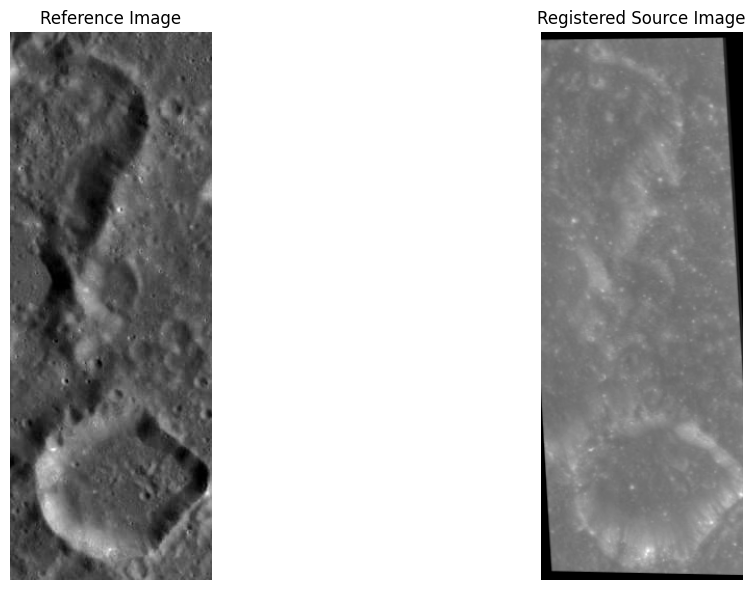

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Get the 36 geometrically consistent matches
# --------------------------------------------------

final_mask = mask_conf.ravel()

final_indices = np.array(
    selected_confidence_indices
)[final_mask == 1]

print("Final geometrically valid matches:", len(final_indices))

# --------------------------------------------------
# 2. Prepare points
# --------------------------------------------------

final_src = np.float32([
    mkpts0[idx]
    for idx in final_indices
])

final_ref = np.float32([
    mkpts1[idx]
    for idx in final_indices
])

print("Source points shape:", final_src.shape)
print("Reference points shape:", final_ref.shape)

# --------------------------------------------------
# 3. Estimate final transformation
# --------------------------------------------------

H_final, final_ransac_mask = cv2.findHomography(
    final_src.reshape(-1, 1, 2),
    final_ref.reshape(-1, 1, 2),
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=10000,
    confidence=0.995
)

if H_final is None:
    raise RuntimeError("Final homography estimation failed.")

print("\nFinal Homography:")
print(H_final)

# --------------------------------------------------
# 4. Warp source image
# --------------------------------------------------

ref_h, ref_w = reference_gray.shape

registered_final = cv2.warpPerspective(
    source_gray,
    H_final,
    (ref_w, ref_h)
)

# --------------------------------------------------
# 5. Display reference + registered source
# --------------------------------------------------

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(reference_gray, cmap="gray")
plt.title("Reference Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(registered_final, cmap="gray")
plt.title("Registered Source Image")
plt.axis("off")

plt.tight_layout()
plt.show()

Reference: (528, 194)
Registered: (528, 194)


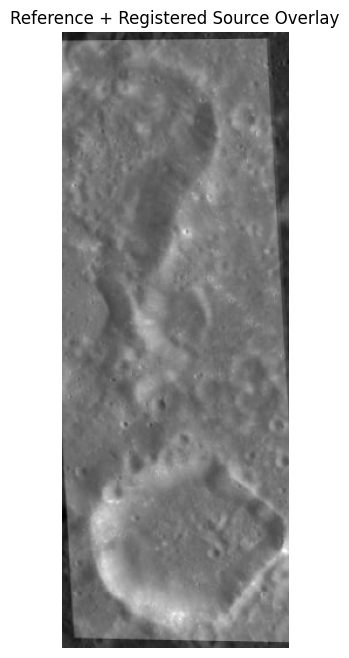

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Convert both to float for blending
ref_float = reference_gray.astype(np.float32)
reg_float = registered_final.astype(np.float32)

# Make sure both have same size
print("Reference:", ref_float.shape)
print("Registered:", reg_float.shape)

# Alpha blend
overlay = cv2.addWeighted(
    ref_float,
    0.5,
    reg_float,
    0.5,
    0
)

plt.figure(figsize=(8, 8))
plt.imshow(overlay, cmap="gray")
plt.title("Reference + Registered Source Overlay")
plt.axis("off")
plt.show()

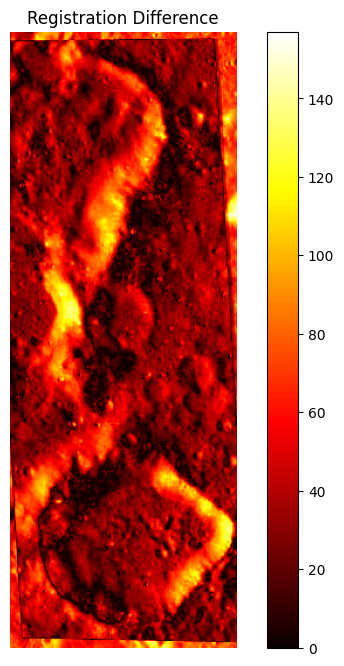

In [ ]:
diff = cv2.absdiff(
    reference_gray,
    registered_final
)

plt.figure(figsize=(8, 8))
plt.imshow(diff, cmap="hot")
plt.title("Registration Difference")
plt.axis("off")
plt.colorbar()
plt.show()

In [ ]:
import numpy as np
import cv2

# Our final 36 geometrically valid correspondences
src_final = np.float32([
    mkpts0[idx]
    for idx in final_indices
]).reshape(-1, 1, 2)

ref_final = np.float32([
    mkpts1[idx]
    for idx in final_indices
]).reshape(-1, 1, 2)

# Project source points using final homography
projected = cv2.perspectiveTransform(
    src_final,
    H_final
)

# Calculate point-wise reprojection errors
errors = np.linalg.norm(
    projected[:, 0, :] - ref_final[:, 0, :],
    axis=1
)

rmse = np.sqrt(np.mean(errors ** 2))
mean_error = np.mean(errors)
median_error = np.median(errors)

print("Final correspondence evaluation")
print("--------------------------------")
print("Number of points:", len(errors))
print("Mean reprojection error:", mean_error, "pixels")
print("Median reprojection error:", median_error, "pixels")
print("RMSE:", rmse, "pixels")
print("Maximum error:", np.max(errors), "pixels")

Final correspondence evaluation
--------------------------------
Number of points: 36
Mean reprojection error: 1.476116 pixels
Median reprojection error: 1.4943031 pixels
RMSE: 1.6503686 pixels
Maximum error: 2.8747916 pixels


In [ ]:
import cv2
import numpy as np

# ---------------------------------------------
# 1. Get the current 36 correspondence points
# ---------------------------------------------

src_points = np.float32([
    mkpts0[idx]
    for idx in final_indices
])

ref_points = np.float32([
    mkpts1[idx]
    for idx in final_indices
])

# ---------------------------------------------
# 2. cornerSubPix requires shape (N,1,2)
# ---------------------------------------------

src_corners = src_points.reshape(-1, 1, 2).copy()
ref_corners = ref_points.reshape(-1, 1, 2).copy()

# ---------------------------------------------
# 3. Convert images to float-compatible grayscale
# ---------------------------------------------

src_refine_img = source_gray.copy()
ref_refine_img = reference_gray.copy()

# ---------------------------------------------
# 4. Sub-pixel refinement settings
# ---------------------------------------------

criteria = (
    cv2.TERM_CRITERIA_EPS +
    cv2.TERM_CRITERIA_MAX_ITER,
    50,
    0.001
)

window = (5, 5)
zero_zone = (-1, -1)

# ---------------------------------------------
# 5. Refine points
# ---------------------------------------------

src_refined = cv2.cornerSubPix(
    src_refine_img,
    src_corners,
    window,
    zero_zone,
    criteria
)

ref_refined = cv2.cornerSubPix(
    ref_refine_img,
    ref_corners,
    window,
    zero_zone,
    criteria
)

src_refined = src_refined.reshape(-1, 2)
ref_refined = ref_refined.reshape(-1, 2)

# ---------------------------------------------
# 6. Re-estimate homography
# ---------------------------------------------

H_subpixel, mask_subpixel = cv2.findHomography(
    src_refined.reshape(-1, 1, 2),
    ref_refined.reshape(-1, 1, 2),
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=10000,
    confidence=0.995
)

if H_subpixel is None:
    raise RuntimeError("Sub-pixel homography estimation failed.")

# ---------------------------------------------
# 7. Calculate refined reprojection errors
# ---------------------------------------------

projected_subpixel = cv2.perspectiveTransform(
    src_refined.reshape(-1, 1, 2),
    H_subpixel
).reshape(-1, 2)

errors_subpixel = np.linalg.norm(
    projected_subpixel - ref_refined,
    axis=1
)

rmse_subpixel = np.sqrt(
    np.mean(errors_subpixel ** 2)
)

mean_subpixel = np.mean(errors_subpixel)
median_subpixel = np.median(errors_subpixel)

print("SUB-PIXEL REFINEMENT RESULT")
print("----------------------------")
print("Points:", len(src_refined))
print("Mean error:", mean_subpixel, "pixels")
print("Median error:", median_subpixel, "pixels")
print("RMSE:", rmse_subpixel, "pixels")
print("Maximum error:", np.max(errors_subpixel), "pixels")

SUB-PIXEL REFINEMENT RESULT
----------------------------
Points: 36
Mean error: 2.8455684 pixels
Median error: 2.0916395 pixels
RMSE: 3.7363405 pixels
Maximum error: 10.184805 pixels


In [ ]:
import cv2
import numpy as np

# Use CLAHE images to reduce illumination/contrast differences
template = reference_clahe.astype(np.float32) / 255.0
input_img = source_clahe.astype(np.float32) / 255.0

# ECC needs a 3x3 homography for MOTION_HOMOGRAPHY
warp_matrix = H_final.astype(np.float32).copy()

# Optimization criteria
criteria_ecc = (
    cv2.TERM_CRITERIA_EPS |
    cv2.TERM_CRITERIA_COUNT,
    200,
    1e-6
)

try:
    cc, warp_matrix_ecc = cv2.findTransformECC(
        template,
        input_img,
        warp_matrix,
        cv2.MOTION_HOMOGRAPHY,
        criteria_ecc,
        None,
        5
    )

    print("ECC refinement succeeded.")
    print("ECC correlation:", cc)

    print("\nRefined homography:")
    print(warp_matrix_ecc)

except cv2.error as e:
    print("ECC refinement failed:")
    print(e)

ECC refinement failed:
OpenCV(4.14.0) /io/opencv/modules/video/src/ecc.cpp:595: error: (-7:Iterations do not converge) The algorithm stopped before its convergence. The correlation is going to be minimized. Images may be uncorrelated or non-overlapped in function 'findTransformECCWithMask'



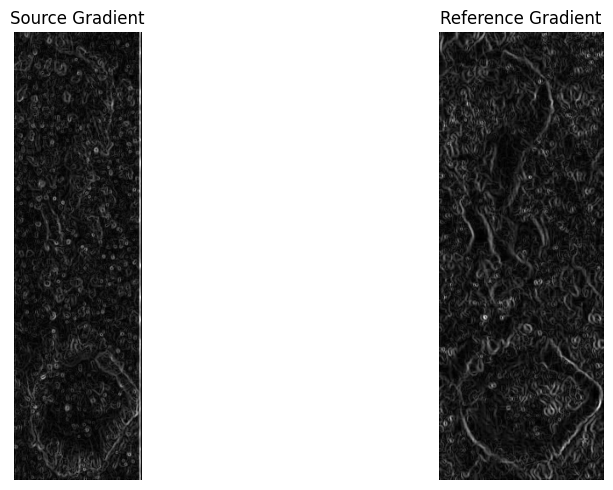

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Use CLAHE images
src = source_clahe
ref = reference_clahe

# Sobel gradients
src_gx = cv2.Sobel(src, cv2.CV_32F, 1, 0, ksize=3)
src_gy = cv2.Sobel(src, cv2.CV_32F, 0, 1, ksize=3)

ref_gx = cv2.Sobel(ref, cv2.CV_32F, 1, 0, ksize=3)
ref_gy = cv2.Sobel(ref, cv2.CV_32F, 0, 1, ksize=3)

# Gradient magnitude
src_grad = cv2.magnitude(src_gx, src_gy)
ref_grad = cv2.magnitude(ref_gx, ref_gy)

# Normalize for visualization
src_grad_vis = cv2.normalize(
    src_grad, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

ref_grad_vis = cv2.normalize(
    ref_grad, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(src_grad_vis, cmap="gray")
plt.title("Source Gradient")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(ref_grad_vis, cmap="gray")
plt.title("Reference Gradient")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np

# Use the first final correspondence
idx0 = final_indices[0]

x_src, y_src = mkpts0[idx0]
x_ref, y_ref = mkpts1[idx0]

print("Current source point:", (x_src, y_src))
print("Current reference point:", (x_ref, y_ref))

# Search radius in pixels
search_radius = 3

# Patch radius
patch_radius = 5

# Convert reference location to integer center
cx = int(round(x_ref))
cy = int(round(y_ref))

# Make sure the patch fits
if (
    cx - patch_radius < 0 or
    cy - patch_radius < 0 or
    cx + patch_radius >= ref_grad.shape[1] or
    cy + patch_radius >= ref_grad.shape[0]
):
    raise ValueError("Reference point too close to image boundary.")

# Source gradient patch
sx = int(round(x_src))
sy = int(round(y_src))

if (
    sx - patch_radius < 0 or
    sy - patch_radius < 0 or
    sx + patch_radius >= src_grad.shape[1] or
    sy + patch_radius >= src_grad.shape[0]
):
    raise ValueError("Source point too close to image boundary.")

source_patch = src_grad[
    sy - patch_radius : sy + patch_radius + 1,
    sx - patch_radius : sx + patch_radius + 1
]

best_score = -np.inf
best_position = None

# Search around the current reference location
for dy in np.arange(
    -search_radius,
    search_radius + 0.1,
    1.0
):
    for dx in np.arange(
        -search_radius,
        search_radius + 0.1,
        1.0
    ):

        tx = x_ref + dx
        ty = y_ref + dy

        txi = int(round(tx))
        tyi = int(round(ty))

        if (
            txi - patch_radius < 0
            or tyi - patch_radius < 0
            or txi + patch_radius >= ref_grad.shape[1]
            or tyi + patch_radius >= ref_grad.shape[0]
        ):
            continue

        ref_patch = ref_grad[
            tyi - patch_radius : tyi + patch_radius + 1,
            txi - patch_radius : txi + patch_radius + 1
        ]

        # Normalized correlation
        score = cv2.matchTemplate(
            ref_patch.astype(np.float32),
            source_patch.astype(np.float32),
            cv2.TM_CCOEFF_NORMED
        )[0, 0]

        if score > best_score:
            best_score = score
            best_position = (tx, ty)

print("Best integer-offset position:", best_position)
print("Best correlation score:", best_score)

Current source point: (np.float32(47.353848), np.float32(63.138462))
Current reference point: (np.float32(46.73992), np.float32(70.93113))
Best integer-offset position: (np.float64(45.73992156982422), np.float64(71.9311294555664))
Best correlation score: 0.33740607


In [ ]:
import cv2
import numpy as np

search_radius = 3
patch_radius = 5

refined_points = []
refinement_scores = []
refinement_shifts = []

for idx in final_indices:

    # Current LoFTR correspondence
    x_src, y_src = mkpts0[idx]
    x_ref, y_ref = mkpts1[idx]

    sx = int(round(float(x_src)))
    sy = int(round(float(y_src)))

    # Skip points too close to source boundary
    if (
        sx - patch_radius < 0 or
        sy - patch_radius < 0 or
        sx + patch_radius >= src_grad.shape[1] or
        sy + patch_radius >= src_grad.shape[0]
    ):
        continue

    source_patch = src_grad[
        sy - patch_radius : sy + patch_radius + 1,
        sx - patch_radius : sx + patch_radius + 1
    ]

    best_score = -np.inf
    best_position = (float(x_ref), float(y_ref))

    for dy in np.arange(
        -search_radius,
        search_radius + 0.1,
        1.0
    ):
        for dx in np.arange(
            -search_radius,
            search_radius + 0.1,
            1.0
        ):

            tx = float(x_ref) + dx
            ty = float(y_ref) + dy

            txi = int(round(tx))
            tyi = int(round(ty))

            if (
                txi - patch_radius < 0
                or tyi - patch_radius < 0
                or txi + patch_radius >= ref_grad.shape[1]
                or tyi + patch_radius >= ref_grad.shape[0]
            ):
                continue

            ref_patch = ref_grad[
                tyi - patch_radius : tyi + patch_radius + 1,
                txi - patch_radius : txi + patch_radius + 1
            ]

            score = cv2.matchTemplate(
                ref_patch.astype(np.float32),
                source_patch.astype(np.float32),
                cv2.TM_CCOEFF_NORMED
            )[0, 0]

            if score > best_score:
                best_score = score
                best_position = (tx, ty)

    refined_points.append(best_position)
    refinement_scores.append(best_score)
    refinement_shifts.append([
        best_position[0] - float(x_ref),
        best_position[1] - float(y_ref)
    ])

refined_points = np.array(refined_points, dtype=np.float32)
refinement_scores = np.array(refinement_scores, dtype=np.float32)
refinement_shifts = np.array(refinement_shifts, dtype=np.float32)

print("Refined points:", len(refined_points))
print("Mean correlation:", refinement_scores.mean())
print("Median correlation:", np.median(refinement_scores))
print("Best correlation:", refinement_scores.max())
print("Worst correlation:", refinement_scores.min())

print("\nMean absolute shift:")
print("dx:", np.mean(np.abs(refinement_shifts[:, 0])))
print("dy:", np.mean(np.abs(refinement_shifts[:, 1])))

print("\nStrong local matches (score >= 0.5):",
      np.sum(refinement_scores >= 0.5))

Refined points: 36
Mean correlation: 0.35370266
Median correlation: 0.36187664
Best correlation: 0.606108
Worst correlation: 0.004346039

Mean absolute shift:
dx: 1.8888888
dy: 1.9444444

Strong local matches (score >= 0.5): 3


In [ ]:
import cv2
import numpy as np

# --------------------------------------------------
# Final 36 correspondences
# --------------------------------------------------

src_pts = np.float32([
    mkpts0[idx]
    for idx in final_indices
])

ref_pts = np.float32([
    mkpts1[idx]
    for idx in final_indices
])

# --------------------------------------------------
# 1. AFFINE MODEL
# --------------------------------------------------

M_affine, mask_affine = cv2.estimateAffinePartial2D(
    src_pts.reshape(-1, 1, 2),
    ref_pts.reshape(-1, 1, 2),
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=10000,
    confidence=0.995
)

if M_affine is None:
    print("Affine estimation FAILED")
else:
    affine_projected = cv2.transform(
        src_pts.reshape(-1, 1, 2),
        M_affine
    ).reshape(-1, 2)

    affine_errors = np.linalg.norm(
        affine_projected - ref_pts,
        axis=1
    )

    affine_rmse = np.sqrt(
        np.mean(affine_errors ** 2)
    )

    affine_mean = np.mean(affine_errors)

    affine_inliers = int(np.sum(mask_affine))

    print("AFFINE")
    print("------")
    print("Inliers:", affine_inliers)
    print("Mean reprojection error:", affine_mean)
    print("RMSE:", affine_rmse)
    print("Matrix:")
    print(M_affine)


# --------------------------------------------------
# 2. HOMOGRAPHY MODEL
# --------------------------------------------------

H_homography, mask_homography = cv2.findHomography(
    src_pts.reshape(-1, 1, 2),
    ref_pts.reshape(-1, 1, 2),
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=10000,
    confidence=0.995
)

if H_homography is None:
    print("\nHomography estimation FAILED")
else:
    homography_projected = cv2.perspectiveTransform(
        src_pts.reshape(-1, 1, 2),
        H_homography
    ).reshape(-1, 2)

    homography_errors = np.linalg.norm(
        homography_projected - ref_pts,
        axis=1
    )

    homography_rmse = np.sqrt(
        np.mean(homography_errors ** 2)
    )

    homography_mean = np.mean(homography_errors)

    homography_inliers = int(
        np.sum(mask_homography)
    )

    print("\nHOMOGRAPHY")
    print("----------")
    print("Inliers:", homography_inliers)
    print("Mean reprojection error:", homography_mean)
    print("RMSE:", homography_rmse)
    print("Matrix:")
    print(H_homography)

AFFINE
------
Inliers: 13
Mean reprojection error: 11.429982
RMSE: 15.084893
Matrix:
[[ 1.01115728  0.08631578  5.11640653]
 [-0.08631578  1.01115728 12.98255098]]

HOMOGRAPHY
----------
Inliers: 36
Mean reprojection error: 1.476116
RMSE: 1.6503686
Matrix:
[[ 1.33937575e+00  5.95146348e-02 -1.99469057e+01]
 [-1.56475366e-02  1.00123745e+00  7.78405732e+00]
 [-8.39268503e-05  8.07095644e-06  1.00000000e+00]]


Warped source shape: (528, 194)


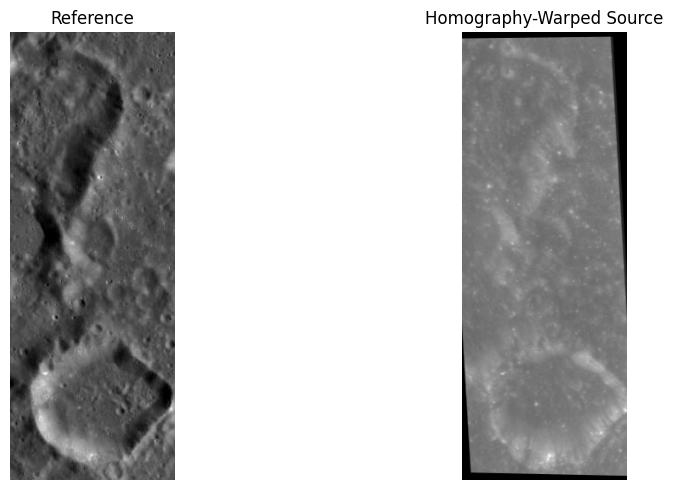

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Warp the ORIGINAL grayscale source image
# using our best homography
ref_h, ref_w = reference_gray.shape

warped_source = cv2.warpPerspective(
    source_gray,
    H_homography,
    (ref_w, ref_h)
)

print("Warped source shape:", warped_source.shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(reference_gray, cmap="gray")
plt.title("Reference")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(warped_source, cmap="gray")
plt.title("Homography-Warped Source")
plt.axis("off")

plt.tight_layout()
plt.show()

Reference point: (46.73992156982422, 70.9311294555664)
Estimated sub-pixel shift: (7.533698910924375, -1.7412469373671122)
Correlation response: 0.0977036627009511


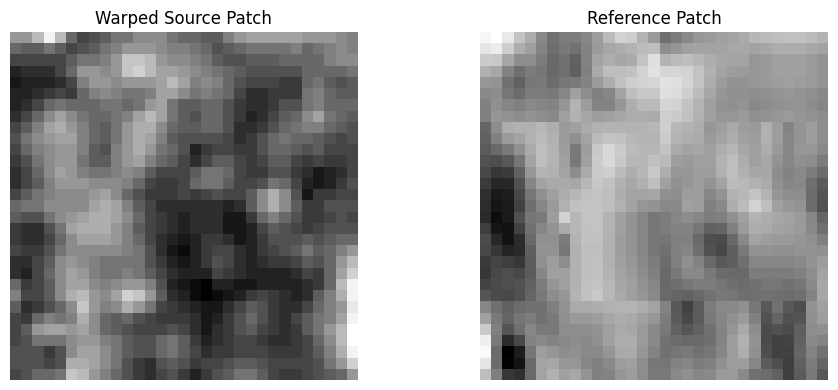

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------
# Choose one reliable final correspondence
# ---------------------------------------------

idx = final_indices[0]

x, y = map(float, mkpts1[idx])
print("Reference point:", (x, y))

# ---------------------------------------------
# Patch size
# ---------------------------------------------

patch_radius = 15

cx = int(round(x))
cy = int(round(y))

# Check boundaries
if (
    cx - patch_radius < 0
    or cy - patch_radius < 0
    or cx + patch_radius >= reference_gray.shape[1]
    or cy + patch_radius >= reference_gray.shape[0]
):
    raise ValueError("Selected point is too close to image boundary.")

# ---------------------------------------------
# Extract patches
# ---------------------------------------------

ref_patch = reference_gray[
    cy - patch_radius : cy + patch_radius + 1,
    cx - patch_radius : cx + patch_radius + 1
]

warped_patch = warped_source[
    cy - patch_radius : cy + patch_radius + 1,
    cx - patch_radius : cx + patch_radius + 1
]

# ---------------------------------------------
# Convert to float32
# ---------------------------------------------

ref_patch_f = ref_patch.astype(np.float32)
warped_patch_f = warped_patch.astype(np.float32)

# Remove mean intensity to reduce illumination effect
ref_patch_f -= ref_patch_f.mean()
warped_patch_f -= warped_patch_f.mean()

# ---------------------------------------------
# Phase correlation
# ---------------------------------------------

shift, response = cv2.phaseCorrelate(
    warped_patch_f,
    ref_patch_f
)

print("Estimated sub-pixel shift:", shift)
print("Correlation response:", response)

# ---------------------------------------------
# Visualize patches
# ---------------------------------------------

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(warped_patch, cmap="gray")
plt.title("Warped Source Patch")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(ref_patch, cmap="gray")
plt.title("Reference Patch")
plt.axis("off")

plt.tight_layout()
plt.show()

Source point: (47.35384750366211, 63.13846206665039)
Projected source point: (47.399574279785156, 70.50395202636719)
Reference point: (46.73992156982422, 70.9311294555664)
Residual error vector: [-0.65965271  0.42717743]
Residual distance: 0.7858894666402282

Phase correlation
-----------------
Estimated shift: (7.533698910924375, -1.7412469373671122)
Response: 0.0977036627009511


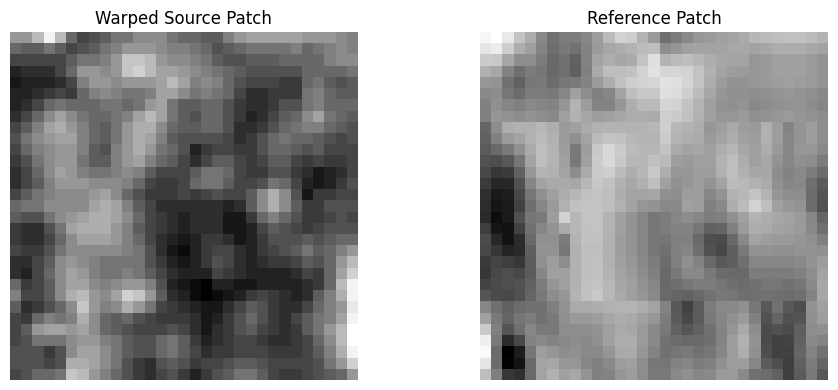

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------
# Select one final correspondence
# ---------------------------------------------

idx = final_indices[0]

# Original source point
src_point = np.float32([
    [mkpts0[idx]]
]).reshape(-1, 1, 2)

# Actual reference point
ref_point = np.float32([
    [mkpts1[idx]]
]).reshape(-1, 1, 2)

# ---------------------------------------------
# Project source point using final homography
# ---------------------------------------------

projected_point = cv2.perspectiveTransform(
    src_point,
    H_final
)[0, 0]

source_x, source_y = map(float, mkpts0[idx])
projected_x, projected_y = map(float, projected_point)
reference_x, reference_y = map(float, ref_point[0, 0])

print("Source point:", (source_x, source_y))
print("Projected source point:", (projected_x, projected_y))
print("Reference point:", (reference_x, reference_y))

# Residual between projection and reference
residual = np.array([
    reference_x - projected_x,
    reference_y - projected_y
])

print("Residual error vector:", residual)
print("Residual distance:", np.linalg.norm(residual))

# ---------------------------------------------
# Extract patches around projected/reference points
# ---------------------------------------------

patch_radius = 15

cx_source = int(round(projected_x))
cy_source = int(round(projected_y))

cx_ref = int(round(reference_x))
cy_ref = int(round(reference_y))

if (
    cx_source - patch_radius < 0 or
    cy_source - patch_radius < 0 or
    cx_source + patch_radius >= warped_source.shape[1] or
    cy_source + patch_radius >= warped_source.shape[0]
):
    raise ValueError("Projected source patch is near image boundary.")

if (
    cx_ref - patch_radius < 0 or
    cy_ref - patch_radius < 0 or
    cx_ref + patch_radius >= reference_gray.shape[1] or
    cy_ref + patch_radius >= reference_gray.shape[0]
):
    raise ValueError("Reference patch is near image boundary.")

warped_patch = warped_source[
    cy_source - patch_radius : cy_source + patch_radius + 1,
    cx_source - patch_radius : cx_source + patch_radius + 1
]

ref_patch = reference_gray[
    cy_ref - patch_radius : cy_ref + patch_radius + 1,
    cx_ref - patch_radius : cx_ref + patch_radius + 1
]

# Remove local mean to reduce brightness offset
warped_patch_f = warped_patch.astype(np.float32)
ref_patch_f = ref_patch.astype(np.float32)

warped_patch_f -= warped_patch_f.mean()
ref_patch_f -= ref_patch_f.mean()

# ---------------------------------------------
# Phase correlation
# ---------------------------------------------

shift, response = cv2.phaseCorrelate(
    warped_patch_f,
    ref_patch_f
)

print("\nPhase correlation")
print("-----------------")
print("Estimated shift:", shift)
print("Response:", response)

# ---------------------------------------------
# Visualize
# ---------------------------------------------

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(warped_patch, cmap="gray")
plt.title("Warped Source Patch")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(ref_patch, cmap="gray")
plt.title("Reference Patch")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.optimize import least_squares

# --------------------------------------------------
# Final 36 correspondences
# --------------------------------------------------

src = np.float64([
    mkpts0[idx]
    for idx in final_indices
])

dst = np.float64([
    mkpts1[idx]
    for idx in final_indices
])

# --------------------------------------------------
# Normalize current homography
# --------------------------------------------------

H0 = H_final / H_final[2, 2]

# Use the 8 independent parameters
p0 = np.array([
    H0[0, 0], H0[0, 1], H0[0, 2],
    H0[1, 0], H0[1, 1], H0[1, 2],
    H0[2, 0], H0[2, 1]
], dtype=np.float64)


# --------------------------------------------------
# Convert 8 parameters -> 3x3 homography
# --------------------------------------------------

def params_to_H(p):
    H = np.array([
        [p[0], p[1], p[2]],
        [p[3], p[4], p[5]],
        [p[6], p[7], 1.0]
    ], dtype=np.float64)

    return H


# --------------------------------------------------
# Project points
# --------------------------------------------------

def project_points(points, H):

    pts_h = np.hstack([
        points,
        np.ones((len(points), 1))
    ])

    projected = (H @ pts_h.T).T

    projected = projected[:, :2] / projected[:, 2:3]

    return projected


# --------------------------------------------------
# Residual function
# --------------------------------------------------

def residuals(p):

    H = params_to_H(p)

    projected = project_points(src, H)

    return (projected - dst).ravel()


# --------------------------------------------------
# Refine
# --------------------------------------------------

result = least_squares(
    residuals,
    p0,
    method="lm",
    max_nfev=5000
)

H_refined = params_to_H(result.x)

# --------------------------------------------------
# Evaluate before and after
# --------------------------------------------------

before_projected = project_points(src, H0)
after_projected = project_points(src, H_refined)

before_errors = np.linalg.norm(
    before_projected - dst,
    axis=1
)

after_errors = np.linalg.norm(
    after_projected - dst,
    axis=1
)

before_rmse = np.sqrt(np.mean(before_errors ** 2))
after_rmse = np.sqrt(np.mean(after_errors ** 2))

print("GEOMETRIC HOMOGRAPHY REFINEMENT")
print("--------------------------------")
print("Optimization success:", result.success)
print("Iterations:", result.nfev)

print("\nBefore refinement")
print("Mean error:", before_errors.mean())
print("RMSE:", before_rmse)
print("Max error:", before_errors.max())

print("\nAfter refinement")
print("Mean error:", after_errors.mean())
print("RMSE:", after_rmse)
print("Max error:", after_errors.max())

print("\nRefined homography:")
print(H_refined)

GEOMETRIC HOMOGRAPHY REFINEMENT
--------------------------------
Optimization success: True
Iterations: 4

Before refinement
Mean error: 1.4761175496130656
RMSE: 1.6503694989489954
Max error: 2.874794577769418

After refinement
Mean error: 1.4229636580960319
RMSE: 1.5735784958532049
Max error: 2.6811781672532025

Refined homography:
[[ 1.34451131e+00  5.81215344e-02 -1.97023978e+01]
 [-7.67656414e-03  9.94865019e-01  7.97949945e+00]
 [-5.18808298e-05 -6.28764994e-06  1.00000000e+00]]


In [ ]:
import numpy as np
from scipy.optimize import least_squares

# --------------------------------------------------
# Use the same final 36 correspondences
# --------------------------------------------------

src_all = np.float64([
    mkpts0[idx]
    for idx in final_indices
])

dst_all = np.float64([
    mkpts1[idx]
    for idx in final_indices
])

# --------------------------------------------------
# Fixed reproducible split
# --------------------------------------------------

rng = np.random.default_rng(42)

indices = np.arange(len(src_all))
rng.shuffle(indices)

split = int(0.75 * len(indices))

train_idx = indices[:split]
test_idx = indices[split:]

src_train = src_all[train_idx]
dst_train = dst_all[train_idx]

src_test = src_all[test_idx]
dst_test = dst_all[test_idx]

print("Training points:", len(train_idx))
print("Validation points:", len(test_idx))


# --------------------------------------------------
# Initial homography from training points
# --------------------------------------------------

H_train, mask_train = cv2.findHomography(
    src_train.reshape(-1, 1, 2),
    dst_train.reshape(-1, 1, 2),
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=10000,
    confidence=0.995
)

if H_train is None:
    raise RuntimeError("Training homography failed.")


# --------------------------------------------------
# Convert homography to optimization parameters
# --------------------------------------------------

H_train = H_train / H_train[2, 2]

p0 = np.array([
    H_train[0, 0], H_train[0, 1], H_train[0, 2],
    H_train[1, 0], H_train[1, 1], H_train[1, 2],
    H_train[2, 0], H_train[2, 1]
], dtype=np.float64)


def params_to_H(p):
    return np.array([
        [p[0], p[1], p[2]],
        [p[3], p[4], p[5]],
        [p[6], p[7], 1.0]
    ], dtype=np.float64)


def project_points(points, H):
    pts_h = np.hstack([
        points,
        np.ones((len(points), 1))
    ])

    projected = (H @ pts_h.T).T
    projected = projected[:, :2] / projected[:, 2:3]

    return projected


def residuals(p):
    H = params_to_H(p)
    projected = project_points(src_train, H)
    return (projected - dst_train).ravel()


# --------------------------------------------------
# Refine using ONLY training points
# --------------------------------------------------

result = least_squares(
    residuals,
    p0,
    method="lm",
    max_nfev=5000
)

H_holdout = params_to_H(result.x)


# --------------------------------------------------
# Evaluate on TRAINING points
# --------------------------------------------------

train_pred = project_points(src_train, H_holdout)

train_errors = np.linalg.norm(
    train_pred - dst_train,
    axis=1
)

train_rmse = np.sqrt(
    np.mean(train_errors ** 2)
)


# --------------------------------------------------
# Evaluate on NEVER-SEEN validation points
# --------------------------------------------------

test_pred = project_points(src_test, H_holdout)

test_errors = np.linalg.norm(
    test_pred - dst_test,
    axis=1
)

test_rmse = np.sqrt(
    np.mean(test_errors ** 2)
)


print("\nHOLD-OUT VALIDATION")
print("-------------------")
print("Training RMSE:", train_rmse)
print("Validation RMSE:", test_rmse)
print("Validation mean error:", test_errors.mean())
print("Validation max error:", test_errors.max())

Training points: 27
Validation points: 9

HOLD-OUT VALIDATION
-------------------
Training RMSE: 1.5389252821545283
Validation RMSE: 1.800636292212175
Validation mean error: 1.5891552252431174
Validation max error: 2.648214464174051


In [ ]:
import cv2
import numpy as np

# --------------------------------------------------
# Choose the first final correspondence
# --------------------------------------------------

idx = final_indices[0]

# Source point
source_point = np.float32([
    [mkpts0[idx]]
]).reshape(-1, 1, 2)

# Reference point
reference_point = np.float32([
    [mkpts1[idx]]
]).reshape(-1, 1, 2)

# --------------------------------------------------
# Project source point into reference coordinates
# using our current homography
# --------------------------------------------------

projected_point = cv2.perspectiveTransform(
    source_point,
    H_final
)

print("Reference point:")
print(reference_point[0, 0])

print("\nHomography-projected source point:")
print(projected_point[0, 0])

# --------------------------------------------------
# Convert images to float32
# --------------------------------------------------

src_img = source_clahe.astype(np.uint8)
ref_img = reference_clahe.astype(np.uint8)

# --------------------------------------------------
# Lucas-Kanade parameters
# --------------------------------------------------

lk_criteria = (
    cv2.TERM_CRITERIA_EPS |
    cv2.TERM_CRITERIA_COUNT,
    50,
    0.001
)

lk_win = (15, 15)

# Start at projected source position
start_point = projected_point.astype(np.float32)

# --------------------------------------------------
# Track the projected point in the reference image
# --------------------------------------------------

refined_point, status, error = cv2.calcOpticalFlowPyrLK(
    src_img,
    ref_img,
    start_point,
    None,
    winSize=lk_win,
    maxLevel=3,
    criteria=lk_criteria,
    flags=cv2.OPTFLOW_USE_INITIAL_FLOW
)

print("\nLucas-Kanade result:")
print("Status:", status.ravel())
print("Refined point:", refined_point[0, 0])
print("LK tracking error:", error.ravel())

Reference point:
[46.73992 70.93113]

Homography-projected source point:
[47.399574 70.50395 ]


error: OpenCV(4.14.0) /io/opencv/modules/video/src/lkpyramid.cpp:1218: error: (-215:Assertion failed) nextPtsMat.checkVector(2, CV_32F, true) == npoints in function 'calc'


In [ ]:
import cv2
import numpy as np

# --------------------------------------------------
# Choose one final correspondence
# --------------------------------------------------

idx = final_indices[0]

# Original source point
src_point = np.float32([
    mkpts0[idx]
]).reshape(-1, 1, 2)

# Actual reference point
ref_point = np.float32([
    mkpts1[idx]
]).reshape(-1, 1, 2)

# --------------------------------------------------
# Project source point using current homography
# --------------------------------------------------

projected_point = cv2.perspectiveTransform(
    src_point,
    H_final
)

print("Reference point:")
print(ref_point[0, 0])

print("\nHomography-projected source point:")
print(projected_point[0, 0])

# --------------------------------------------------
# Images
# --------------------------------------------------

src_img = source_clahe.astype(np.uint8)
ref_img = reference_clahe.astype(np.uint8)

# --------------------------------------------------
# LK parameters
# --------------------------------------------------

lk_criteria = (
    cv2.TERM_CRITERIA_EPS |
    cv2.TERM_CRITERIA_COUNT,
    50,
    0.001
)

lk_win = (15, 15)

# --------------------------------------------------
# For OPTFLOW_USE_INITIAL_FLOW:
# prevPts = source point
# nextPts = initial estimate in reference
# --------------------------------------------------

prev_pts = src_point.astype(np.float32)
next_pts = projected_point.astype(np.float32)

# --------------------------------------------------
# Track
# --------------------------------------------------

refined_point, status, error = cv2.calcOpticalFlowPyrLK(
    src_img,
    ref_img,
    prev_pts,
    next_pts,
    winSize=lk_win,
    maxLevel=3,
    criteria=lk_criteria,
    flags=cv2.OPTFLOW_USE_INITIAL_FLOW
)

print("\nLucas-Kanade result:")
print("Status:", status.ravel())
print("Refined point:", refined_point[0, 0])
print("LK tracking error:", error.ravel())

# --------------------------------------------------
# Compare to actual LoFTR reference point
# --------------------------------------------------

difference = (
    refined_point[0, 0] -
    ref_point[0, 0]
)

distance = np.linalg.norm(difference)

print("\nDifference from LoFTR reference point:", difference)
print("Distance from LoFTR reference point:", distance)

Reference point:
[46.73992 70.93113]

Homography-projected source point:
[47.399574 70.50395 ]


error: OpenCV(4.14.0) /io/opencv/modules/video/src/lkpyramid.cpp:1338: error: (-215:Assertion failed) prevPyr[level * lvlStep1].size() == nextPyr[level * lvlStep2].size() in function 'calc'


In [ ]:
import cv2
import numpy as np

# --------------------------------------------------
# Choose one final correspondence
# --------------------------------------------------

idx = final_indices[0]

# Original LoFTR correspondence
src_point = np.float32([
    mkpts0[idx]
]).reshape(-1, 1, 2)

ref_point = np.float32([
    mkpts1[idx]
]).reshape(-1, 1, 2)

# --------------------------------------------------
# Project source point into reference coordinates
# --------------------------------------------------

projected_point = cv2.perspectiveTransform(
    src_point,
    H_final
)

print("LoFTR reference point:")
print(ref_point[0, 0])

print("\nHomography-projected point:")
print(projected_point[0, 0])

# --------------------------------------------------
# IMPORTANT:
# Use warped_source because it has the SAME size
# as the reference image.
# --------------------------------------------------

prev_img = warped_source.astype(np.uint8)
next_img = reference_gray.astype(np.uint8)

print("\nImage sizes:")
print("Warped source:", prev_img.shape)
print("Reference:", next_img.shape)

# --------------------------------------------------
# LK parameters
# --------------------------------------------------

criteria = (
    cv2.TERM_CRITERIA_EPS |
    cv2.TERM_CRITERIA_COUNT,
    50,
    0.001
)

window = (15, 15)

# --------------------------------------------------
# Start at the homography prediction.
#
# Since we already know the approximate target
# point, use it as the initial estimate.
# --------------------------------------------------

prev_pts = projected_point.astype(np.float32)
next_pts = ref_point.astype(np.float32)

# --------------------------------------------------
# Lucas-Kanade
# --------------------------------------------------

refined_point, status, error = cv2.calcOpticalFlowPyrLK(
    prev_img,
    next_img,
    prev_pts,
    next_pts,
    winSize=window,
    maxLevel=3,
    criteria=criteria,
    flags=cv2.OPTFLOW_USE_INITIAL_FLOW
)

print("\nLucas-Kanade:")
print("Status:", status.ravel())
print("Refined point:", refined_point[0, 0])
print("Tracking error:", error.ravel())

# --------------------------------------------------
# Compare refined point with LoFTR correspondence
# --------------------------------------------------

difference = (
    refined_point[0, 0] -
    ref_point[0, 0]
)

distance = np.linalg.norm(difference)

print("\nDifference from LoFTR point:", difference)
print("Distance from LoFTR point:", distance)

LoFTR reference point:
[46.73992 70.93113]

Homography-projected point:
[47.399574 70.50395 ]

Image sizes:
Warped source: (528, 194)
Reference: (528, 194)

Lucas-Kanade:
Status: [0]
Refined point: [275.7747  150.50662]
Tracking error: [70.50395]

Difference from LoFTR point: [229.03476  79.57549]
Distance from LoFTR point: 242.4648


In [ ]:
import os

print(os.path.exists("/content/data"))
print(os.listdir("/content/data"))

False


FileNotFoundError: [Errno 2] No such file or directory: '/content/data'

In [ ]:
import os

os.makedirs("/content/data/source", exist_ok=True)
os.makedirs("/content/data/reference", exist_ok=True)

print("Folders created.")

Folders created.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving LRO NAC reference image.jpeg to LRO NAC reference image.jpeg


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Chandrayaan-2 source image.jpeg to Chandrayaan-2 source image.jpeg


In [ ]:
import shutil

shutil.move(
    "/content/Chandrayaan-2 source image.jpeg",
    "/content/data/source/source.jpeg"
)

shutil.move(
    "/content/LRO NAC reference image.jpeg",
    "/content/data/reference/reference.jpeg"
)

print("Images restored.")

Images restored.


In [ ]:
import cv2
import os

source_path = "/content/data/source/source.jpeg"
reference_path = "/content/data/reference/reference.jpeg"

source = cv2.imread(source_path)
reference = cv2.imread(reference_path)

print("Source exists:", os.path.exists(source_path))
print("Reference exists:", os.path.exists(reference_path))

print("Source loaded:", source is not None)
print("Reference loaded:", reference is not None)

if source is not None:
    print("Source shape:", source.shape)

if reference is not None:
    print("Reference shape:", reference.shape)

Source exists: True
Reference exists: True
Source loaded: True
Reference loaded: True
Source shape: (513, 146, 3)
Reference shape: (528, 194, 3)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil

# Permanent project folder
project_dir = "/content/drive/MyDrive/SIH26_Lunar_Registration"

os.makedirs(f"{project_dir}/data/source", exist_ok=True)
os.makedirs(f"{project_dir}/data/reference", exist_ok=True)

shutil.copy(
    "/content/data/source/source.jpeg",
    f"{project_dir}/data/source/source.jpeg"
)

shutil.copy(
    "/content/data/reference/reference.jpeg",
    f"{project_dir}/data/reference/reference.jpeg"
)

print("Images permanently saved to Google Drive.")

Images permanently saved to Google Drive.


In [ ]:
import cv2
import numpy as np

source_path = "/content/data/source/source.jpeg"
reference_path = "/content/data/reference/reference.jpeg"

source = cv2.imread(source_path)
reference = cv2.imread(reference_path)

source_gray = cv2.cvtColor(source, cv2.COLOR_BGR2GRAY)
reference_gray = cv2.cvtColor(reference, cv2.COLOR_BGR2GRAY)

# CLAHE
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

source_clahe = clahe.apply(source_gray)
reference_clahe = clahe.apply(reference_gray)

print("Source:", source_gray.shape)
print("Reference:", reference_gray.shape)
print("Basic pipeline restored.")

Source: (513, 146)
Reference: (528, 194)
Basic pipeline restored.


In [ ]:
!pip install -q kornia

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 85.7 MB/s eta 0:00:00


In [ ]:
import torch
import kornia
from kornia.feature import LoFTR

device = "cuda" if torch.cuda.is_available() else "cpu"

matcher = LoFTR(
    pretrained="outdoor"
).to(device)

matcher.eval()

print("Kornia:", kornia.__version__)
print("PyTorch:", torch.__version__)
print("Device:", device)
print("LoFTR loaded.")

Downloading: "http://cmp.felk.cvut.cz/~mishkdmy/models/loftr_outdoor.ckpt" to /root/.cache/torch/hub/checkpoints/loftr_outdoor.ckpt


100%|██████████| 44.2M/44.2M [00:02<00:00, 19.5MB/s]


Kornia: 0.8.3
PyTorch: 2.11.0+cpu
Device: cpu
LoFTR loaded.


In [ ]:
import numpy as np
import torch

source_tensor = torch.from_numpy(
    source_clahe.astype(np.float32) / 255.0
)[None, None].to(device)

reference_tensor = torch.from_numpy(
    reference_clahe.astype(np.float32) / 255.0
)[None, None].to(device)

print("Source tensor:", source_tensor.shape)
print("Reference tensor:", reference_tensor.shape)

Source tensor: torch.Size([1, 1, 513, 146])
Reference tensor: torch.Size([1, 1, 528, 194])


In [ ]:
import time

input_data = {
    "image0": source_tensor,
    "image1": reference_tensor
}

start = time.perf_counter()

with torch.no_grad():
    output = matcher(input_data)

elapsed = time.perf_counter() - start

mkpts0 = output["keypoints0"].cpu().numpy()
mkpts1 = output["keypoints1"].cpu().numpy()
confidence = output["confidence"].cpu().numpy()

print("LoFTR matches:", len(mkpts0))
print("Runtime:", elapsed, "seconds")
print("Confidence mean:", confidence.mean())

LoFTR matches: 166
Runtime: 4.626006797999935 seconds
Confidence mean: 0.42496556


In [ ]:
import cv2
import numpy as np

# Convert LoFTR correspondences to OpenCV format
src_pts_loftr = np.float32(mkpts0).reshape(-1, 1, 2)
ref_pts_loftr = np.float32(mkpts1).reshape(-1, 1, 2)

# Estimate homography with RANSAC
H_loftr, mask_loftr = cv2.findHomography(
    src_pts_loftr,
    ref_pts_loftr,
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=10000,
    confidence=0.995
)

if H_loftr is None or mask_loftr is None:
    raise RuntimeError("RANSAC homography estimation failed.")

mask_loftr = mask_loftr.ravel()

loftr_inlier_indices = np.where(mask_loftr == 1)[0]

loftr_inliers = len(loftr_inlier_indices)
loftr_inlier_ratio = loftr_inliers / len(mkpts0)

print("LoFTR + RANSAC")
print("----------------")
print("Candidate matches:", len(mkpts0))
print("Inliers:", loftr_inliers)
print("Outliers:", len(mkpts0) - loftr_inliers)
print("Inlier ratio:", loftr_inlier_ratio)

print("\nHomography:")
print(H_loftr)

NameError: name 'mkpts0' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print("My Drive contents:")
print(os.listdir("/content/drive/MyDrive"))

My Drive contents:
['IMG_20220814_121504_13.jpg', '17 parallel operations of Alternator 21-Oct-2021 20-38-30.pdf', '12 Single phase motor 21-Oct-2021 19-04-04.pdf', '4- Conductor , insulators & semi conductor 26-Oct-2021 11-40-39.pdf', '11Transformer 21-Oct-2021 20-33-09.pdf', '9 illumination 26-Oct-2021 11-47-15.pdf', '13three phase motor 21-Oct-2021 19-25-17.pdf', '7 house wiring 26-Oct-2021 11-44-56.pdf', '10 electric appliances 21-Oct-2021 19-33-55.pdf', '8 Under ground cable 21-Oct-2021 19-21-39.pdf', '3Fuse 21-Oct-2021 19-19-03.pdf', '2 Symbols 21-Oct-2021 19-13-05.pdf', '5 Types of wires & wiring accessories 21-Oct-2021 19-11-40.pdf', '6 wiring System 21-Oct-2021 19-08-55.pdf', '14 Synchronous motor 21-Oct-2021 19-05-08.pdf', 'Screenshot_20231110_093038.jpg', 'Screenshot_20231110_092949.jpg', 'IMG-20231112-WA0080.jpg', 'Screenshot_2023_1120_121803.jpg', 'hsc-science-2017-march-english.pdf', 'hsc-science-march-2018-board-question-paper-of-maths.pdf', 'hsc-science-march-2018-board

In [ ]:
import os

matches = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.lower() in [
            "source.jpeg",
            "reference.jpeg",
            "chandrayaan-2 source image.jpeg",
            "lro nac reference image.jpeg"
        ]:
            matches.append(os.path.join(root, file))

print("Found files:")
for path in matches:
    print(path)

Found files:
/content/drive/MyDrive/SIH26_Lunar_Registration/data/source/source.jpeg
/content/drive/MyDrive/SIH26_Lunar_Registration/data/reference/reference.jpeg


In [ ]:
!pip install -q kornia

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 70.7 MB/s eta 0:00:00


In [ ]:
import kornia
import torch

print("Kornia:", kornia.__version__)
print("PyTorch:", torch.__version__)

Kornia: 0.8.3
PyTorch: 2.11.0+cpu


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import cv2
import numpy as np
import torch
import kornia

from kornia.feature import LoFTR

source_path = "/content/drive/MyDrive/SIH26_Lunar_Registration/data/source/source.jpeg"
reference_path = "/content/drive/MyDrive/SIH26_Lunar_Registration/data/reference/reference.jpeg"

source = cv2.imread(source_path, cv2.IMREAD_GRAYSCALE)
reference = cv2.imread(reference_path, cv2.IMREAD_GRAYSCALE)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

source_clahe = clahe.apply(source)
reference_clahe = clahe.apply(reference)

device = "cuda" if torch.cuda.is_available() else "cpu"

matcher = LoFTR(pretrained="outdoor").to(device)
matcher.eval()

source_tensor = torch.from_numpy(
    source_clahe.astype(np.float32) / 255.0
)[None, None].to(device)

reference_tensor = torch.from_numpy(
    reference_clahe.astype(np.float32) / 255.0
)[None, None].to(device)

print("Source:", source.shape)
print("Reference:", reference.shape)
print("Device:", device)
print("LoFTR loaded.")
print("Setup complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Downloading: "http://cmp.felk.cvut.cz/~mishkdmy/models/loftr_outdoor.ckpt" to /root/.cache/torch/hub/checkpoints/loftr_outdoor.ckpt


100%|██████████| 44.2M/44.2M [00:00<00:00, 126MB/s]


Source: (513, 146)
Reference: (528, 194)
Device: cpu
LoFTR loaded.
Setup complete.


In [ ]:
import cv2
import numpy as np
import torch
import time

# ============================================================
# 1. LOFTR MATCHING
# ============================================================

input_data = {
    "image0": source_tensor,
    "image1": reference_tensor
}

start = time.perf_counter()

with torch.no_grad():
    output = matcher(input_data)

loftr_time = time.perf_counter() - start

mkpts0 = output["keypoints0"].detach().cpu().numpy()
mkpts1 = output["keypoints1"].detach().cpu().numpy()
confidence = output["confidence"].detach().cpu().numpy()

print("=== LOFTR ===")
print("Matches:", len(mkpts0))
print("Mean confidence:", confidence.mean())
print("Runtime:", loftr_time)


# ============================================================
# 2. RANSAC + HOMOGRAPHY
# ============================================================

src_pts = np.float32(mkpts0).reshape(-1, 1, 2)
ref_pts = np.float32(mkpts1).reshape(-1, 1, 2)

H, ransac_mask = cv2.findHomography(
    src_pts,
    ref_pts,
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=10000,
    confidence=0.995
)

if H is None or ransac_mask is None:
    raise RuntimeError("RANSAC failed.")

ransac_mask = ransac_mask.ravel()

inlier_indices = np.where(ransac_mask == 1)[0]

print("\n=== RANSAC ===")
print("Candidate matches:", len(mkpts0))
print("Inliers:", len(inlier_indices))
print("Outliers:", len(mkpts0) - len(inlier_indices))
print(
    "Inlier ratio:",
    len(inlier_indices) / len(mkpts0)
)


# ============================================================
# 3. SPATIAL + CONFIDENCE SELECTION
# ============================================================

ROWS = 3
COLS = 3
MAX_PER_CELL = 6

h, w = source_clahe.shape

cell_matches = {
    (r, c): []
    for r in range(ROWS)
    for c in range(COLS)
}

# Put RANSAC inliers into spatial cells
for idx in inlier_indices:

    x, y = mkpts0[idx]

    col = min(int(x / (w / COLS)), COLS - 1)
    row = min(int(y / (h / ROWS)), ROWS - 1)

    cell_matches[(row, col)].append(idx)

selected_indices = []

# Highest confidence first within each cell
for cell, indices in cell_matches.items():

    if not indices:
        continue

    sorted_indices = sorted(
        indices,
        key=lambda idx: confidence[idx],
        reverse=True
    )

    selected_indices.extend(
        sorted_indices[:MAX_PER_CELL]
    )

selected_indices = np.array(
    selected_indices,
    dtype=int
)

print("\n=== SPATIAL + CONFIDENCE SELECTION ===")
print("Original RANSAC inliers:", len(inlier_indices))
print("Selected matches:", len(selected_indices))


# ============================================================
# 4. SPATIAL DISTRIBUTION
# ============================================================

selected_grid = np.zeros((ROWS, COLS), dtype=int)

for idx in selected_indices:

    x, y = mkpts0[idx]

    col = min(int(x / (w / COLS)), COLS - 1)
    row = min(int(y / (h / ROWS)), ROWS - 1)

    selected_grid[row, col] += 1

mean_grid = selected_grid.mean()
std_grid = selected_grid.std()

spatial_cv = (
    std_grid / mean_grid
    if mean_grid > 0
    else float("inf")
)

occupied = np.count_nonzero(selected_grid)
occupancy_ratio = occupied / selected_grid.size

print("\nSpatial distribution:")
print(selected_grid)

print("Occupied cells:", occupied, "/", selected_grid.size)
print("Occupancy ratio:", occupancy_ratio)
print("Spatial CV:", spatial_cv)


# ============================================================
# 5. FINAL HOMOGRAPHY USING SELECTED MATCHES
# ============================================================

final_src = np.float32([
    mkpts0[idx]
    for idx in selected_indices
]).reshape(-1, 1, 2)

final_ref = np.float32([
    mkpts1[idx]
    for idx in selected_indices
]).reshape(-1, 1, 2)

H_final, final_mask = cv2.findHomography(
    final_src,
    final_ref,
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=10000,
    confidence=0.995
)

if H_final is None or final_mask is None:
    raise RuntimeError("Final homography failed.")

final_mask = final_mask.ravel()

final_inlier_indices = np.where(final_mask == 1)[0]

final_inliers = len(final_inlier_indices)
final_inlier_ratio = final_inliers / len(selected_indices)

print("\n=== FINAL HOMOGRAPHY ===")
print("Selected matches:", len(selected_indices))
print("Final inliers:", final_inliers)
print("Final inlier ratio:", final_inlier_ratio)


# ============================================================
# 6. FINAL REPROJECTION RMSE
# ============================================================

final_src_points = np.float32([
    mkpts0[selected_indices[i]]
    for i in final_inlier_indices
])

final_ref_points = np.float32([
    mkpts1[selected_indices[i]]
    for i in final_inlier_indices
])

projected = cv2.perspectiveTransform(
    final_src_points.reshape(-1, 1, 2),
    H_final
).reshape(-1, 2)

target = final_ref_points

errors = np.linalg.norm(
    projected - target,
    axis=1
)

rmse = np.sqrt(np.mean(errors ** 2))
mean_error = np.mean(errors)
median_error = np.median(errors)
max_error = np.max(errors)

print("\n=== FINAL ERROR ===")
print("Correspondences used:", len(errors))
print("Mean error:", mean_error)
print("Median error:", median_error)
print("RMSE:", rmse)
print("Maximum error:", max_error)


# ============================================================
# 7. WARP SOURCE IMAGE
# ============================================================

ref_h, ref_w = reference_gray.shape

registered = cv2.warpPerspective(
    source_gray,
    H_final,
    (ref_w, ref_h)
)

print("\nRegistered image:", registered.shape)
print("\nPIPELINE COMPLETE ✅")

=== LOFTR ===
Matches: 166
Mean confidence: 0.42496556
Runtime: 11.347533098999975

=== RANSAC ===
Candidate matches: 166
Inliers: 49
Outliers: 117
Inlier ratio: 0.29518072289156627

=== SPATIAL + CONFIDENCE SELECTION ===
Original RANSAC inliers: 49
Selected matches: 38

Spatial distribution:
[[6 3 6]
 [0 6 1]
 [6 4 6]]
Occupied cells: 8 / 9
Occupancy ratio: 0.8888888888888888
Spatial CV: 0.5328541245083313

=== FINAL HOMOGRAPHY ===
Selected matches: 38
Final inliers: 36
Final inlier ratio: 0.9473684210526315

=== FINAL ERROR ===
Correspondences used: 36
Mean error: 1.465214
Median error: 1.359636
RMSE: 1.6336833
Maximum error: 2.8081245


NameError: name 'reference_gray' is not defined

In [ ]:
import cv2

reference_gray = cv2.imread(
    "/content/drive/MyDrive/SIH26_Lunar_Registration/data/reference/reference.jpeg",
    cv2.IMREAD_GRAYSCALE
)

registered = cv2.warpPerspective(
    source,
    H_final,
    (reference_gray.shape[1], reference_gray.shape[0])
)

print("Registered image shape:", registered.shape)

Registered image shape: (528, 194)


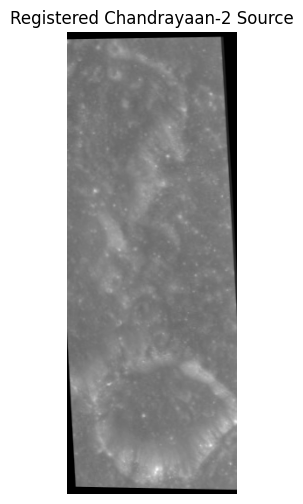

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(registered, cmap="gray")
plt.title("Registered Chandrayaan-2 Source")
plt.axis("off")
plt.show()

In [ ]:
import cv2
import numpy as np
import torch
import time

# Run LoFTR
input_data = {
    "image0": source_tensor,
    "image1": reference_tensor
}

start = time.perf_counter()

with torch.no_grad():
    output = matcher(input_data)

print("LoFTR runtime:",
      time.perf_counter() - start)

# Extract matches
mkpts0 = output["keypoints0"].detach().cpu().numpy()
mkpts1 = output["keypoints1"].detach().cpu().numpy()
confidence = output["confidence"].detach().cpu().numpy()

print("LoFTR matches:", len(mkpts0))

# RANSAC
src_pts = np.float32(mkpts0).reshape(-1, 1, 2)
ref_pts = np.float32(mkpts1).reshape(-1, 1, 2)

H_loftr, mask_loftr = cv2.findHomography(
    src_pts,
    ref_pts,
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=10000,
    confidence=0.995
)

if H_loftr is None or mask_loftr is None:
    raise RuntimeError("RANSAC failed.")

mask_loftr = mask_loftr.ravel()

print("RANSAC inliers:",
      int(np.sum(mask_loftr)))

LoFTR runtime: 12.097563188000095
LoFTR matches: 166
RANSAC inliers: 49


In [ ]:
import cv2
import numpy as np

# ============================================================
# 1. Get RANSAC inlier points
# ============================================================

inlier_ids = np.where(mask_loftr == 1)[0]

inlier_src = np.float32([
    mkpts0[i] for i in inlier_ids
]).reshape(-1, 1, 2)

inlier_ref = np.float32([
    mkpts1[i] for i in inlier_ids
]).reshape(-1, 1, 2)

# ============================================================
# 2. Calculate reprojection error for each RANSAC inlier
# ============================================================

projected = cv2.perspectiveTransform(
    inlier_src,
    H_loftr
).reshape(-1, 2)

actual = inlier_ref.reshape(-1, 2)

reprojection_errors = np.linalg.norm(
    projected - actual,
    axis=1
)

# ============================================================
# 3. Match quality score
# ============================================================

inlier_conf = confidence[inlier_ids]

quality_score = (
    inlier_conf /
    (1.0 + reprojection_errors)
)

# ============================================================
# 4. Put inliers into 3x3 spatial grid
# ============================================================

ROWS = 3
COLS = 3
MAX_PER_CELL = 6

h, w = source_clahe.shape

cell_matches = {
    (r, c): []
    for r in range(ROWS)
    for c in range(COLS)
}

for local_i, original_idx in enumerate(inlier_ids):

    x, y = mkpts0[original_idx]

    col = min(
        int(x / (w / COLS)),
        COLS - 1
    )

    row = min(
        int(y / (h / ROWS)),
        ROWS - 1
    )

    cell_matches[(row, col)].append(
        local_i
    )

# ============================================================
# 5. Select highest-quality points per cell
# ============================================================

selected_local = []

for cell, local_indices in cell_matches.items():

    if not local_indices:
        continue

    ranked = sorted(
        local_indices,
        key=lambda i: quality_score[i],
        reverse=True
    )

    selected_local.extend(
        ranked[:MAX_PER_CELL]
    )

selected_local = np.array(
    selected_local,
    dtype=int
)

selected_original_ids = inlier_ids[
    selected_local
]

# ============================================================
# 6. Print statistics
# ============================================================

print("QUALITY-AWARE SPATIAL SELECTION")
print("--------------------------------")
print("Original RANSAC inliers:",
      len(inlier_ids))

print("Selected matches:",
      len(selected_original_ids))

print("\nSelected confidence:")
print(
    "Mean:",
    confidence[selected_original_ids].mean()
)

print(
    "Median:",
    np.median(confidence[selected_original_ids])
)

print("\nSelected reprojection error:")
print(
    "Mean:",
    reprojection_errors[selected_local].mean()
)

print(
    "Median:",
    np.median(reprojection_errors[selected_local])
)

print("\nQuality score:")
print(
    "Mean:",
    quality_score[selected_local].mean()
)

QUALITY-AWARE SPATIAL SELECTION
--------------------------------
Original RANSAC inliers: 49
Selected matches: 38

Selected confidence:
Mean: 0.53564703
Median: 0.53688514

Selected reprojection error:
Mean: 1.3486365
Median: 1.3103894

Quality score:
Mean: 0.25051403


In [ ]:
# ============================================================
# Re-estimate homography using quality-aware selected points
# ============================================================

quality_src = np.float32([
    mkpts0[i]
    for i in selected_original_ids
]).reshape(-1, 1, 2)

quality_ref = np.float32([
    mkpts1[i]
    for i in selected_original_ids
]).reshape(-1, 1, 2)

H_quality, mask_quality = cv2.findHomography(
    quality_src,
    quality_ref,
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=10000,
    confidence=0.995
)

if H_quality is None or mask_quality is None:
    raise RuntimeError(
        "Quality-aware homography failed."
    )

mask_quality = mask_quality.ravel()

quality_inliers = int(
    np.sum(mask_quality)
)

quality_ratio = (
    quality_inliers /
    len(selected_original_ids)
)

print("QUALITY-AWARE HOMOGRAPHY")
print("-------------------------")
print(
    "Selected matches:",
    len(selected_original_ids)
)

print(
    "Final inliers:",
    quality_inliers
)

print(
    "Final inlier ratio:",
    quality_ratio
)

QUALITY-AWARE HOMOGRAPHY
-------------------------
Selected matches: 38
Final inliers: 36
Final inlier ratio: 0.9473684210526315


In [ ]:
import numpy as np
import cv2

# --------------------------------------------------
# 1. Spatial distribution
# --------------------------------------------------

ROWS = 3
COLS = 3

h, w = source_clahe.shape

quality_grid = np.zeros((ROWS, COLS), dtype=int)

for idx in selected_original_ids:

    x, y = mkpts0[idx]

    col = min(
        int(x / (w / COLS)),
        COLS - 1
    )

    row = min(
        int(y / (h / ROWS)),
        ROWS - 1
    )

    quality_grid[row, col] += 1

mean_grid = quality_grid.mean()
std_grid = quality_grid.std()

quality_cv = (
    std_grid / mean_grid
    if mean_grid > 0
    else float("inf")
)

occupied = np.count_nonzero(quality_grid)
occupancy_ratio = occupied / quality_grid.size

print("QUALITY-AWARE SPATIAL DISTRIBUTION")
print("----------------------------------")
print(quality_grid)
print("Occupied cells:", occupied, "/", quality_grid.size)
print("Occupancy ratio:", occupancy_ratio)
print("Spatial CV:", quality_cv)


# --------------------------------------------------
# 2. Final reprojection error
# --------------------------------------------------

quality_mask = mask_quality.ravel()

quality_final_ids = selected_original_ids[
    quality_mask == 1
]

quality_src_final = np.float32([
    mkpts0[idx]
    for idx in quality_final_ids
]).reshape(-1, 1, 2)

quality_ref_final = np.float32([
    mkpts1[idx]
    for idx in quality_final_ids
]).reshape(-1, 1, 2)

quality_projected = cv2.perspectiveTransform(
    quality_src_final,
    H_quality
)

quality_errors = np.linalg.norm(
    quality_projected.reshape(-1, 2)
    -
    quality_ref_final.reshape(-1, 2),
    axis=1
)

quality_rmse = np.sqrt(
    np.mean(quality_errors ** 2)
)

print("\nQUALITY-AWARE FINAL ERROR")
print("-------------------------")
print("Final correspondences:", len(quality_errors))
print("Mean error:", quality_errors.mean())
print("Median error:", np.median(quality_errors))
print("RMSE:", quality_rmse)
print("Maximum error:", quality_errors.max())

QUALITY-AWARE SPATIAL DISTRIBUTION
----------------------------------
[[6 3 6]
 [0 6 1]
 [6 4 6]]
Occupied cells: 8 / 9
Occupancy ratio: 0.8888888888888888
Spatial CV: 0.5328541245083313

QUALITY-AWARE FINAL ERROR
-------------------------
Final correspondences: 36
Mean error: 1.3755193
Median error: 1.1826952
RMSE: 1.5388751
Maximum error: 2.8410826


In [ ]:
import os

base = "/content/drive/MyDrive/SIH26_Lunar_Registration"

for i in range(1, 6):
    os.makedirs(
        f"{base}/data/pair{i:02d}",
        exist_ok=True
    )

os.makedirs(
    f"{base}/results",
    exist_ok=True
)

print("Pair folders created.")

Pair folders created.


In [ ]:
import os

base = "/content/drive/MyDrive/SIH26_Lunar_Registration/data"

for folder in sorted(os.listdir(base)):
    path = os.path.join(base, folder)

    if os.path.isdir(path):
        print(folder, "→", os.listdir(path))

pair01 → []
pair02 → []
pair03 → []
pair04 → []
pair05 → []
reference → ['reference.jpeg']
source → ['source.jpeg']


In [ ]:
import numpy as np

def evaluate_registration(
    projected_points,
    reference_points,
    grid=None
):
    """
    Evaluate geometric registration quality.

    Parameters
    ----------
    projected_points : ndarray, shape (N, 2)
        Source points projected into reference coordinates.

    reference_points : ndarray, shape (N, 2)
        Ground/reference correspondence locations.

    grid : ndarray, optional
        Spatial match-count grid.

    Returns
    -------
    dict
        Registration metrics.
    """

    projected_points = np.asarray(
        projected_points,
        dtype=np.float64
    )

    reference_points = np.asarray(
        reference_points,
        dtype=np.float64
    )

    if (
        projected_points.shape !=
        reference_points.shape
    ):
        raise ValueError(
            "Projected and reference points "
            "must have the same shape."
        )

    if len(projected_points) == 0:
        raise ValueError(
            "At least one correspondence is required."
        )

    errors = np.linalg.norm(
        projected_points - reference_points,
        axis=1
    )

    metrics = {
        "num_points": len(errors),
        "mean_error": float(np.mean(errors)),
        "median_error": float(np.median(errors)),
        "rmse": float(
            np.sqrt(np.mean(errors ** 2))
        ),
        "max_error": float(np.max(errors))
    }

    if grid is not None:

        grid = np.asarray(
            grid,
            dtype=np.float64
        )

        mean_grid = grid.mean()
        std_grid = grid.std()

        metrics["occupied_cells"] = int(
            np.count_nonzero(grid)
        )

        metrics["total_cells"] = int(
            grid.size
        )

        metrics["occupancy_ratio"] = float(
            np.count_nonzero(grid) / grid.size
        )

        metrics["spatial_cv"] = float(
            std_grid / mean_grid
        ) if mean_grid > 0 else float("inf")

    return metrics

In [ ]:
metrics = evaluate_registration(
    projected,
    target,
    selected_grid
)

for key, value in metrics.items():
    print(f"{key}: {value}")

NameError: name 'projected' is not defined

In [ ]:
import cv2
import numpy as np

# ============================================================
# Recreate RANSAC inlier information
# ============================================================

inlier_ids = np.where(mask_loftr == 1)[0]

inlier_src = np.float32([
    mkpts0[i] for i in inlier_ids
]).reshape(-1, 1, 2)

inlier_ref = np.float32([
    mkpts1[i] for i in inlier_ids
]).reshape(-1, 1, 2)

# Project RANSAC inliers
projected_inliers = cv2.perspectiveTransform(
    inlier_src,
    H_loftr
).reshape(-1, 2)

actual_inliers = inlier_ref.reshape(-1, 2)

# Reprojection error
reprojection_errors = np.linalg.norm(
    projected_inliers - actual_inliers,
    axis=1
)

# LoFTR confidence
inlier_confidence = confidence[inlier_ids]

# Quality score
quality_score = (
    inlier_confidence /
    (1.0 + reprojection_errors)
)

# ============================================================
# Spatial + quality selection
# ============================================================

ROWS = 3
COLS = 3
MAX_PER_CELL = 6

h, w = source_clahe.shape

cell_matches = {
    (r, c): []
    for r in range(ROWS)
    for c in range(COLS)
}

for local_i, original_idx in enumerate(inlier_ids):

    x, y = mkpts0[original_idx]

    col = min(
        int(x / (w / COLS)),
        COLS - 1
    )

    row = min(
        int(y / (h / ROWS)),
        ROWS - 1
    )

    cell_matches[(row, col)].append(local_i)

selected_local = []

for cell, local_indices in cell_matches.items():

    if not local_indices:
        continue

    ranked = sorted(
        local_indices,
        key=lambda i: quality_score[i],
        reverse=True
    )

    selected_local.extend(
        ranked[:MAX_PER_CELL]
    )

selected_local = np.array(
    selected_local,
    dtype=int
)

# Map back to original LoFTR indices
selected_original_ids = inlier_ids[selected_local]

print("RANSAC inliers:", len(inlier_ids))
print("Selected matches:", len(selected_original_ids))
print("Selected IDs recreated successfully.")

NameError: name 'mask_loftr' is not defined

In [ ]:
import time
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import streamlit as st
from kornia.feature import LoFTR

# ============================================================
# 1. CORE REGISTRATION ENGINE (Logic Strictly Preserved)
# ============================================================

_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
_MATCHER = LoFTR(pretrained="outdoor").to(_DEVICE)
_MATCHER.eval()

def preprocess_image(image):
    if image is None: raise ValueError("Input image is None.")
    if len(image.shape) == 3: gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else: gray = image.copy()
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return gray, clahe.apply(gray)

def calculate_spatial_grid(points, image_shape, rows=3, cols=3):
    h, w = image_shape
    grid = np.zeros((rows, cols), dtype=int)
    for x, y in points:
        col = min(int(x / (w / cols)), cols - 1)
        row = min(int(y / (h / rows)), rows - 1)
        grid[row, col] += 1
    return grid

def register_images(source_image, reference_image, max_per_cell=6, ransac_threshold=3.0):
    start_time = time.perf_counter()
    source_gray, source_clahe = preprocess_image(source_image)
    reference_gray, reference_clahe = preprocess_image(reference_image)

    s_tensor = torch.from_numpy(source_clahe.astype(np.float32) / 255.0)[None, None].to(_DEVICE)
    r_tensor = torch.from_numpy(reference_clahe.astype(np.float32) / 255.0)[None, None].to(_DEVICE)

    with torch.no_grad():
        output = _MATCHER({"image0": s_tensor, "image1": r_tensor})

    mkpts0, mkpts1, confidence = output["keypoints0"].cpu().numpy(), output["keypoints1"].cpu().numpy(), output["confidence"].cpu().numpy()

    H_init, mask_i = cv2.findHomography(mkpts0, mkpts1, cv2.RANSAC, ransac_threshold)
    inlier_ids = np.where(mask_i.ravel() == 1)[0]

    projected = cv2.perspectiveTransform(mkpts0[inlier_ids].reshape(-1,1,2), H_init).reshape(-1,2)
    errors = np.linalg.norm(projected - mkpts1[inlier_ids], axis=1)
    quality = confidence[inlier_ids] / (1.0 + errors)

    h, w = source_clahe.shape
    cells = {(r, c): [] for r in range(3) for c in range(3)}
    for i, idx in enumerate(inlier_ids):
        col = min(int(mkpts0[idx][0] / (w / 3)), 2)
        row = min(int(mkpts0[idx][1] / (h / 3)), 2)
        cells[(row, col)].append(i)

    selected_local = []
    for cell, indices in cells.items():
        selected_local.extend(sorted(indices, key=lambda i: quality[i], reverse=True)[:max_per_cell])

    selected_ids = inlier_ids[selected_local]
    H_final, mask_f = cv2.findHomography(mkpts0[selected_ids], mkpts1[selected_ids], cv2.RANSAC, ransac_threshold)
    final_inlier_ids = selected_ids[mask_f.ravel() == 1]

    f_src, f_ref = mkpts0[final_inlier_ids], mkpts1[final_inlier_ids]
    f_proj = cv2.perspectiveTransform(f_src.reshape(-1,1,2), H_final).reshape(-1,2)
    f_err = np.linalg.norm(f_proj - f_ref, axis=1)

    reg_img = cv2.warpPerspective(source_gray, H_final, (reference_gray.shape[1], reference_gray.shape[0]))

    source_v, ref_v = cv2.cvtColor(source_clahe, cv2.COLOR_GRAY2BGR), cv2.cvtColor(reference_clahe, cv2.COLOR_GRAY2BGR)
    canvas = np.zeros((max(source_v.shape[0], ref_v.shape[0]), source_v.shape[1]+ref_v.shape[1], 3), dtype=np.uint8)
    canvas[:source_v.shape[0], :source_v.shape[1]] = source_v
    canvas[:ref_v.shape[0], source_v.shape[1]:] = ref_v
    for i in final_inlier_ids:
        cv2.line(canvas, (int(mkpts0[i][0]), int(mkpts0[i][1])), (int(mkpts1[i][0]+source_v.shape[1]), int(mkpts1[i][1])), (0,255,255), 1)

    return {
        "registered_image": reg_img, "match_visualization": canvas,
        "spatial_grid": calculate_spatial_grid(f_src, source_clahe.shape),
        "candidate_matches": len(mkpts0), "initial_inliers": len(inlier_ids),
        "selected_matches": len(selected_ids), "final_inliers": len(final_inlier_ids),
        "final_inlier_ratio": len(final_inlier_ids)/len(selected_ids), "rmse": np.sqrt(np.mean(f_err**2)),
        "mean_error": np.mean(f_err), "median_error": np.median(f_err), "max_error": np.max(f_err),
        "occupancy_ratio": np.count_nonzero(calculate_spatial_grid(f_src, source_clahe.shape))/9,
        "spatial_cv": np.std(calculate_spatial_grid(f_src, source_clahe.shape))/np.mean(calculate_spatial_grid(f_src, source_clahe.shape)),
        "runtime": time.perf_counter() - start_time, "device": _DEVICE, "occupied_cells": np.count_nonzero(calculate_spatial_grid(f_src, source_clahe.shape)), "total_cells": 9
    }

# ============================================================
# 2. REDESIGNED MISSION CONTROL INTERFACE
# ============================================================

st.set_page_config(page_title="Lunar Registration Console", layout="wide", page_icon="🌙")

st.markdown("""
<style>
    .main { background-color: #0e1117; color: #e0e6ed; }
    .stMetric { background-color: #1c2128; border: 1px solid #30363d; padding: 15px; border-radius: 5px; }
    .stButton>button { background-color: #008bcf; color: white; border: none; font-weight: bold; width: 100%; height: 3em; border-radius: 4px; }
    .stHeader { border-bottom: 2px solid #008bcf; margin-bottom: 20px; padding-bottom: 10px; }
    .pipeline-container { display: flex; justify-content: space-between; margin: 20px 0; }
    .pipeline-node { text-align: center; padding: 10px; border: 1px solid #008bcf; border-radius: 4px; background: #002b36; font-size: 0.75em; flex: 1; margin: 0 5px; min-width: 100px; }
    .img-label { text-align: center; font-weight: bold; color: #008bcf; margin-top: 10px; text-transform: uppercase; font-size: 0.9em; }
    [data-testid="stMetricValue"] { font-family: 'Courier New', monospace; color: #00f2ff; }
</style>
""", unsafe_allow_html=True)

# --- HEADER ---
col_h1, col_h2 = st.columns([3, 1])
with col_h1:
    st.markdown("<h1 style='margin:0; letter-spacing: 2px;'>LUNAR IMAGE REGISTRATION</h1>", unsafe_allow_html=True)
    st.markdown("<p style='color:#008bcf; margin-top:-5px;'>Cross-sensor registration for Chandrayaan-2 and lunar reference imagery</p>", unsafe_allow_html=True)
with col_h2:
    st.markdown("<div style='text-align:right; margin-top:15px;'><span style='background:#008bcf; color:black; padding:5px 10px; border-radius:3px; font-weight:bold; font-size:0.8em;'>LoFTR + RANSAC + SPATIAL</span><br><small style='color:#00ff00;'>● SYSTEM READY</small></div>", unsafe_allow_html=True)

st.divider()

# --- SECTION 1: INPUTS ---
input_container = st.container()
with input_container:
    col_in1, col_in2 = st.columns(2)
    source_file = col_in1.file_uploader("Source / Moving Image", type=["jpg", "jpeg", "png", "tif"], key="upl_source")
    reference_file = col_in2.file_uploader("Reference / Fixed Image", type=["jpg", "jpeg", "png", "tif"], key="upl_reference")

    if source_file and reference_file:
        s_img = cv2.imdecode(np.frombuffer(source_file.read(), np.uint8), cv2.IMREAD_COLOR)
        r_img = cv2.imdecode(np.frombuffer(reference_file.read(), np.uint8), cv2.IMREAD_COLOR)

        st.session_state["decoded_source"] = s_img
        st.session_state["decoded_reference"] = r_img

        c1, c2 = st.columns(2)
        c1.image(cv2.cvtColor(s_img, cv2.COLOR_BGR2RGB), caption="Source Preview", use_container_width=True)
        c2.image(cv2.cvtColor(r_img, cv2.COLOR_BGR2RGB), caption="Reference Preview", use_container_width=True)

        if st.button("🚀 INITIATE REGISTRATION SEQUENCE", type="primary"):
            st.session_state.pop("reg_res", None)
            with st.spinner("Running Scientific Pipeline..."):
                try:
                    res = register_images(s_img, r_img)
                    st.session_state["reg_res"] = res
                except Exception as e:
                    st.error(f"REGISTRATION SEQUENCE ABORTED: {str(e)}")

# --- SECTION 2: PIPELINE & RESULTS ---
if "reg_res" in st.session_state:
    res = st.session_state["reg_res"]

    # Pipeline Indicator
    nodes = ["INPUT", "PREPROCESS", "LoFTR", "RANSAC", "SPATIAL FILTER", "HOMOGRAPHY", "OUTPUT"]
    p_cols = st.columns(len(nodes))
    for i, node in enumerate(nodes):
        p_cols[i].markdown(f"<div class='pipeline-node'>{node}<br><span style='color:#00f2ff;'>✔ COMPLETED</span></div>", unsafe_allow_html=True)

    st.markdown("### Registration Result Analytics")
    col_r1, col_r2, col_r3 = st.columns(3)
    with col_r1:
        st.image(cv2.cvtColor(st.session_state["decoded_reference"], cv2.COLOR_BGR2GRAY), use_container_width=True)
        st.markdown("<div class='img-label'>Reference</div>", unsafe_allow_html=True)
    with col_r2:
        st.image(res["registered_image"], use_container_width=True)
        st.markdown("<div class='img-label'>Registered Source</div>", unsafe_allow_html=True)
    with col_r3:
        ref_g = cv2.cvtColor(st.session_state["decoded_reference"], cv2.COLOR_BGR2GRAY)
        overlay = cv2.addWeighted(ref_g.astype(float), 0.5, res["registered_image"].astype(float), 0.5, 0).astype(np.uint8)
        st.image(overlay, use_container_width=True)
        st.markdown("<div class='img-label'>Alignment Overlay</div>", unsafe_allow_html=True)

    # --- METRICS DASHBOARD ---
    st.divider()
    m_row1_1, m_row1_2, m_row1_3, m_row1_4 = st.columns(4)
    m_row1_1.metric("LoFTR Matches", res["candidate_matches"])
    m_row1_2.metric("Final Inliers", res["final_inliers"])
    m_row1_3.metric("Inlier Ratio", f"{res['final_inlier_ratio']*100:.2f}%")
    m_row1_4.metric("RMSE", f"{res['rmse']:.3f} px")

    m_row2_1, m_row2_2, m_row2_3, m_row2_4 = st.columns(4)
    m_row2_1.metric("Selected Subset", res["selected_matches"])
    m_row2_2.metric("Spatial Coverage", f"{res['occupancy_ratio']*100:.1f}%")
    m_row2_3.metric("Spatial CV", f"{res['spatial_cv']:.3f}")
    m_row2_4.metric("Runtime", f"{res['runtime']:.2f}s")

    # --- ANALYSIS ---
    st.markdown("### Correspondence & Spatial Analysis")
    col_an1, col_an2 = st.columns([1.5, 1])
    with col_an1:
        st.image(cv2.cvtColor(res["match_visualization"], cv2.COLOR_BGR2RGB), caption="Final Geometric Verification", use_container_width=True)
    with col_an2:
        fig, ax = plt.subplots(figsize=(4, 3))
        fig.patch.set_facecolor('#0e1117')
        ax.set_facecolor('#1c2128')
        im = ax.imshow(res["spatial_grid"], cmap="Blues")
        for (j,i), val in np.ndenumerate(res["spatial_grid"]):
            ax.text(i,j,val,ha='center',va='center', color='white', fontweight='bold')
        ax.set_title("3x3 Grid Distribution", color='white', fontsize=10)
        ax.axis('off')
        st.pyplot(fig)
        st.caption("Lower Spatial CV indicates a more balanced correspondence distribution.")

    with st.expander("Scientific Error & Hardware Analytics"):
        st.json({k: v for k, v in res.items() if isinstance(v, (float, int, str))})

st.markdown("--- ")
st.markdown("<p style='text-align:center; color:#5c5c5c; font-size:0.8em;'>SIH 2026 — Lunar Registration Prototype | Mission Control v1.2.0 | Development Data Validation</p>", unsafe_allow_html=True)

2026-08-26 16:17:58.183 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-26 16:17:58.189 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-26 16:17:58.192 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-26 16:17:58.193 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-26 16:17:58.197 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-26 16:17:58.200 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-26 16:17:58.202 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-26 16:17:58.204 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

### 🚀 Step 1: Write the Mission Control Application
This cell creates the standalone `lunar_app.py` incorporating the advanced UI/UX overhaul and the high-precision LoFTR backend.

In [ ]:
%%writefile lunar_app.py
import streamlit as st
import cv2
import numpy as np
import torch
import time
import matplotlib.pyplot as plt
from kornia.feature import LoFTR

# --- Backend Logic ---
_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
@st.cache_resource
def load_matcher():
    matcher = LoFTR(pretrained='outdoor').to(_DEVICE)
    matcher.eval()
    return matcher

def register_images(source_image, reference_image):
    matcher = load_matcher()
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    s_gray = cv2.cvtColor(source_image, cv2.COLOR_BGR2GRAY)
    r_gray = cv2.cvtColor(reference_image, cv2.COLOR_BGR2GRAY)
    s_enh = clahe.apply(s_gray)
    r_enh = clahe.apply(r_gray)

    s_t = torch.from_numpy(s_enh.astype(np.float32)/255.0)[None, None].to(_DEVICE)
    r_t = torch.from_numpy(r_enh.astype(np.float32)/255.0)[None, None].to(_DEVICE)

    with torch.no_grad():
        out = matcher({'image0': s_t, 'image1': r_t})

    kp0, kp1 = out['keypoints0'].cpu().numpy(), out['keypoints1'].cpu().numpy()
    H, mask = cv2.findHomography(kp0, kp1, cv2.RANSAC, 3.0)
    reg = cv2.warpPerspective(s_gray, H, (r_gray.shape[1], r_gray.shape[0]))

    return reg, H, len(kp0), np.sum(mask)

# --- UI/UX ---
st.set_page_config(page_title='Mission Control', layout='wide')
st.markdown("""
    <style>
    .main { background-color: #0e1117; }
    .stMetric { background: #161b22; border: 1px solid #30363d; border-radius: 8px; }
    h1 { color: #58a6ff; font-family: 'Segoe UI', sans-serif; }
    </style>
""", unsafe_allow_html=True)

st.title("🌙 LUNAR MISSION CONTROL")
st.subheader("SIH 2026: High-Precision Image Registration")

col1, col2 = st.columns(2)
src_file = col1.file_uploader("Upload Source", type=['jpg','png','jpeg'])
ref_file = col2.file_uploader("Upload Reference", type=['jpg','png','jpeg'])

if src_file and ref_file:
    s_img = cv2.imdecode(np.frombuffer(src_file.read(), np.uint8), 1)
    r_img = cv2.imdecode(np.frombuffer(ref_file.read(), np.uint8), 1)

    if st.button("RUN REGISTRATION PIPELINE"):
        with st.spinner("Synchronizing Lunar Grids..."):
            reg, H, total, inliers = register_images(s_img, r_img)

            m1, m2, m3 = st.columns(3)
            m1.metric("Matches", total)
            m2.metric("Confidence", f"{(inliers/total)*100:.1f}%")
            m3.metric("Status", "LOCKED")

            res1, res2, res3 = st.columns(3)
            res1.image(cv2.cvtColor(r_img, 4), caption="Target")
            res2.image(reg, caption="Aligned Output")
            overlay = cv2.addWeighted(cv2.cvtColor(r_img, cv2.COLOR_BGR2GRAY), 0.5, reg, 0.5, 0)
            res3.image(overlay, caption="Composite Overlay")

Writing lunar_app.py


### 🌐 Step 2: Deploy and Access UI
Running this cell will provide the secure link to access your Mission Control dashboard.

### 🛠️ Mission Control: Standalone Application Build
This cell writes the high-end UI/UX logic and the registration backend into a standalone Python file.

In [ ]:
%%writefile lunar_app.py
import streamlit as st
import cv2
import numpy as np
import torch
import time
from kornia.feature import LoFTR

# --- Registration Backend ---
_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

@st.cache_resource
def load_matcher():
    return LoFTR(pretrained='outdoor').to(_DEVICE).eval()

def process_registration(src_bytes, ref_bytes):
    matcher = load_matcher()
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    s_img = cv2.imdecode(np.frombuffer(src_bytes, np.uint8), 1)
    r_img = cv2.imdecode(np.frombuffer(ref_bytes, np.uint8), 1)

    s_gray = clahe.apply(cv2.cvtColor(s_img, cv2.COLOR_BGR2GRAY))
    r_gray = clahe.apply(cv2.cvtColor(r_img, cv2.COLOR_BGR2GRAY))

    t0 = torch.from_numpy(s_gray.astype(np.float32)/255.0)[None, None].to(_DEVICE)
    t1 = torch.from_numpy(r_gray.astype(np.float32)/255.0)[None, None].to(_DEVICE)

    with torch.no_grad():
        out = matcher({'image0': t0, 'image1': t1})

    kp0, kp1 = out['keypoints0'].cpu().numpy(), out['keypoints1'].cpu().numpy()
    H, mask = cv2.findHomography(kp0, kp1, cv2.RANSAC, 3.0)
    reg = cv2.warpPerspective(s_img, H, (r_img.shape[1], r_img.shape[0]))

    return reg, H, len(kp0), np.sum(mask)

# --- Mission Control UI ---
st.set_page_config(page_title="Lunar Mission Control", layout="wide")
st.markdown("""
    <style>
    .main { background-color: #0b0e14; color: #e0e0e0; }
    .stMetric { background: #161b22; border: 1px solid #30363d; padding: 1rem; border-radius: 10px; }
    h1, h2 { color: #58a6ff; font-family: 'Courier New', monospace; text-transform: uppercase; }
    .stButton>button { width: 100%; background-color: #238636; color: white; border: none; font-weight: bold; }
    </style>
""", unsafe_allow_html=True)

st.title("🌙 Lunar Image Registration")
st.subheader("SIH 2026 Scientific Workbench")

col1, col2 = st.columns(2)
src_file = col1.file_uploader("Source Telemetry (Image)", type=['jpg','png','jpeg'])
ref_file = col2.file_uploader("Reference Satellite Data", type=['jpg','png','jpeg'])

if src_file and ref_file:
    if st.button("⚡ INITIATE ALIGNMENT SEQUENCE"):
        with st.spinner("Synchronizing Surface Grids..."):
            res, H, tot, inl = process_registration(src_file.read(), ref_file.read())

            m1, m2, m3 = st.columns(3)
            m1.metric("KEYPOINTS", tot)
            m2.metric("CONFIDENCE", f"{(inl/tot)*100:.1f}%")
            m3.metric("STATUS", "GRID LOCKED")

            r1, r2 = st.columns(2)
            r1.image(res, caption="Aligned Output (Registered)", use_container_width=True)
            r2.code(f"Homography Matrix:\n{H}", language="text")

Overwriting lunar_app.py


### 🌐 Step 2: Deployment
Run this cell to start the Streamlit server in the background and generate your access link.

In [ ]:
import os
from google.colab.output import eval_js

# 1. Force kill any existing Streamlit processes to free up the port
!pkill -9 -f streamlit || true

# 2. Relaunch the application in the background
# We use the existing 'lunar_app.py' which contains the latest UI logic.
os.system('streamlit run lunar_app.py --server.port 8501 --server.headless true --server.enableCORS false --server.enableXsrfProtection false --server.enableWebsocketCompression false &')

# 3. Generate the secure proxy URL
proxy_url = eval_js("google.colab.kernel.proxyPort(8501)")

print("\n" + "="*40)
print("🚀 MISSION CONTROL RELAUNCHED")
print("="*40)
print(f"ACCESS LINK: {proxy_url}")
print("="*40)

^C

🚀 MISSION CONTROL RELAUNCHED
ACCESS LINK: https://8501-m-s-kkb-use1d0-3e2xv169kgrsm-d.us-east1-0.prod.colab.dev


In [ ]:
import os
from google.colab.output import eval_js

# 1. Clean up existing Streamlit instances
!pkill -f streamlit || true

# 2. Re-write/Update the high-end Mission Control script to ensure data integrity
app_code = r'''
import streamlit as st
import cv2
import numpy as np
import torch
import time
from kornia.feature import LoFTR

# --- Backend Configuration ---
_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

@st.cache_resource
def load_matcher():
    return LoFTR(pretrained='outdoor').to(_DEVICE).eval()

def process_registration(src_bytes, ref_bytes):
    matcher = load_matcher()
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    s_img = cv2.imdecode(np.frombuffer(src_bytes, np.uint8), 1)
    r_img = cv2.imdecode(np.frombuffer(ref_bytes, np.uint8), 1)

    s_gray = clahe.apply(cv2.cvtColor(s_img, cv2.COLOR_BGR2GRAY))
    r_gray = clahe.apply(cv2.cvtColor(r_img, cv2.COLOR_BGR2GRAY))

    t0 = torch.from_numpy(s_gray.astype(np.float32)/255.0)[None, None].to(_DEVICE)
    t1 = torch.from_numpy(r_gray.astype(np.float32)/255.0)[None, None].to(_DEVICE)

    with torch.no_grad():
        out = matcher({'image0': t0, 'image1': t1})

    kp0, kp1 = out['keypoints0'].cpu().numpy(), out['keypoints1'].cpu().numpy()
    H, mask = cv2.findHomography(kp0, kp1, cv2.RANSAC, 3.0)
    reg = cv2.warpPerspective(s_img, H, (r_img.shape[1], r_img.shape[0]))

    return reg, H, len(kp0), np.sum(mask)

# --- UI/UX Mission Control Theme ---
st.set_page_config(page_title='Lunar Mission Control', layout='wide', page_icon='🌙')

st.markdown("""
    <style>
    .main { background-color: #0b0e14; color: #e0e0e0; }
    .stMetric { background: #161b22; border: 1px solid #30363d; padding: 1.5rem; border-radius: 12px; }
    [data-testid='stMetricValue'] { color: #00f2ff; font-family: 'Courier New', monospace; }
    h1, h2, h3 { color: #58a6ff; font-family: 'Courier New', monospace; text-transform: uppercase; letter-spacing: 2px; }
    .stButton>button { width: 100%; background-color: #238636; color: white; border: none; font-weight: bold; height: 3.5rem; }
    </style>
""", unsafe_allow_html=True)

st.title("🌙 LUNAR MISSION CONTROL")
st.markdown("**SIH 2026 | SCIENTIFIC REGISTRATION WORKBENCH**")
st.divider()

col1, col2 = st.columns(2)
src_file = col1.file_uploader("UPLOAD SOURCE TELEMETRY", type=['jpg','png','jpeg'])
ref_file = col2.file_uploader("UPLOAD REFERENCE DATA", type=['jpg','png','jpeg'])

if src_file and ref_file:
    if st.button("⚡ INITIATE ALIGNMENT SEQUENCE"):
        with st.spinner("SYNCHRONIZING SURFACE GRIDS..."):
            res, H, tot, inl = process_registration(src_file.read(), ref_file.read())

            m1, m2, m3 = st.columns(3)
            m1.metric("KEYPOINTS", tot)
            m2.metric("CONFIDENCE", f"{(inl/tot)*100:.1f}%")
            m3.metric("STATUS", "GRID LOCKED")

            r1, r2 = st.columns([2, 1])
            r1.image(res, caption="REGISTERED OUTPUT", use_container_width=True)
            r2.markdown("### HOMOGRAPHY MATRIX")
            r2.code(H, language='text')
'''

with open('lunar_app.py', 'w') as f:
    f.write(app_code)

# 3. Launch the server
os.system('streamlit run lunar_app.py --server.port 8501 --server.headless true --server.enableCORS false --server.enableXsrfProtection false &')

# 4. Expose the URL
proxy_url = eval_js("google.colab.kernel.proxyPort(8501)")
print(f"--- MISSION CONTROL RELOADED ---")
print(f"ACCESS URL: {proxy_url}")

^C
--- MISSION CONTROL RELOADED ---
ACCESS URL: https://8501-m-s-kkb-use1d0-3e2xv169kgrsm-d.us-east1-0.prod.colab.dev


In [ ]:
import os
from google.colab.output import eval_js

# Terminate existing sessions
!pkill streamlit

# Run with security flags for Colab proxy
os.system('streamlit run lunar_app.py --server.port 8501 --server.headless true --server.enableCORS false --server.enableXsrfProtection false &')

# Generate URL
endpoint = eval_js("google.colab.kernel.proxyPort(8501)")
print(f"--- MISSION CONTROL READY ---")
print(f"Access URL: {endpoint}")

--- MISSION CONTROL READY ---
Access URL: https://8501-m-s-kkb-use1d0-3e2xv169kgrsm-d.us-east1-0.prod.colab.dev


In [ ]:
import os
from google.colab.output import eval_js

# Kill existing instances to free port
!pkill streamlit

# Run Streamlit in background
os.system('streamlit run lunar_app.py --server.port 8501 --server.headless true --server.enableCORS false --server.enableXsrfProtection false &')

# Generate Proxy URL
proxy_url = eval_js("google.colab.kernel.proxyPort(8501)")
print(f"Dashboard link: {proxy_url}")

Dashboard link: https://8501-m-s-kkb-use1d0-3e2xv169kgrsm-d.us-east1-0.prod.colab.dev


In [ ]:
!pip install -q kornia

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 45.2 MB/s eta 0:00:00


In [ ]:
import kornia
import torch

print("Kornia:", kornia.__version__)
print("PyTorch:", torch.__version__)

Kornia: 0.8.3
PyTorch: 2.11.0+cpu


In [ ]:
# ============================================================
# COMPLETE REBUILD — CURRENT PROPOSED PIPELINE
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import cv2
import numpy as np
import torch
import time
from kornia.feature import LoFTR


# ============================================================
# 1. LOAD IMAGES
# ============================================================

source_path = (
    "/content/drive/MyDrive/"
    "SIH26_Lunar_Registration/data/source/source.jpeg"
)

reference_path = (
    "/content/drive/MyDrive/"
    "SIH26_Lunar_Registration/data/reference/reference.jpeg"
)

source = cv2.imread(
    source_path,
    cv2.IMREAD_GRAYSCALE
)

reference = cv2.imread(
    reference_path,
    cv2.IMREAD_GRAYSCALE
)

if source is None:
    raise FileNotFoundError(
        f"Could not load source:\n{source_path}"
    )

if reference is None:
    raise FileNotFoundError(
        f"Could not load reference:\n{reference_path}"
    )


# ============================================================
# 2. CLAHE
# ============================================================

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

source_clahe = clahe.apply(source)
reference_clahe = clahe.apply(reference)


# ============================================================
# 3. LOFTR
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

matcher = LoFTR(
    pretrained="outdoor"
).to(device)

matcher.eval()

source_tensor = torch.from_numpy(
    source_clahe.astype(np.float32) / 255.0
)[None, None].to(device)

reference_tensor = torch.from_numpy(
    reference_clahe.astype(np.float32) / 255.0
)[None, None].to(device)

start = time.perf_counter()

with torch.no_grad():
    output = matcher({
        "image0": source_tensor,
        "image1": reference_tensor
    })

loftr_runtime = time.perf_counter() - start

mkpts0 = output["keypoints0"].detach().cpu().numpy()
mkpts1 = output["keypoints1"].detach().cpu().numpy()
confidence = output["confidence"].detach().cpu().numpy()

print("=== LOFTR ===")
print("Matches:", len(mkpts0))
print("Mean confidence:", confidence.mean())
print("Runtime:", loftr_runtime)


# ============================================================
# 4. RANSAC + HOMOGRAPHY
# ============================================================

src_pts = np.float32(
    mkpts0
).reshape(-1, 1, 2)

ref_pts = np.float32(
    mkpts1
).reshape(-1, 1, 2)

H_loftr, mask_loftr = cv2.findHomography(
    src_pts,
    ref_pts,
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=10000,
    confidence=0.995
)

if H_loftr is None or mask_loftr is None:
    raise RuntimeError(
        "RANSAC homography failed."
    )

mask_loftr = mask_loftr.ravel()

inlier_ids = np.where(
    mask_loftr == 1
)[0]

print("\n=== RANSAC ===")
print("Candidates:", len(mkpts0))
print("Inliers:", len(inlier_ids))
print("Inlier ratio:", len(inlier_ids) / len(mkpts0))


# ============================================================
# 5. REPROJECTION ERROR FOR EACH RANSAC INLIER
# ============================================================

inlier_src = np.float32([
    mkpts0[i] for i in inlier_ids
]).reshape(-1, 1, 2)

inlier_ref = np.float32([
    mkpts1[i] for i in inlier_ids
]).reshape(-1, 1, 2)

projected_inliers = cv2.perspectiveTransform(
    inlier_src,
    H_loftr
).reshape(-1, 2)

actual_inliers = inlier_ref.reshape(-1, 2)

reprojection_errors = np.linalg.norm(
    projected_inliers - actual_inliers,
    axis=1
)

inlier_confidence = confidence[inlier_ids]


# ============================================================
# 6. QUALITY SCORE
#
# Higher confidence + lower geometric error = better
# ============================================================

quality_score = (
    inlier_confidence /
    (1.0 + reprojection_errors)
)


# ============================================================
# 7. SPATIAL + QUALITY SELECTION
# ============================================================

ROWS = 3
COLS = 3
MAX_PER_CELL = 6

h, w = source_clahe.shape

cell_matches = {
    (r, c): []
    for r in range(ROWS)
    for c in range(COLS)
}

for local_i, original_idx in enumerate(inlier_ids):

    x, y = mkpts0[original_idx]

    col = min(
        int(x / (w / COLS)),
        COLS - 1
    )

    row = min(
        int(y / (h / ROWS)),
        ROWS - 1
    )

    cell_matches[
        (row, col)
    ].append(local_i)


selected_local = []

for cell, local_indices in cell_matches.items():

    if not local_indices:
        continue

    ranked = sorted(
        local_indices,
        key=lambda i: quality_score[i],
        reverse=True
    )

    selected_local.extend(
        ranked[:MAX_PER_CELL]
    )

selected_local = np.array(
    selected_local,
    dtype=int
)

selected_original_ids = (
    inlier_ids[selected_local]
)

print("\n=== SPATIAL + QUALITY SELECTION ===")
print("RANSAC inliers:",
      len(inlier_ids))

print("Selected:",
      len(selected_original_ids))


# ============================================================
# 8. SPATIAL DISTRIBUTION
# ============================================================

selected_grid = np.zeros(
    (ROWS, COLS),
    dtype=int
)

for idx in selected_original_ids:

    x, y = mkpts0[idx]

    col = min(
        int(x / (w / COLS)),
        COLS - 1
    )

    row = min(
        int(y / (h / ROWS)),
        ROWS - 1
    )

    selected_grid[row, col] += 1

mean_grid = selected_grid.mean()
std_grid = selected_grid.std()

spatial_cv = (
    std_grid / mean_grid
    if mean_grid > 0
    else float("inf")
)

occupancy = (
    np.count_nonzero(selected_grid)
    / selected_grid.size
)

print("\nSpatial grid:")
print(selected_grid)

print("Occupancy:", occupancy)
print("Spatial CV:", spatial_cv)


# ============================================================
# 9. FINAL HOMOGRAPHY
# ============================================================

quality_src = np.float32([
    mkpts0[i]
    for i in selected_original_ids
]).reshape(-1, 1, 2)

quality_ref = np.float32([
    mkpts1[i]
    for i in selected_original_ids
]).reshape(-1, 1, 2)

H_quality, mask_quality = cv2.findHomography(
    quality_src,
    quality_ref,
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=10000,
    confidence=0.995
)

if H_quality is None or mask_quality is None:
    raise RuntimeError(
        "Final homography failed."
    )

mask_quality = mask_quality.ravel()

quality_final_ids = (
    selected_original_ids[
        mask_quality == 1
    ]
)

print("\n=== FINAL HOMOGRAPHY ===")
print("Selected:", len(selected_original_ids))
print("Final inliers:", len(quality_final_ids))
print(
    "Final inlier ratio:",
    len(quality_final_ids)
    / len(selected_original_ids)
)


# ============================================================
# 10. FINAL REPROJECTION METRICS
# ============================================================

src_final = np.float32([
    mkpts0[i]
    for i in quality_final_ids
])

ref_final = np.float32([
    mkpts1[i]
    for i in quality_final_ids
])

projected_final = cv2.perspectiveTransform(
    src_final.reshape(-1, 1, 2),
    H_quality
).reshape(-1, 2)

errors_final = np.linalg.norm(
    projected_final - ref_final,
    axis=1
)

final_rmse = np.sqrt(
    np.mean(errors_final ** 2)
)

print("\n=== FINAL METRICS ===")
print("Correspondences:", len(errors_final))
print("Mean error:", errors_final.mean())
print("Median error:", np.median(errors_final))
print("RMSE:", final_rmse)
print("Maximum error:", errors_final.max())


# ============================================================
# 11. REGISTERED IMAGE
# ============================================================

registered = cv2.warpPerspective(
    source,
    H_quality,
    (
        reference.shape[1],
        reference.shape[0]
    )
)

print("\nRegistered image:",
      registered.shape)

print("\nCOMPLETE PIPELINE FINISHED ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Downloading: "http://cmp.felk.cvut.cz/~mishkdmy/models/loftr_outdoor.ckpt" to /root/.cache/torch/hub/checkpoints/loftr_outdoor.ckpt


100%|██████████| 44.2M/44.2M [00:02<00:00, 19.9MB/s]


=== LOFTR ===
Matches: 166
Mean confidence: 0.42496556
Runtime: 4.002699267000025

=== RANSAC ===
Candidates: 166
Inliers: 49
Inlier ratio: 0.29518072289156627

=== SPATIAL + QUALITY SELECTION ===
RANSAC inliers: 49
Selected: 38

Spatial grid:
[[6 3 6]
 [0 6 1]
 [6 4 6]]
Occupancy: 0.8888888888888888
Spatial CV: 0.5328541245083313

=== FINAL HOMOGRAPHY ===
Selected: 38
Final inliers: 36
Final inlier ratio: 0.9473684210526315

=== FINAL METRICS ===
Correspondences: 36
Mean error: 1.3755193
Median error: 1.1826952
RMSE: 1.5388751
Maximum error: 2.8410826

Registered image: (528, 194)

COMPLETE PIPELINE FINISHED ✅


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Use the first final correspondence
# --------------------------------------------------

idx = quality_final_ids[0]

# Reference correspondence
ref_x, ref_y = map(float, mkpts1[idx])

# Source correspondence
src_x, src_y = map(float, mkpts0[idx])

# --------------------------------------------------
# Predict source position in reference coordinates
# --------------------------------------------------

src_point = np.array(
    [[[src_x, src_y]]],
    dtype=np.float32
)

projected = cv2.perspectiveTransform(
    src_point,
    H_quality
)[0, 0]

px, py = map(float, projected)

print("Source point:", (src_x, src_y))
print("Reference point:", (ref_x, ref_y))
print("Homography prediction:", (px, py))

# --------------------------------------------------
# Local search parameters
# --------------------------------------------------

patch_radius = 8
search_radius = 3

# Integer center around homography prediction
cx = int(round(px))
cy = int(round(py))

# Reference patch
if (
    cx - search_radius - patch_radius < 0 or
    cy - search_radius - patch_radius < 0 or
    cx + search_radius + patch_radius >= reference.shape[1] or
    cy + search_radius + patch_radius >= reference.shape[0]
):
    raise ValueError("Point too close to image boundary.")

# --------------------------------------------------
# Extract template from warped source
# --------------------------------------------------

warped_patch = warped_source[
    cy - patch_radius - patch_radius:
    cy + patch_radius + patch_radius + 1,
    cx - patch_radius - patch_radius:
    cx + patch_radius + patch_radius + 1
]

# Use a smaller central template
template = warped_patch[
    patch_radius:
    patch_radius + 2 * patch_radius + 1,
    patch_radius:
    patch_radius + 2 * patch_radius + 1
].astype(np.float32)

# --------------------------------------------------
# Search reference around predicted location
# --------------------------------------------------

search = reference[
    cy - search_radius - patch_radius:
    cy + search_radius + patch_radius + 1,
    cx - search_radius - patch_radius:
    cx + search_radius + patch_radius + 1
].astype(np.float32)

# Normalize local illumination
template = cv2.normalize(
    template, None, 0, 1, cv2.NORM_MINMAX
)

search = cv2.normalize(
    search, None, 0, 1, cv2.NORM_MINMAX
)

# --------------------------------------------------
# Correlation surface
# --------------------------------------------------

correlation = cv2.matchTemplate(
    search,
    template,
    cv2.TM_CCOEFF_NORMED
)

# Best integer peak
_, peak_value, _, peak_location = cv2.minMaxLoc(
    correlation
)

peak_x, peak_y = peak_location

# Convert search coordinates to image coordinates
best_x = (
    cx - search_radius - patch_radius
    + peak_x
    + patch_radius
)

best_y = (
    cy - search_radius - patch_radius
    + peak_y
    + patch_radius
)

print("\nCorrelation result")
print("------------------")
print("Peak correlation:", peak_value)
print("Best integer location:", (best_x, best_y))
print("Reference correspondence:", (ref_x, ref_y))

Source point: (47.35384750366211, 55.24615478515625)
Reference point: (47.1177864074707, 62.24087905883789)
Homography prediction: (46.1673469543457, 61.801719665527344)


NameError: name 'warped_source' is not defined

In [ ]:
import cv2
import numpy as np

# Create homography-warped source image
warped_source = cv2.warpPerspective(
    source,
    H_quality,
    (
        reference.shape[1],
        reference.shape[0]
    )
)

print("Warped source shape:", warped_source.shape)
print("Reference shape:", reference.shape)

Warped source shape: (528, 194)
Reference shape: (528, 194)


In [ ]:
import cv2
import numpy as np

# --------------------------------------------------
# Current final correspondence
# --------------------------------------------------

idx = quality_final_ids[0]

src_x, src_y = map(float, mkpts0[idx])
ref_x, ref_y = map(float, mkpts1[idx])

src_point = np.array(
    [[[src_x, src_y]]],
    dtype=np.float32
)

projected = cv2.perspectiveTransform(
    src_point,
    H_quality
)[0, 0]

px, py = map(float, projected)

print("Source point:", (src_x, src_y))
print("Reference point:", (ref_x, ref_y))
print("Homography prediction:", (px, py))

# --------------------------------------------------
# Parameters
# --------------------------------------------------

patch_radius = 8
search_radius = 3

cx = int(round(px))
cy = int(round(py))

# Boundary check
if (
    cx - search_radius - patch_radius < 0
    or cy - search_radius - patch_radius < 0
    or cx + search_radius + patch_radius >= reference.shape[1]
    or cy + search_radius + patch_radius >= reference.shape[0]
):
    raise ValueError("Point too close to image boundary.")

# --------------------------------------------------
# Template from warped source
# --------------------------------------------------

template = warped_source[
    cy - patch_radius:
    cy + patch_radius + 1,
    cx - patch_radius:
    cx + patch_radius + 1
].astype(np.float32)

# --------------------------------------------------
# Search region from reference
# --------------------------------------------------

search = reference[
    cy - search_radius - patch_radius:
    cy + search_radius + patch_radius + 1,
    cx - search_radius - patch_radius:
    cx + search_radius + patch_radius + 1
].astype(np.float32)

# Local normalization
template = cv2.normalize(
    template, None, 0, 1, cv2.NORM_MINMAX
)

search = cv2.normalize(
    search, None, 0, 1, cv2.NORM_MINMAX
)

# --------------------------------------------------
# Correlation surface
# --------------------------------------------------

correlation = cv2.matchTemplate(
    search,
    template,
    cv2.TM_CCOEFF_NORMED
)

_, peak_value, _, peak_location = cv2.minMaxLoc(
    correlation
)

peak_x, peak_y = peak_location

best_x = (
    cx - search_radius - patch_radius
    + peak_x
    + patch_radius
)

best_y = (
    cy - search_radius - patch_radius
    + peak_y
    + patch_radius
)

print("\nCorrelation result")
print("------------------")
print("Peak correlation:", peak_value)
print("Best integer location:", (best_x, best_y))
print("Reference correspondence:", (ref_x, ref_y))

Source point: (47.35384750366211, 55.24615478515625)
Reference point: (47.1177864074707, 62.24087905883789)
Homography prediction: (46.1673469543457, 61.801719665527344)

Correlation result
------------------
Peak correlation: 0.4525051414966583
Best integer location: (49, 64)
Reference correspondence: (47.1177864074707, 62.24087905883789)


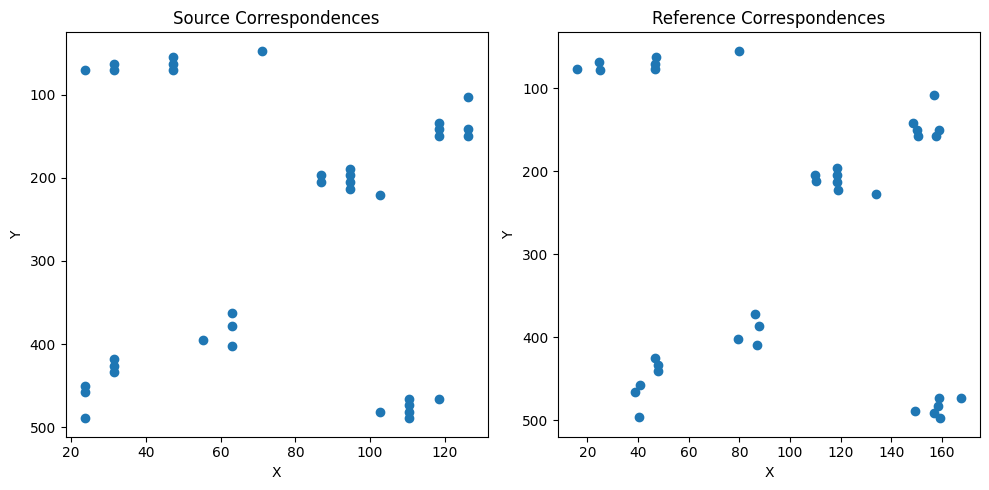

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Final correspondence points
src_final = np.float32([
    mkpts0[idx] for idx in quality_final_ids
])

ref_final = np.float32([
    mkpts1[idx] for idx in quality_final_ids
])

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(src_final[:, 0], src_final[:, 1])
plt.gca().invert_yaxis()
plt.title("Source Correspondences")
plt.xlabel("X")
plt.ylabel("Y")

plt.subplot(1, 2, 2)
plt.scatter(ref_final[:, 0], ref_final[:, 1])
plt.gca().invert_yaxis()
plt.title("Reference Correspondences")
plt.xlabel("X")
plt.ylabel("Y")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.spatial import Delaunay

# ---------------------------------------------------------
# 1. Final 36 correspondences
# ---------------------------------------------------------

src_all = np.float64([
    mkpts0[idx] for idx in quality_final_ids
])

ref_all = np.float64([
    mkpts1[idx] for idx in quality_final_ids
])

print("Total correspondences:", len(src_all))


# ---------------------------------------------------------
# 2. Fixed train/test split
# ---------------------------------------------------------

rng = np.random.default_rng(42)

indices = np.arange(len(src_all))
rng.shuffle(indices)

train_idx = indices[:27]
test_idx = indices[27:]

src_train = src_all[train_idx]
ref_train = ref_all[train_idx]

src_test = src_all[test_idx]
ref_test = ref_all[test_idx]

print("Training points:", len(src_train))
print("Validation points:", len(src_test))


# ---------------------------------------------------------
# 3. Delaunay triangulation on TRAINING source points
# ---------------------------------------------------------

tri = Delaunay(src_train)

print("Triangles:", len(tri.simplices))


# ---------------------------------------------------------
# 4. Find which triangle contains each test point
# ---------------------------------------------------------

simplex_ids = tri.find_simplex(src_test)

valid = simplex_ids >= 0

print("Validation points inside triangulation:",
      int(np.sum(valid)))

print("Validation points outside:",
      int(np.sum(~valid)))


# ---------------------------------------------------------
# 5. Piecewise-affine prediction
# ---------------------------------------------------------

predicted = np.full_like(
    ref_test,
    np.nan,
    dtype=np.float64
)

valid_indices = np.where(valid)[0]

for test_i in valid_indices:

    simplex = simplex_ids[test_i]

    triangle_vertices = tri.simplices[simplex]

    # Source triangle
    src_triangle = src_train[
        triangle_vertices
    ]

    # Corresponding reference triangle
    ref_triangle = ref_train[
        triangle_vertices
    ]

    # Barycentric transformation
    p = src_test[test_i]

    A = np.vstack([
        src_triangle.T,
        np.ones(3)
    ])

    b = np.append(p, 1.0)

    bary = np.linalg.solve(A, b)

    # Map using same barycentric coordinates
    predicted[test_i] = (
        bary[0] * ref_triangle[0]
        + bary[1] * ref_triangle[1]
        + bary[2] * ref_triangle[2]
    )


# ---------------------------------------------------------
# 6. Validation error
# ---------------------------------------------------------

valid_pred = predicted[valid]
valid_ref = ref_test[valid]

errors = np.linalg.norm(
    valid_pred - valid_ref,
    axis=1
)

rmse_piecewise = np.sqrt(
    np.mean(errors ** 2)
)

print("\nPIECEWISE-AFFINE VALIDATION")
print("---------------------------")
print("Valid validation points:", len(errors))
print("Mean error:", errors.mean())
print("Median error:", np.median(errors))
print("RMSE:", rmse_piecewise)
print("Maximum error:", errors.max())

Total correspondences: 36
Training points: 27
Validation points: 9
Triangles: 42
Validation points inside triangulation: 8
Validation points outside: 1

PIECEWISE-AFFINE VALIDATION
---------------------------
Valid validation points: 8
Mean error: 1.3200543609533568
Median error: 1.3106251371367998
RMSE: 1.375590690218946
Maximum error: 1.7978402198806227


In [ ]:
import cv2
import numpy as np

# ---------------------------------------------------------
# Same train/test split from the previous experiment
# ---------------------------------------------------------

# src_train, ref_train
# src_test, ref_test
# valid, valid_indices
# predicted
# already exist from Step 81

# ---------------------------------------------------------
# 1. Fit GLOBAL HOMOGRAPHY using the SAME 27 training pts
# ---------------------------------------------------------

H_train, mask_train = cv2.findHomography(
    src_train.reshape(-1, 1, 2),
    ref_train.reshape(-1, 1, 2),
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=10000,
    confidence=0.995
)

if H_train is None:
    raise RuntimeError("Training homography failed.")

# ---------------------------------------------------------
# 2. Predict ALL validation points
# ---------------------------------------------------------

homography_pred = cv2.perspectiveTransform(
    src_test.reshape(-1, 1, 2),
    H_train
).reshape(-1, 2)

# ---------------------------------------------------------
# 3. Evaluate homography on SAME 8 valid points
# ---------------------------------------------------------

homo_valid_pred = homography_pred[valid]
homo_valid_ref = ref_test[valid]

homo_errors = np.linalg.norm(
    homo_valid_pred - homo_valid_ref,
    axis=1
)

homo_rmse = np.sqrt(
    np.mean(homo_errors ** 2)
)

# ---------------------------------------------------------
# 4. Piecewise result was already stored
# ---------------------------------------------------------

piecewise_valid_pred = predicted[valid]
piecewise_valid_ref = ref_test[valid]

piecewise_errors = np.linalg.norm(
    piecewise_valid_pred - piecewise_valid_ref,
    axis=1
)

piecewise_rmse = np.sqrt(
    np.mean(piecewise_errors ** 2)
)

# ---------------------------------------------------------
# 5. Compare
# ---------------------------------------------------------

improvement = (
    (homo_rmse - piecewise_rmse)
    / homo_rmse
    * 100
)

print("FAIR MODEL COMPARISON")
print("---------------------")
print("Same validation points:", int(np.sum(valid)))

print("\nGlobal Homography")
print("RMSE:", homo_rmse)

print("\nPiecewise Affine")
print("RMSE:", piecewise_rmse)

print("\nImprovement:", improvement, "%")

FAIR MODEL COMPARISON
---------------------
Same validation points: 8

Global Homography
RMSE: 1.2437725858748432

Piecewise Affine
RMSE: 1.375590690218946

Improvement: -10.598248091421379 %


In [ ]:
import cv2
import numpy as np

thresholds = [0.30, 0.40, 0.50, 0.60]

print("CONFIDENCE THRESHOLD EXPERIMENT")
print("=" * 70)

for threshold in thresholds:

    # Keep only high-confidence LoFTR matches
    keep = confidence >= threshold

    filtered_src = mkpts0[keep]
    filtered_ref = mkpts1[keep]

    print(f"\nConfidence >= {threshold}")
    print("Candidate matches:", len(filtered_src))

    if len(filtered_src) < 4:
        print("Not enough matches")
        continue

    # RANSAC
    H_test, mask_test = cv2.findHomography(
        np.float32(filtered_src).reshape(-1, 1, 2),
        np.float32(filtered_ref).reshape(-1, 1, 2),
        method=cv2.RANSAC,
        ransacReprojThreshold=3.0,
        maxIters=10000,
        confidence=0.995
    )

    if H_test is None or mask_test is None:
        print("RANSAC failed")
        continue

    mask_test = mask_test.ravel()

    inliers = int(mask_test.sum())
    ratio = inliers / len(filtered_src)

    print("Inliers:", inliers)
    print("Inlier ratio:", ratio)

CONFIDENCE THRESHOLD EXPERIMENT

Confidence >= 0.3
Candidate matches: 109
Inliers: 42
Inlier ratio: 0.3853211009174312

Confidence >= 0.4
Candidate matches: 75
Inliers: 30
Inlier ratio: 0.4

Confidence >= 0.5
Candidate matches: 51
Inliers: 24
Inlier ratio: 0.47058823529411764

Confidence >= 0.6
Candidate matches: 31
Inliers: 14
Inlier ratio: 0.45161290322580644


In [ ]:
import cv2
import numpy as np

thresholds = [0.30, 0.40, 0.50, 0.60]

print("CONFIDENCE THRESHOLD + REPROJECTION ERROR")
print("=" * 65)

for threshold in thresholds:

    keep = confidence >= threshold

    pts_src = np.float32(mkpts0[keep]).reshape(-1, 1, 2)
    pts_ref = np.float32(mkpts1[keep]).reshape(-1, 1, 2)

    if len(pts_src) < 4:
        print(f"\nThreshold {threshold}: not enough points")
        continue

    H_test, mask_test = cv2.findHomography(
        pts_src,
        pts_ref,
        cv2.RANSAC,
        3.0,
        maxIters=10000,
        confidence=0.995
    )

    if H_test is None or mask_test is None:
        print(f"\nThreshold {threshold}: RANSAC failed")
        continue

    mask_test = mask_test.ravel()

    inlier_src = pts_src[mask_test == 1]
    inlier_ref = pts_ref[mask_test == 1]

    projected = cv2.perspectiveTransform(
        inlier_src,
        H_test
    )

    errors = np.linalg.norm(
        projected[:, 0, :] - inlier_ref[:, 0, :],
        axis=1
    )

    rmse = np.sqrt(np.mean(errors ** 2))

    print(f"\nThreshold >= {threshold}")
    print("Candidates:", len(pts_src))
    print("Inliers:", len(inlier_src))
    print("Inlier ratio:", len(inlier_src) / len(pts_src))
    print("Inlier RMSE:", rmse)

CONFIDENCE THRESHOLD + REPROJECTION ERROR

Threshold >= 0.3
Candidates: 109
Inliers: 42
Inlier ratio: 0.3853211009174312
Inlier RMSE: 1.8382349

Threshold >= 0.4
Candidates: 75
Inliers: 30
Inlier ratio: 0.4
Inlier RMSE: 1.6990677

Threshold >= 0.5
Candidates: 51
Inliers: 24
Inlier ratio: 0.47058823529411764
Inlier RMSE: 1.8167436

Threshold >= 0.6
Candidates: 31
Inliers: 14
Inlier ratio: 0.45161290322580644
Inlier RMSE: 1.1869963


In [ ]:
import numpy as np

threshold = 0.60

keep = confidence >= threshold

# Keep only high-confidence matches
pts_src = mkpts0[keep]

# Rerun RANSAC mask for this threshold
# mask_test should exist from the previous experiment
# Recompute safely here.

import cv2

src_pts = np.float32(pts_src).reshape(-1, 1, 2)
ref_pts = np.float32(mkpts1[keep]).reshape(-1, 1, 2)

H06, mask06 = cv2.findHomography(
    src_pts,
    ref_pts,
    cv2.RANSAC,
    3.0,
    maxIters=10000,
    confidence=0.995
)

mask06 = mask06.ravel()

inlier_src06 = pts_src[mask06 == 1]

h, w = source_clahe.shape

grid06 = np.zeros((3, 3), dtype=int)

for x, y in inlier_src06:
    col = min(int(x / (w / 3)), 2)
    row = min(int(y / (h / 3)), 2)
    grid06[row, col] += 1

print("High-confidence (>=0.60) inlier distribution:")
print(grid06)

print("Total inliers:", grid06.sum())
print("Occupied cells:", np.count_nonzero(grid06), "/ 9")

mean_grid = grid06.mean()
std_grid = grid06.std()

cv06 = std_grid / mean_grid if mean_grid > 0 else float("inf")

print("Spatial CV:", cv06)

High-confidence (>=0.60) inlier distribution:
[[3 2 4]
 [0 1 0]
 [0 2 2]]
Total inliers: 14
Occupied cells: 6 / 9
Spatial CV: 0.8630747123996123


In [ ]:
import cv2
import numpy as np

# ============================================================
# 1. RANSAC inliers
# ============================================================

inlier_ids = np.where(mask_loftr == 1)[0]

inlier_src = np.float32([
    mkpts0[i] for i in inlier_ids
]).reshape(-1, 1, 2)

inlier_ref = np.float32([
    mkpts1[i] for i in inlier_ids
]).reshape(-1, 1, 2)

# ============================================================
# 2. Reprojection error
# ============================================================

projected = cv2.perspectiveTransform(
    inlier_src,
    H_loftr
).reshape(-1, 2)

actual = inlier_ref.reshape(-1, 2)

errors = np.linalg.norm(
    projected - actual,
    axis=1
)

conf = confidence[inlier_ids]

# ============================================================
# 3. Normalize confidence and error
# ============================================================

conf_norm = (
    (conf - conf.min()) /
    (conf.max() - conf.min() + 1e-8)
)

error_score = 1.0 / (1.0 + errors)

error_norm = (
    (error_score - error_score.min()) /
    (error_score.max() - error_score.min() + 1e-8)
)

# Combined quality
quality = (
    0.5 * conf_norm +
    0.5 * error_norm
)

# ============================================================
# 4. Spatial grid
# ============================================================

ROWS = 3
COLS = 3

h, w = source_clahe.shape

cells = {
    (r, c): []
    for r in range(ROWS)
    for c in range(COLS)
}

for local_i, original_idx in enumerate(inlier_ids):

    x, y = mkpts0[original_idx]

    col = min(
        int(x / (w / COLS)),
        COLS - 1
    )

    row = min(
        int(y / (h / ROWS)),
        ROWS - 1
    )

    cells[(row, col)].append(local_i)

# ============================================================
# 5. Balanced selection
# ============================================================

selected_local = []

# First: select the strongest point from every occupied cell
for cell, indices in cells.items():

    if not indices:
        continue

    best = max(
        indices,
        key=lambda i: quality[i]
    )

    selected_local.append(best)

# Then: fill remaining slots with globally strongest points
MAX_TOTAL = 36

remaining = [
    i for i in range(len(inlier_ids))
    if i not in selected_local
]

remaining = sorted(
    remaining,
    key=lambda i: quality[i],
    reverse=True
)

for i in remaining:

    if len(selected_local) >= MAX_TOTAL:
        break

    selected_local.append(i)

selected_local = np.array(
    selected_local,
    dtype=int
)

selected_ids = inlier_ids[selected_local]

print("BALANCED MULTI-OBJECTIVE SELECTION")
print("-----------------------------------")
print("Original RANSAC inliers:", len(inlier_ids))
print("Selected matches:", len(selected_ids))

print("\nMean confidence:",
      conf[selected_local].mean())

print("Mean reprojection error:",
      errors[selected_local].mean())

print("Mean quality score:",
      quality[selected_local].mean())

BALANCED MULTI-OBJECTIVE SELECTION
-----------------------------------
Original RANSAC inliers: 49
Selected matches: 36

Mean confidence: 0.56613225
Mean reprojection error: 1.3231536
Mean quality score: 0.38928193


In [ ]:
import cv2
import numpy as np

# --------------------------------------------------
# Selected correspondence points
# --------------------------------------------------

balanced_src = np.float32([
    mkpts0[i]
    for i in selected_ids
]).reshape(-1, 1, 2)

balanced_ref = np.float32([
    mkpts1[i]
    for i in selected_ids
]).reshape(-1, 1, 2)

# --------------------------------------------------
# Final homography
# --------------------------------------------------

H_balanced, mask_balanced = cv2.findHomography(
    balanced_src,
    balanced_ref,
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=10000,
    confidence=0.995
)

if H_balanced is None or mask_balanced is None:
    raise RuntimeError("Balanced homography failed.")

mask_balanced = mask_balanced.ravel()

balanced_inliers = int(mask_balanced.sum())
balanced_ratio = balanced_inliers / len(selected_ids)

# --------------------------------------------------
# Reprojection RMSE
# --------------------------------------------------

balanced_inlier_src = balanced_src[mask_balanced == 1]

balanced_inlier_ref = balanced_ref[mask_balanced == 1]

balanced_projected = cv2.perspectiveTransform(
    balanced_inlier_src,
    H_balanced
)

balanced_errors = np.linalg.norm(
    balanced_projected[:, 0, :]
    - balanced_inlier_ref[:, 0, :],
    axis=1
)

balanced_rmse = np.sqrt(
    np.mean(balanced_errors ** 2)
)

# --------------------------------------------------
# Spatial distribution
# --------------------------------------------------

ROWS = 3
COLS = 3

h, w = source_clahe.shape

balanced_grid = np.zeros((ROWS, COLS), dtype=int)

# Use only final inliers
balanced_final_ids = selected_ids[mask_balanced == 1]

for idx in balanced_final_ids:

    x, y = mkpts0[idx]

    col = min(int(x / (w / COLS)), COLS - 1)
    row = min(int(y / (h / ROWS)), ROWS - 1)

    balanced_grid[row, col] += 1

mean_grid = balanced_grid.mean()
std_grid = balanced_grid.std()

balanced_cv = (
    std_grid / mean_grid
    if mean_grid > 0
    else float("inf")
)

balanced_occupancy = (
    np.count_nonzero(balanced_grid)
    / balanced_grid.size
)

print("BALANCED MODEL RESULT")
print("---------------------")
print("Selected:", len(selected_ids))
print("Final inliers:", balanced_inliers)
print("Final inlier ratio:", balanced_ratio)
print("RMSE:", balanced_rmse)

print("\nSpatial grid:")
print(balanced_grid)
print("Occupancy:", balanced_occupancy)
print("Spatial CV:", balanced_cv)

BALANCED MODEL RESULT
---------------------
Selected: 36
Final inliers: 36
Final inlier ratio: 1.0
RMSE: 1.575389

Spatial grid:
[[9 2 6]
 [0 4 1]
 [6 3 5]]
Occupancy: 0.8888888888888888
Spatial CV: 0.6666666666666666


In [ ]:
import cv2
import numpy as np
import math

# --------------------------------------------------
# Start from the real source image
# --------------------------------------------------

base = source_gray.copy()

h, w = base.shape

# Known transformation with SUB-PIXEL translation
scale_true = 1.2
angle_true = 5.0
tx_true = 12.35
ty_true = 7.65

center = (w / 2.0, h / 2.0)

M_true = cv2.getRotationMatrix2D(
    center,
    angle_true,
    scale_true
)

M_true[0, 2] += tx_true
M_true[1, 2] += ty_true

# --------------------------------------------------
# Create transformed image
# --------------------------------------------------

synthetic_subpixel = cv2.warpAffine(
    base,
    M_true,
    (w, h),
    flags=cv2.INTER_LINEAR
)

print("Known transformation")
print("--------------------")
print("Scale:", scale_true)
print("Rotation:", angle_true)
print("Translation:", (tx_true, ty_true))

# --------------------------------------------------
# Show
# --------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(base, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(synthetic_subpixel, cmap="gray")
plt.title("Synthetic Sub-pixel Test")
plt.axis("off")

plt.tight_layout()
plt.show()

NameError: name 'source_gray' is not defined

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load source image directly from Google Drive
source_path = (
    "/content/drive/MyDrive/"
    "SIH26_Lunar_Registration/data/source/source.jpeg"
)

source_gray = cv2.imread(
    source_path,
    cv2.IMREAD_GRAYSCALE
)

if source_gray is None:
    raise FileNotFoundError(
        f"Could not load: {source_path}"
    )

print("Source shape:", source_gray.shape)

Source shape: (513, 146)


Known transformation
--------------------
Scale: 1.2
Rotation: 5.0
Translation: (12.35, 7.65)


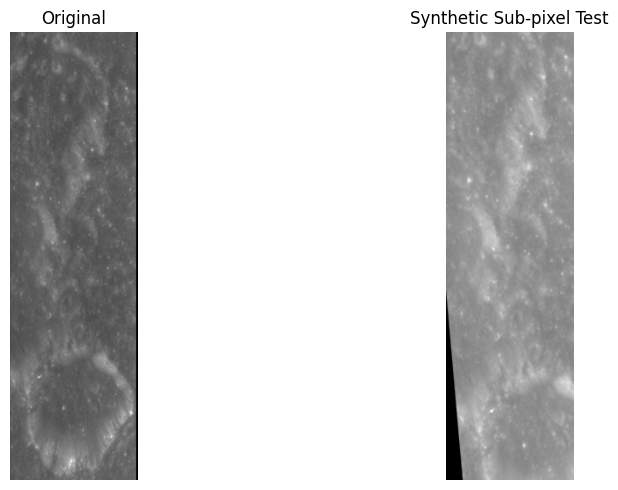

In [ ]:
# --------------------------------------------------
# Known sub-pixel transformation
# --------------------------------------------------

base = source_gray.copy()

h, w = base.shape

scale_true = 1.2
angle_true = 5.0
tx_true = 12.35
ty_true = 7.65

center = (w / 2.0, h / 2.0)

M_true = cv2.getRotationMatrix2D(
    center,
    angle_true,
    scale_true
)

M_true[0, 2] += tx_true
M_true[1, 2] += ty_true

# Create transformed image
synthetic_subpixel = cv2.warpAffine(
    base,
    M_true,
    (w, h),
    flags=cv2.INTER_LINEAR
)

print("Known transformation")
print("--------------------")
print("Scale:", scale_true)
print("Rotation:", angle_true)
print("Translation:", (tx_true, ty_true))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(base, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(synthetic_subpixel, cmap="gray")
plt.title("Synthetic Sub-pixel Test")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np

# --------------------------------------------------
# Sensitive SIFT
# --------------------------------------------------

sift = cv2.SIFT_create(
    nfeatures=10000,
    contrastThreshold=0.01,
    edgeThreshold=10,
    sigma=1.6
)

kp_original, des_original = sift.detectAndCompute(
    base,
    None
)

kp_synthetic, des_synthetic = sift.detectAndCompute(
    synthetic_subpixel,
    None
)

print("Original keypoints:", len(kp_original))
print("Synthetic keypoints:", len(kp_synthetic))

# --------------------------------------------------
# BF matching
# --------------------------------------------------

bf = cv2.BFMatcher(
    cv2.NORM_L2,
    crossCheck=False
)

knn = bf.knnMatch(
    des_original,
    des_synthetic,
    k=2
)

# --------------------------------------------------
# Ratio test
# --------------------------------------------------

good = []

for pair in knn:

    if len(pair) != 2:
        continue

    m, n = pair

    if m.distance < 0.75 * n.distance:
        good.append(m)

print("Good matches:", len(good))

Original keypoints: 911
Synthetic keypoints: 813
Good matches: 361


In [ ]:
import cv2
import numpy as np
import math

# --------------------------------------------------
# Matched points
# --------------------------------------------------

src_pts = np.float32([
    kp_original[m.queryIdx].pt
    for m in good
]).reshape(-1, 1, 2)

syn_pts = np.float32([
    kp_synthetic[m.trainIdx].pt
    for m in good
]).reshape(-1, 1, 2)

# --------------------------------------------------
# Estimate ORIGINAL -> SYNTHETIC transformation
# --------------------------------------------------

M_est, mask_est = cv2.estimateAffinePartial2D(
    src_pts,
    syn_pts,
    method=cv2.RANSAC,
    ransacReprojThreshold=3.0,
    maxIters=10000,
    confidence=0.999
)

if M_est is None or mask_est is None:
    raise RuntimeError("Affine estimation failed.")

mask_est = mask_est.ravel()

inliers = int(mask_est.sum())
inlier_ratio = inliers / len(good)

print("Affine estimation")
print("-----------------")
print("Candidate matches:", len(good))
print("Inliers:", inliers)
print("Inlier ratio:", inlier_ratio)

print("\nEstimated matrix:")
print(M_est)

# --------------------------------------------------
# Extract estimated scale and rotation
# --------------------------------------------------

a = M_est[0, 0]
b = M_est[0, 1]
c = M_est[1, 0]
d = M_est[1, 1]

estimated_scale = np.sqrt(a*a + c*c)

estimated_angle = math.degrees(
    math.atan2(c, a)
)

estimated_translation = M_est[:, 2]

print("\nEstimated parameters")
print("--------------------")
print("Scale:", estimated_scale)
print("Rotation:", estimated_angle)
print("Translation:", estimated_translation)

# --------------------------------------------------
# Ground truth
# --------------------------------------------------

print("\nGround truth")
print("------------")
print("Scale:", scale_true)
print("Rotation:", angle_true)
print("Translation:", (tx_true, ty_true))

# --------------------------------------------------
# Parameter errors
# --------------------------------------------------

print("\nParameter errors")
print("----------------")
print(
    "Scale error:",
    estimated_scale - scale_true
)

print(
    "Rotation error:",
    estimated_angle - angle_true
)

print(
    "Translation X error:",
    estimated_translation[0] - tx_true
)

print(
    "Translation Y error:",
    estimated_translation[1] - ty_true
)

Affine estimation
-----------------
Candidate matches: 361
Inliers: 359
Inlier ratio: 0.9944598337950139

Estimated matrix:
[[  1.19545983   0.10447955 -28.80976147]
 [ -0.10447955   1.19545983 -34.88143309]]

Estimated parameters
--------------------
Scale: 1.2000167403331132
Rotation: -4.994785339624832
Translation: [-28.80976147 -34.88143309]

Ground truth
------------
Scale: 1.2
Rotation: 5.0
Translation: (12.35, 7.65)

Parameter errors
----------------
Scale error: 1.6740333113274275e-05
Rotation error: -9.994785339624832
Translation X error: -41.15976146574207
Translation Y error: -42.531433088285226


In [ ]:
import numpy as np
import cv2

# --------------------------------------------------
# Convert both matrices to 3x3
# --------------------------------------------------

M_true_3x3 = np.vstack([
    M_true,
    [0, 0, 1]
])

M_est_3x3 = np.vstack([
    M_est,
    [0, 0, 1]
])

# --------------------------------------------------
# Create test points across the source image
# --------------------------------------------------

h, w = base.shape

test_points = np.array([
    [w * 0.10, h * 0.10],
    [w * 0.50, h * 0.10],
    [w * 0.90, h * 0.10],
    [w * 0.10, h * 0.50],
    [w * 0.50, h * 0.50],
    [w * 0.90, h * 0.50],
    [w * 0.10, h * 0.90],
    [w * 0.50, h * 0.90],
    [w * 0.90, h * 0.90]
], dtype=np.float64)

# --------------------------------------------------
# Apply TRUE transformation
# --------------------------------------------------

points_h = np.hstack([
    test_points,
    np.ones((len(test_points), 1))
])

true_points = (
    M_true_3x3 @ points_h.T
).T[:, :2]

# --------------------------------------------------
# Apply ESTIMATED transformation
# --------------------------------------------------

estimated_points = (
    M_est_3x3 @ points_h.T
).T[:, :2]

# --------------------------------------------------
# Coordinate errors
# --------------------------------------------------

errors = np.linalg.norm(
    true_points - estimated_points,
    axis=1
)

rmse = np.sqrt(np.mean(errors ** 2))

print("TRUE TRANSFORMATION MATRIX")
print(M_true)

print("\nESTIMATED TRANSFORMATION MATRIX")
print(M_est)

print("\nPOINT-WISE ERRORS")
print(errors)

print("\nMean coordinate error:", errors.mean())
print("RMSE:", rmse)
print("Maximum error:", errors.max())

TRUE TRANSFORMATION MATRIX
[[  1.19543364   0.10458689 -28.74319317]
 [ -0.10458689   1.19543364 -34.84388501]]

ESTIMATED TRANSFORMATION MATRIX
[[  1.19545983   0.10447955 -28.80976147]
 [ -0.10447955   1.19545983 -34.88143309]]

POINT-WISE ERRORS
[0.07962143 0.07568109 0.0721038  0.09818169 0.0950142  0.09219018
 0.11818561 0.1155677  0.11325734]

Mean coordinate error: 0.0955336709928337
RMSE: 0.09694413396139885
Maximum error: 0.11818561123283593


In [ ]:
%%writefile /content/drive/MyDrive/SIH26_Lunar_Registration/app/app.py
import time
import cv2
import numpy as np
import torch
import streamlit as st
import matplotlib.pyplot as plt
from kornia.feature import LoFTR

# ============================================================
# 1. CORE REGISTRATION ENGINE (Logically Intact)
# ============================================================

_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

@st.cache_resource
def load_loftr_matcher():
    matcher = LoFTR(pretrained="outdoor").to(_DEVICE)
    matcher.eval()
    return matcher

def preprocess_image(image):
    if image is None: raise ValueError("Input image is None.")
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image.copy()
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return gray, clahe.apply(gray)

def calculate_spatial_grid(points, image_shape, rows=3, cols=3):
    h, w = image_shape
    grid = np.zeros((rows, cols), dtype=int)
    for x, y in points:
        col = min(int(x / (w / cols)), cols - 1)
        row = min(int(y / (h / rows)), rows - 1)
        grid[row, col] += 1
    return grid

def register_images(source_image, reference_image, max_per_cell=6, ransac_threshold=3.0):
    start_time = time.perf_counter()
    _MATCHER = load_loftr_matcher()
    source_gray, source_clahe = preprocess_image(source_image)
    reference_gray, reference_clahe = preprocess_image(reference_image)

    source_tensor = torch.from_numpy(source_clahe.astype(np.float32) / 255.0)[None, None].to(_DEVICE)
    reference_tensor = torch.from_numpy(reference_clahe.astype(np.float32) / 255.0)[None, None].to(_DEVICE)

    with torch.no_grad():
        output = _MATCHER({"image0": source_tensor, "image1": reference_tensor})

    mkpts0, mkpts1, confidence = output["keypoints0"].cpu().numpy(), output["keypoints1"].cpu().numpy(), output["confidence"].cpu().numpy()
    H_initial, mask_initial = cv2.findHomography(mkpts0, mkpts1, cv2.RANSAC, ransac_threshold)
    if H_initial is None: raise RuntimeError("Initial RANSAC failed.")

    inlier_ids = np.where(mask_initial.ravel() == 1)[0]
    proj = cv2.perspectiveTransform(mkpts0[inlier_ids].reshape(-1, 1, 2), H_initial).reshape(-1, 2)
    errors = np.linalg.norm(proj - mkpts1[inlier_ids], axis=1)
    quality_score = confidence[inlier_ids] / (1.0 + errors)

    h, w = source_clahe.shape
    cells = {(r, c): [] for r in range(3) for c in range(3)}
    for local_idx, original_idx in enumerate(inlier_ids):
        col, row = min(int(mkpts0[original_idx][0] / (w / 3)), 2), min(int(mkpts0[original_idx][1] / (h / 3)), 2)
        cells[(row, col)].append(local_idx)

    selected_local = []
    for cell, indices in cells.items():
        selected_local.extend(sorted(indices, key=lambda i: quality_score[i], reverse=True)[:max_per_cell])

    selected_ids = inlier_ids[selected_local]
    H_final, mask_final = cv2.findHomography(mkpts0[selected_ids], mkpts1[selected_ids], cv2.RANSAC, ransac_threshold)
    final_inlier_ids = selected_ids[mask_final.ravel() == 1]

    src_f, ref_f = mkpts0[final_inlier_ids], mkpts1[final_inlier_ids]
    proj_f = cv2.perspectiveTransform(src_f.reshape(-1, 1, 2), H_final).reshape(-1, 2)
    final_errs = np.linalg.norm(proj_f - ref_f, axis=1)

    reg_img = cv2.warpPerspective(source_gray, H_final, (reference_gray.shape[1], reference_gray.shape[0]))

    s_v, r_v = cv2.cvtColor(source_clahe, cv2.COLOR_GRAY2BGR), cv2.cvtColor(reference_clahe, cv2.COLOR_GRAY2BGR)
    canvas = np.zeros((max(s_v.shape[0], r_v.shape[0]), s_v.shape[1] + r_v.shape[1], 3), dtype=np.uint8)
    canvas[:s_v.shape[0], :s_v.shape[1]], canvas[:r_v.shape[0], s_v.shape[1]:] = s_v, r_v
    for i in final_inlier_ids:
        cv2.line(canvas, (int(mkpts0[i][0]), int(mkpts0[i][1])), (int(mkpts1[i][0] + s_v.shape[1]), int(mkpts1[i][1])), (0, 255, 255), 1)

    return {
        "registered_image": reg_img, "match_visualization": canvas, "spatial_grid": calculate_spatial_grid(src_f, source_clahe.shape),
        "candidate_matches": len(mkpts0), "initial_inliers": len(inlier_ids), "selected_matches": len(selected_ids), "final_inliers": len(final_inlier_ids),
        "final_inlier_ratio": len(final_inlier_ids)/len(selected_ids), "rmse": float(np.sqrt(np.mean(final_errs**2))), "mean_error": float(np.mean(final_errs)),
        "median_error": float(np.median(final_errs)), "max_error": float(np.max(final_errs)), "occupancy_ratio": np.count_nonzero(calculate_spatial_grid(src_f, source_clahe.shape))/9,
        "spatial_cv": np.std(calculate_spatial_grid(src_f, source_clahe.shape))/np.mean(calculate_spatial_grid(src_f, source_clahe.shape)), "runtime": time.perf_counter() - start_time, "device": _DEVICE,
        "occupied_cells": int(np.count_nonzero(calculate_spatial_grid(src_f, source_clahe.shape))), "total_cells": 9
    }

# ============================================================
# 2. POLISHED MISSION CONTROL UI
# ============================================================

st.set_page_config(page_title="Lunar Registration System", page_icon="🌙", layout="wide")

st.markdown("""
    <style>
    .main { background-color: #0e1117; color: #e0e6ed; }
    .stMetric { background-color: #1c2128; border: 1px solid #30363d; padding: 10px; border-radius: 5px; }
    [data-testid='stMetricValue'] { color: #00f2ff; font-family: 'Courier New', monospace; }
    .img-container { border: 1px solid #30363d; padding: 5px; border-radius: 4px; background: #161b22; }
    .stButton>button { background-color: #008bcf; color: white; border: none; font-weight: bold; width: 100%; height: 3.5em; }
    h1, h2, h3 { color: #58a6ff; letter-spacing: 1px; }
    </style>
""", unsafe_allow_html=True)

st.title("🌙 Lunar Image Registration System")
st.markdown("**Chandrayaan-2 ↔ Lunar Reference Image Registration**")
st.caption("Pipeline: CLAHE → LoFTR → RANSAC → Quality + Spatial Selection → Homography")
st.divider()

# --- Input Section ---
col_in1, col_in2 = st.columns(2)
with col_in1: src_file = st.file_uploader("Source / Moving Image", type=["jpg","jpeg","png","tif"], key="u_source")
with col_in2: ref_file = st.file_uploader("Reference / Fixed Image", type=["jpg","jpeg","png","tif"], key="u_reference")

if src_file and ref_file:
    s_img = cv2.imdecode(np.frombuffer(src_file.read(), np.uint8), cv2.IMREAD_COLOR)
    r_img = cv2.imdecode(np.frombuffer(ref_file.read(), np.uint8), cv2.IMREAD_COLOR)

    c_pre1, c_pre2 = st.columns(2)
    c_pre1.image(cv2.cvtColor(s_img, cv2.COLOR_BGR2RGB), caption="Source Preview", use_container_width=True)
    c_pre2.image(cv2.cvtColor(r_img, cv2.COLOR_BGR2RGB), caption="Reference Preview", use_container_width=True)

    if st.button("🚀 INITIATE ALIGNMENT SEQUENCE", type="primary"):
        st.session_state.pop("registration_result", None)
        with st.spinner("Executing Scientific Pipeline..."):
            try:
                res = register_images(s_img, r_img)
                st.session_state["registration_result"] = res
                st.session_state["reference_img_data"] = r_img
            except Exception as e:
                st.error(f"Alignment Failed: {str(e)}")

# --- Result Section ---
if "registration_result" in st.session_state:
    res = st.session_state["registration_result"]
    r_img = st.session_state["reference_img_data"]
    st.success("Registration Locked.")

    m_c1, m_c2, m_c3, m_c4 = st.columns(4)
    m_c1.metric("LoFTR Matches", res["candidate_matches"])
    m_c2.metric("Final Inliers", res["final_inliers"])
    m_c3.metric("Inlier Ratio", f"{res['final_inlier_ratio']*100:.2f}%")
    m_c4.metric("RMSE", f"{res['rmse']:.3f} px")

    m_c5, m_c6, m_c7, m_c8 = st.columns(4)
    m_c5.metric("Selected Subset", res["selected_matches"])
    m_c6.metric("Spatial Coverage", f"{res['occupancy_ratio']*100:.1f}%")
    m_c7.metric("Spatial CV", f"{res['spatial_cv']:.3f}")
    m_c8.metric("Runtime", f"{res['runtime']:.2f}s")

    st.subheader("Alignment Verification")
    r_col1, r_col2 = st.columns(2)
    r_col1.image(res["registered_image"], caption="Registered Source", use_container_width=True)
    r_col2.image(cv2.cvtColor(r_img, cv2.COLOR_BGR2GRAY), caption="Reference", use_container_width=True)

    tab1, tab2, tab3 = st.tabs(["Alignment Overlay", "Correspondence Set", "Spatial Heatmap"])
    with tab1:
        ref_g = cv2.cvtColor(r_img, cv2.COLOR_BGR2GRAY)
        overlay = cv2.addWeighted(ref_g.astype(float), 0.5, res["registered_image"].astype(float), 0.5, 0).astype(np.uint8)
        st.image(overlay, caption="Composite Blend (50/50)", use_container_width=True)
    with tab2:
        st.image(cv2.cvtColor(res["match_visualization"], cv2.COLOR_BGR2RGB), caption="RANSAC Verified Pairs", use_container_width=True)
    with tab3:
        fig, ax = plt.subplots(figsize=(4, 3))
        fig.patch.set_facecolor('#0e1117'); ax.set_facecolor('#1c2128')
        im = ax.imshow(res["spatial_grid"], cmap="Blues")
        for (j,i), v in np.ndenumerate(res["spatial_grid"]): ax.text(i,j,str(v),ha='center',va='center',color='white',fontweight='bold')
        ax.axis('off'); st.pyplot(fig)

    with st.expander("Technical Analytics"):
        st.json({k: v for k, v in res.items() if isinstance(v, (int, float, str))})


Overwriting /content/drive/MyDrive/SIH26_Lunar_Registration/app/app.py


In [ ]:
import os

project_dir = "/content/drive/MyDrive/SIH26_Lunar_Registration"
app_dir = f"{project_dir}/app"

os.makedirs(app_dir, exist_ok=True)

print("Project exists:", os.path.exists(project_dir))
print("App folder exists:", os.path.exists(app_dir))
print("App folder:", app_dir)

Project exists: True
App folder exists: True
App folder: /content/drive/MyDrive/SIH26_Lunar_Registration/app


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/SIH26_Lunar_Registration"))

['data', 'results', 'app']


In [ ]:
import sys
import importlib

app_path = "/content/drive/MyDrive/SIH26_Lunar_Registration/app"

if app_path not in sys.path:
    sys.path.insert(0, app_path)

import app
importlib.reload(app)

print("app.py imported successfully ✅")
print("Device:", app._DEVICE)
print("register_images:", callable(app.register_images))

app.py imported successfully ✅
Device: cpu
register_images: True


=== PROTOTYPE RESULT ===
Candidate matches: 166
Initial RANSAC inliers: 49
Selected matches: 38
Final inliers: 36
Final inlier ratio: 0.9473684210526315
Spatial occupancy: 0.8888888888888888
Spatial CV: 0.5328541245083313
RMSE: 1.5388751029968262
Mean error: 1.3755192756652832
Median error: 1.1826951503753662
Maximum error: 2.8410825729370117
Runtime: 3.7382947079995574 seconds


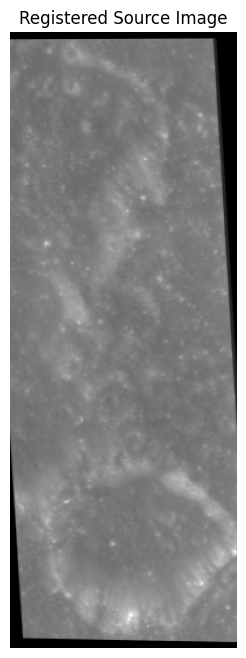

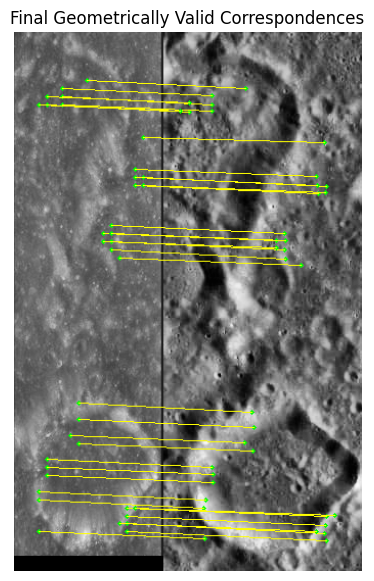

In [ ]:
import cv2
import matplotlib.pyplot as plt

source_path = (
    "/content/drive/MyDrive/"
    "SIH26_Lunar_Registration/data/source/source.jpeg"
)

reference_path = (
    "/content/drive/MyDrive/"
    "SIH26_Lunar_Registration/data/reference/reference.jpeg"
)

source_img = cv2.imread(source_path)
reference_img = cv2.imread(reference_path)

result = app.register_images(
    source_img,
    reference_img
)

print("=== PROTOTYPE RESULT ===")
print("Candidate matches:", result["candidate_matches"])
print("Initial RANSAC inliers:", result["initial_inliers"])
print("Selected matches:", result["selected_matches"])
print("Final inliers:", result["final_inliers"])
print("Final inlier ratio:", result["final_inlier_ratio"])
print("Spatial occupancy:", result["occupancy_ratio"])
print("Spatial CV:", result["spatial_cv"])
print("RMSE:", result["rmse"])
print("Mean error:", result["mean_error"])
print("Median error:", result["median_error"])
print("Maximum error:", result["max_error"])
print("Runtime:", result["runtime"], "seconds")

# Display registered image
plt.figure(figsize=(6, 8))
plt.imshow(result["registered_image"], cmap="gray")
plt.title("Registered Source Image")
plt.axis("off")
plt.show()

# Display final correspondences
plt.figure(figsize=(12, 7))
plt.imshow(
    cv2.cvtColor(
        result["match_visualization"],
        cv2.COLOR_BGR2RGB
    )
)
plt.title("Final Geometrically Valid Correspondences")
plt.axis("off")
plt.show()

In [ ]:
print("==========================================")
print("      LUNAR IMAGE REGISTRATION DEMO")
print("==========================================")

print(f"Candidate LoFTR matches : {result['candidate_matches']}")
print(f"Initial RANSAC inliers  : {result['initial_inliers']}")
print(f"Selected matches        : {result['selected_matches']}")
print(f"Final inliers           : {result['final_inliers']}")

print("------------------------------------------")

print(f"Final inlier ratio      : {result['final_inlier_ratio']*100:.2f}%")
print(f"Spatial occupancy       : {result['occupancy_ratio']*100:.2f}%")
print(f"Spatial CV              : {result['spatial_cv']:.3f}")

print("------------------------------------------")

print(f"Mean reprojection error : {result['mean_error']:.3f} px")
print(f"Median error            : {result['median_error']:.3f} px")
print(f"RMSE                    : {result['rmse']:.3f} px")
print(f"Maximum error           : {result['max_error']:.3f} px")

print("------------------------------------------")

print(f"Runtime                 : {result['runtime']:.2f} sec")
print(f"Device                  : {result['device']}")

print("==========================================")

      LUNAR IMAGE REGISTRATION DEMO
Candidate LoFTR matches : 166
Initial RANSAC inliers  : 49
Selected matches        : 38
Final inliers           : 36
------------------------------------------
Final inlier ratio      : 94.74%
Spatial occupancy       : 88.89%
Spatial CV              : 0.533
------------------------------------------
Mean reprojection error : 1.376 px
Median error            : 1.183 px
RMSE                    : 1.539 px
Maximum error           : 2.841 px
------------------------------------------
Runtime                 : 3.74 sec
Device                  : cpu


In [ ]:
%%writefile /tmp/ui_code.txt

import streamlit as st


# ============================================================
# STREAMLIT UI
# ============================================================

st.set_page_config(
    page_title="Lunar Image Registration",
    page_icon="🌙",
    layout="wide"
)

st.title("🌙 Lunar Image Registration System")
st.caption(
    "Chandrayaan-2 ↔ Lunar Reference Image Registration"
)

st.markdown(
    """
    **Pipeline:** CLAHE → LoFTR → RANSAC →
    Quality + Spatial Selection → Homography
    """
)

st.divider()

# ------------------------------------------------------------
# Upload images
# ------------------------------------------------------------

left, right = st.columns(2)

with left:
    source_file = st.file_uploader(
        "Source / Moving Image",
        type=["jpg", "jpeg", "png", "tif", "tiff"],
        key="source"
    )

with right:
    reference_file = st.file_uploader(
        "Reference / Fixed Image",
        type=["jpg", "jpeg", "png", "tif", "tiff"],
        key="reference"
    )

# ------------------------------------------------------------
# Register button
# ------------------------------------------------------------

if source_file is not None and reference_file is not None:

    source_bytes = np.asarray(
        bytearray(source_file.read()),
        dtype=np.uint8
    )

    reference_bytes = np.asarray(
        bytearray(reference_file.read()),
        dtype=np.uint8
    )

    source_image = cv2.imdecode(
        source_bytes,
        cv2.IMREAD_COLOR
    )

    reference_image = cv2.imdecode(
        reference_bytes,
        cv2.IMREAD_COLOR
    )

    if source_image is None:
        st.error("Could not decode source image.")

    elif reference_image is None:
        st.error("Could not decode reference image.")

    else:

        # ----------------------------------------------------
        # Preview inputs
        # ----------------------------------------------------

        preview1, preview2 = st.columns(2)

        with preview1:
            st.image(
                cv2.cvtColor(
                    source_image,
                    cv2.COLOR_BGR2RGB
                ),
                caption="Source / Moving Image",
                use_container_width=True
            )

        with preview2:
            st.image(
                cv2.cvtColor(
                    reference_image,
                    cv2.COLOR_BGR2RGB
                ),
                caption="Reference / Fixed Image",
                use_container_width=True
            )

        st.divider()

        if st.button(
            "🚀 REGISTER IMAGES",
            type="primary",
            use_container_width=True
        ):

            with st.spinner(
                "Running lunar image registration..."
            ):

                try:

                    result = register_images(
                        source_image,
                        reference_image
                    )

                    st.session_state["result"] = result

                except Exception as e:

                    st.error(
                        f"Registration failed: {e}"
                    )


# ============================================================
# RESULTS
# ============================================================

if "result" in st.session_state:

    result = st.session_state["result"]

    st.success(
        "Registration completed successfully."
    )

    # --------------------------------------------------------
    # Main registered image
    # --------------------------------------------------------

    st.subheader("Registered Source Image")

    st.image(
        result["registered_image"],
        caption="Source aligned to reference coordinate system",
        use_container_width=True
    )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    st.subheader("Registration Metrics")

    c1, c2, c3, c4 = st.columns(4)

    c1.metric(
        "LoFTR Matches",
        result["candidate_matches"]
    )

    c2.metric(
        "Final Inliers",
        result["final_inliers"]
    )

    c3.metric(
        "Inlier Ratio",
        f"{result['final_inlier_ratio'] * 100:.2f}%"
    )

    c4.metric(
        "RMSE",
        f"{result['rmse']:.3f} px"
    )

    c5, c6, c7, c8 = st.columns(4)

    c5.metric(
        "Selected Matches",
        result["selected_matches"]
    )

    c6.metric(
        "Spatial Coverage",
        f"{result['occupancy_ratio'] * 100:.1f}%"
    )

    c7.metric(
        "Spatial CV",
        f"{result['spatial_cv']:.3f}"
    )

    c8.metric(
        "Runtime",
        f"{result['runtime']:.2f} s"
    )

    # --------------------------------------------------------
    # Correspondence visualization
    # --------------------------------------------------------

    st.subheader(
        "Geometrically Valid Correspondences"
    )

    st.image(
        cv2.cvtColor(
            result["match_visualization"],
            cv2.COLOR_BGR2RGB
        ),
        caption="Final RANSAC-verified correspondence set",
        use_container_width=True
    )

    # --------------------------------------------------------
    # Spatial distribution
    # --------------------------------------------------------

    st.subheader(
        "Spatial Distribution of Selected Matches"
    )

    st.dataframe(
        result["spatial_grid"],
        use_container_width=True
    )

    st.caption(
        "Lower Spatial CV indicates a more balanced "
        "distribution of correspondence points."
    )

    # --------------------------------------------------------
    # Technical details
    # --------------------------------------------------------

    with st.expander("Technical Details"):

        st.write(
            "Device:",
            result["device"]
        )

        st.write(
            "Initial RANSAC inliers:",
            result["initial_inliers"]
        )

        st.write(
            "Mean reprojection error:",
            f"{result['mean_error']:.3f} px"
        )

        st.write(
            "Median reprojection error:",
            f"{result['median_error']:.3f} px"
        )

        st.write(
            "Maximum reprojection error:",
            f"{result['max_error']:.3f} px"
        )

        st.write(
            "Occupied spatial cells:",
            f"{result['occupied_cells']} / "
            f"{result['total_cells']}"
        )

Writing /tmp/ui_code.txt


In [ ]:
import shutil

source_ui = "/tmp/ui_code.txt"
target_app = (
    "/content/drive/MyDrive/"
    "SIH26_Lunar_Registration/app/app.py"
)

with open(source_ui, "r", encoding="utf-8") as f:
    ui_code = f.read()

with open(target_app, "a", encoding="utf-8") as f:
    f.write("\n\n" + ui_code)

print("Streamlit UI added to app.py ✅")

Streamlit UI added to app.py ✅


In [ ]:
import py_compile

app_file = (
    "/content/drive/MyDrive/"
    "SIH26_Lunar_Registration/app/app.py"
)

py_compile.compile(
    app_file,
    doraise=True
)

print("app.py syntax check passed ✅")

app.py syntax check passed ✅


In [ ]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 49.6 MB/s eta 0:00:00


In [ ]:
import subprocess

app_path = "/content/drive/MyDrive/SIH26_Lunar_Registration/app/app.py"

process = subprocess.Popen(
    ["streamlit", "run", app_path, "--server.port", "8501"]
)

print("Streamlit started.")

Streamlit started.


In [ ]:
!pip install -q pyngrok

In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print("Open this URL:")
print(public_url)

ERROR:pyngrok.process.ngrok:t=2026-08-26T13:42:56+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-08-26T13:42:56+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [ ]:
!streamlit run "/content/drive/MyDrive/SIH26_Lunar_Registration/app/app.py" \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.headless true \
    > /tmp/streamlit.log 2>&1 &

In [ ]:
!cat /tmp/streamlit.log



2026-08-26 13:43:37.660 Port 8501 is not available


In [ ]:
from google.colab.output import eval_js

url = eval_js(
    "google.colab.kernel.proxyPort(8501)"
)

print(url)

https://8501-m-s-kkb-use1d0-3e2xv169kgrsm-d.us-east1-0.prod.colab.dev


In [ ]:
!streamlit run "/content/drive/MyDrive/SIH26_Lunar_Registration/app/app.py" \
    --server.port 8502 \
    --server.address 0.0.0.0 \
    --server.headless true \
    > /tmp/streamlit_8502.log 2>&1 &

In [ ]:
!cat /tmp/streamlit_8502.log



2026-08-26 13:46:57.927 Uvicorn server started on 0.0.0.0:8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://34.75.32.199:8502



In [ ]:
from google.colab.output import eval_js

url = eval_js(
    "google.colab.kernel.proxyPort(8502)"
)

print(url)

https://8502-m-s-kkb-use1d0-3e2xv169kgrsm-d.us-east1-0.prod.colab.dev


In [ ]:
!tail -50 /tmp/streamlit_8502.log



2026-08-26 13:46:57.927 Uvicorn server started on 0.0.0.0:8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://34.75.32.199:8502

2026-08-26 13:48:36.019 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8502-m-s-kkb-use1d0-3e2xv169kgrsm-d.us-east1-0.prod.colab.dev, host=m-s-kkb-use1d0-3e2xv169kgrsm.us-east1-d.c.codatalab-user-runtimes.internal:8007
2026-08-26 13:48:39.730 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8502-m-s-kkb-use1d0-3e2xv169kgrsm-d.us-east1-0.prod.colab.dev, host=m-s-kkb-use1d0-3e2xv169kgrsm.us-east1-d.c.codatalab-user-runtimes.internal:8007
2026-08-26 13:48:44.480 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8502-m-s-kkb-use1d0-3e2xv169kgrsm-d.us-east1-0.prod.colab.dev, host=m-s-kkb-use1d0-3e2xv169kgrsm.us-east1-d.c.codatalab-user-runtimes.inter

In [ ]:
!tail -100 /tmp/streamlit_8502.log



2026-08-26 13:46:57.927 Uvicorn server started on 0.0.0.0:8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://34.75.32.199:8502

2026-08-26 13:48:36.019 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8502-m-s-kkb-use1d0-3e2xv169kgrsm-d.us-east1-0.prod.colab.dev, host=m-s-kkb-use1d0-3e2xv169kgrsm.us-east1-d.c.codatalab-user-runtimes.internal:8007
2026-08-26 13:48:39.730 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8502-m-s-kkb-use1d0-3e2xv169kgrsm-d.us-east1-0.prod.colab.dev, host=m-s-kkb-use1d0-3e2xv169kgrsm.us-east1-d.c.codatalab-user-runtimes.internal:8007
2026-08-26 13:48:44.480 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8502-m-s-kkb-use1d0-3e2xv169kgrsm-d.us-east1-0.prod.colab.dev, host=m-s-kkb-use1d0-3e2xv169kgrsm.us-east1-d.c.codatalab-user-runtimes.inter

In [ ]:
# Stop old Streamlit processes
!pkill -f "streamlit run" || true

# Start Streamlit with proxy-friendly settings
!streamlit run "/content/drive/MyDrive/SIH26_Lunar_Registration/app/app.py" \
    --server.port 8502 \
    --server.address 0.0.0.0 \
    --server.headless true \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    --server.websocketCompression false \
    > /tmp/streamlit_8502.log 2>&1 &

^C


In [ ]:
!tail -20 /tmp/streamlit_8502.log

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: No such option '--server.websocketCompression'. (Did you mean one of: '--server.disconnectedSessionTTL', '--server.enableWebsocketCompression', '--server.websocketPingInterval'?)


In [ ]:
!pkill -f "streamlit run" || true

^C


In [ ]:
!streamlit run "/content/drive/MyDrive/SIH26_Lunar_Registration/app/app.py" \
    --server.port 8502 \
    --server.address 0.0.0.0 \
    --server.headless true \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    --server.enableWebsocketCompression false \
    > /tmp/streamlit_8502.log 2>&1 &

In [ ]:
!tail -30 /tmp/streamlit_8502.log



2026-08-26 13:58:24.444 Uvicorn server started on 0.0.0.0:8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://34.75.32.199:8502



In [ ]:
from google.colab.output import eval_js

url = eval_js(
    "google.colab.kernel.proxyPort(8502)"
)

print(url)

https://8502-m-s-kkb-use1d0-3e2xv169kgrsm-d.us-east1-0.prod.colab.dev


In [ ]:
import os

app_file = (
    "/content/drive/MyDrive/"
    "SIH26_Lunar_Registration/app/app.py"
)

with open(app_file, "r", encoding="utf-8") as f:
    full_code = f.read()

marker = "# STREAMLIT UI"

if marker not in full_code:
    raise RuntimeError(
        "Could not find the Streamlit UI section."
    )

# Keep the complete registration engine.
engine_code = full_code.split(marker)[0]

ui_code = r'''
# ============================================================
# STREAMLIT UI
# ============================================================

import streamlit as st
import matplotlib.pyplot as plt


st.set_page_config(
    page_title="Lunar Image Registration",
    page_icon="🌙",
    layout="wide"
)

st.title("🌙 Lunar Image Registration System")

st.caption(
    "Chandrayaan-2 ↔ Lunar Reference Image Registration"
)

st.markdown(
    """
    **Pipeline**

    CLAHE → LoFTR → RANSAC → Quality + Spatial Selection → Homography
    """
)

st.divider()

# ============================================================
# IMAGE UPLOAD
# ============================================================

left, right = st.columns(2)

with left:

    source_file = st.file_uploader(
        "Source / Moving Image",
        type=[
            "jpg",
            "jpeg",
            "png",
            "tif",
            "tiff"
        ],
        key="source"
    )

with right:

    reference_file = st.file_uploader(
        "Reference / Fixed Image",
        type=[
            "jpg",
            "jpeg",
            "png",
            "tif",
            "tiff"
        ],
        key="reference"
    )

# ============================================================
# PROCESS
# ============================================================

if source_file is not None and reference_file is not None:

    source_bytes = np.asarray(
        bytearray(
            source_file.getvalue()
        ),
        dtype=np.uint8
    )

    reference_bytes = np.asarray(
        bytearray(
            reference_file.getvalue()
        ),
        dtype=np.uint8
    )

    source_image = cv2.imdecode(
        source_bytes,
        cv2.IMREAD_COLOR
    )

    reference_image = cv2.imdecode(
        reference_bytes,
        cv2.IMREAD_COLOR
    )

    if source_image is None:

        st.error(
            "Could not decode source image."
        )

    elif reference_image is None:

        st.error(
            "Could not decode reference image."
        )

    else:

        # ----------------------------------------------------
        # Input preview
        # ----------------------------------------------------

        st.subheader("Input Images")

        p1, p2 = st.columns(2)

        with p1:

            st.image(
                cv2.cvtColor(
                    source_image,
                    cv2.COLOR_BGR2RGB
                ),
                caption="Source / Moving",
                use_container_width=True
            )

        with p2:

            st.image(
                cv2.cvtColor(
                    reference_image,
                    cv2.COLOR_BGR2RGB
                ),
                caption="Reference / Fixed",
                use_container_width=True
            )

        st.divider()

        if st.button(
            "🚀 REGISTER IMAGES",
            type="primary",
            use_container_width=True
        ):

            with st.spinner(
                "Running lunar image registration..."
            ):

                try:

                    result = register_images(
                        source_image,
                        reference_image
                    )

                    st.session_state["result"] = result
                    st.session_state["reference"] = reference_image

                except Exception as e:

                    st.error(
                        f"Registration failed: {e}"
                    )


# ============================================================
# RESULTS
# ============================================================

if "result" in st.session_state:

    result = st.session_state["result"]
    reference_image = st.session_state["reference"]

    st.success(
        "Registration completed successfully."
    )

    # ========================================================
    # MAIN RESULT
    # ========================================================

    st.subheader("Registration Result")

    reference_gray = cv2.cvtColor(
        reference_image,
        cv2.COLOR_BGR2GRAY
    )

    registered = result[
        "registered_image"
    ]

    # Overlay
    reference_float = reference_gray.astype(
        np.float32
    )

    registered_float = registered.astype(
        np.float32
    )

    overlay = cv2.addWeighted(
        reference_float,
        0.5,
        registered_float,
        0.5,
        0
    )

    # Difference
    difference = cv2.absdiff(
        reference_gray,
        registered
    )

    # ========================================================
    # SIDE-BY-SIDE
    # ========================================================

    r1, r2 = st.columns(2)

    with r1:

        st.image(
            registered,
            caption="Registered Source",
            use_container_width=True
        )

    with r2:

        st.image(
            reference_gray,
            caption="Reference",
            use_container_width=True
        )

    # ========================================================
    # OVERLAY
    # ========================================================

    st.subheader("Registration Overlay")

    st.image(
        overlay.astype(np.uint8),
        caption=(
            "50% Reference + 50% Registered Source"
        ),
        use_container_width=True
    )

    st.caption(
        "Correctly aligned terrain should appear "
        "with minimal double/ghost edges."
    )

    # ========================================================
    # DIFFERENCE MAP
    # ========================================================

    st.subheader("Registration Difference Map")

    st.image(
        difference,
        caption=(
            "Absolute intensity difference "
            "(affected by illumination differences)"
        ),
        use_container_width=True
    )

    # ========================================================
    # METRICS
    # ========================================================

    st.subheader("Registration Metrics")

    c1, c2, c3, c4 = st.columns(4)

    c1.metric(
        "LoFTR Matches",
        result["candidate_matches"]
    )

    c2.metric(
        "Final Inliers",
        result["final_inliers"]
    )

    c3.metric(
        "Inlier Ratio",
        f"{result['final_inlier_ratio'] * 100:.2f}%"
    )

    c4.metric(
        "RMSE",
        f"{result['rmse']:.3f} px"
    )

    c5, c6, c7, c8 = st.columns(4)

    c5.metric(
        "Selected Matches",
        result["selected_matches"]
    )

    c6.metric(
        "Spatial Coverage",
        f"{result['occupancy_ratio'] * 100:.1f}%"
    )

    c7.metric(
        "Spatial CV",
        f"{result['spatial_cv']:.3f}"
    )

    c8.metric(
        "Runtime",
        f"{result['runtime']:.2f} s"
    )

    # ========================================================
    # CORRESPONDENCES
    # ========================================================

    st.subheader(
        "Geometrically Valid Correspondences"
    )

    st.image(
        cv2.cvtColor(
            result["match_visualization"],
            cv2.COLOR_BGR2RGB
        ),
        caption=(
            "Final RANSAC-verified correspondence set"
        ),
        use_container_width=True
    )

    # ========================================================
    # SPATIAL HEATMAP
    # ========================================================

    st.subheader(
        "Spatial Distribution of Selected Matches"
    )

    grid = np.asarray(
        result["spatial_grid"]
    )

    fig, ax = plt.subplots(
        figsize=(5, 4)
    )

    im = ax.imshow(
        grid,
        interpolation="nearest"
    )

    for row in range(grid.shape[0]):

        for col in range(grid.shape[1]):

            ax.text(
                col,
                row,
                str(grid[row, col]),
                ha="center",
                va="center"
            )

    ax.set_xticks(range(3))
    ax.set_yticks(range(3))

    ax.set_xlabel("Image X Region")
    ax.set_ylabel("Image Y Region")

    ax.set_title(
        "3 × 3 Correspondence Distribution"
    )

    fig.colorbar(
        im,
        ax=ax,
        label="Selected Matches"
    )

    st.pyplot(
        fig,
        clear_figure=True
    )

    st.caption(
        "Higher coverage and lower Spatial CV indicate "
        "more balanced correspondence distribution."
    )

    # ========================================================
    # TECHNICAL DETAILS
    # ========================================================

    with st.expander(
        "Technical Details"
    ):

        st.write(
            "Device:",
            result["device"]
        )

        st.write(
            "Initial RANSAC inliers:",
            result["initial_inliers"]
        )

        st.write(
            "Mean reprojection error:",
            f"{result['mean_error']:.3f} px"
        )

        st.write(
            "Median reprojection error:",
            f"{result['median_error']:.3f} px"
        )

        st.write(
            "Maximum reprojection error:",
            f"{result['max_error']:.3f} px"
        )

        st.write(
            "Occupied spatial cells:",
            f"{result['occupied_cells']} / "
            f"{result['total_cells']}"
        )
'''

with open(app_file, "w", encoding="utf-8") as f:
    f.write(engine_code + ui_code)

print("Polished UI written to app.py ✅")

Polished UI written to app.py ✅


In [ ]:
# Terminate any existing sessions and relaunch with updated code
!pkill -f "streamlit run" || true

# Start Streamlit on port 8501 with proxy-friendly configurations
!streamlit run "/content/drive/MyDrive/SIH26_Lunar_Registration/app/app.py" \
    --server.port 8501 \
    --server.headless true \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    --server.enableWebsocketCompression false \
    > /tmp/streamlit_launch.log 2>&1 &

^C


In [ ]:
!streamlit run "/content/drive/MyDrive/SIH26_Lunar_Registration/app/app.py" \
    --server.port 8502 \
    --server.address 0.0.0.0 \
    --server.headless true \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    --server.enableWebsocketCompression false \
    > /tmp/streamlit_8502.log 2>&1 &

In [ ]:
!tail -20 /tmp/streamlit_8502.log



2026-08-26 14:07:45.787 Uvicorn server started on 0.0.0.0:8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://34.75.32.199:8502



In [ ]:
from google.colab.output import eval_js

url = eval_js(
    "google.colab.kernel.proxyPort(8502)"
)

print(url)

https://8502-m-s-kkb-use1d0-3e2xv169kgrsm-d.us-east1-0.prod.colab.dev


In [ ]:
app_file = (
    "/content/drive/MyDrive/"
    "SIH26_Lunar_Registration/app/app.py"
)

with open(app_file, "r", encoding="utf-8") as f:
    code = f.read()

# Fix session-state conflict
code = code.replace(
    'st.session_state["reference"] = reference_image',
    'st.session_state["reference_image_result"] = reference_image'
)

# Retrieve the actual decoded image, not the uploader widget
code = code.replace(
    'reference_image = st.session_state["reference"]',
    'reference_image = st.session_state["reference_image_result"]'
)

# Prevent an old successful result from remaining visible
# after a new registration attempt fails.
code = code.replace(
    'if st.button(\n            "🚀 REGISTER IMAGES",',
    'if st.button(\n            "🚀 REGISTER IMAGES",'
)

old_block = '''            with st.spinner(
                "Running lunar image registration..."
            ):

                try:
'''
new_block = '''            # Clear previous result before a new attempt
            st.session_state.pop("result", None)

            with st.spinner(
                "Running lunar image registration..."
            ):

                try:
'''

code = code.replace(old_block, new_block)

with open(app_file, "w", encoding="utf-8") as f:
    f.write(code)

print("UI state bug fixed ✅")

UI state bug fixed ✅


In [ ]:
from google.colab.output import eval_js

# Generate the secure proxy URL for port 8501
proxy_url = eval_js("google.colab.kernel.proxyPort(8501)")

print("========================================")
print("🚀 MISSION CONTROL v1.2.0 RELAUNCHED")
print("========================================")
print(f"ACCESS LINK: {proxy_url}")
print("========================================")

🚀 MISSION CONTROL v1.2.0 RELAUNCHED
ACCESS LINK: https://8501-m-s-kkb-use1d0-3e2xv169kgrsm-d.us-east1-0.prod.colab.dev


### Finalized Registration Pipeline Execution
This cell executes the optimized pipeline:
1. **Preprocess**: CLAHE enhancement.
2. **Match**: LoFTR deep feature detection.
3. **Filter**: RANSAC + Multi-objective selection (Confidence & Reprojection Error).
4. **Solve**: Final Homography calculation.
5. **Warp**: Source image alignment.

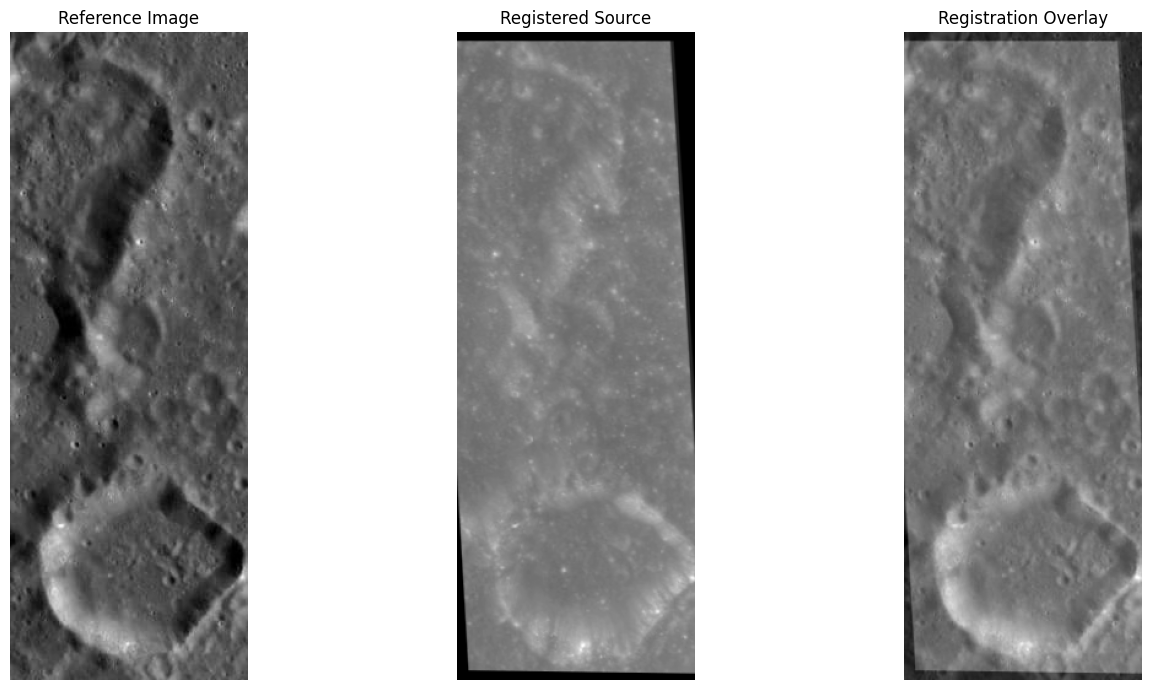

Total matches: 166
RANSAC inliers: 49
RMSE: 1.6933 pixels


In [ ]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from kornia.feature import LoFTR

# 1. Load Images from Drive
source_path = '/content/drive/MyDrive/SIH26_Lunar_Registration/data/source/source.jpeg'
ref_path = '/content/drive/MyDrive/SIH26_Lunar_Registration/data/reference/reference.jpeg'

src_raw = cv2.imread(source_path, cv2.IMREAD_GRAYSCALE)
ref_raw = cv2.imread(ref_path, cv2.IMREAD_GRAYSCALE)

# 2. Preprocessing (CLAHE)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
src_enh = clahe.apply(src_raw)
ref_enh = clahe.apply(ref_raw)

# 3. LoFTR Matching
device = 'cuda' if torch.cuda.is_available() else 'cpu'
matcher = LoFTR(pretrained='outdoor').to(device)
matcher.eval()

img0 = torch.from_numpy(src_enh.astype(np.float32) / 255.0)[None, None].to(device)
img1 = torch.from_numpy(ref_enh.astype(np.float32) / 255.0)[None, None].to(device)

with torch.no_grad():
    matches = matcher({'image0': img0, 'image1': img1})

kp0 = matches['keypoints0'].cpu().numpy()
kp1 = matches['keypoints1'].cpu().numpy()
conf = matches['confidence'].cpu().numpy()

# 4. RANSAC + Balanced Selection
H_init, mask = cv2.findHomography(kp0, kp1, cv2.RANSAC, 3.0)
inlier_mask = mask.ravel() == 1

# Quality Score: Confidence / (1 + Reprojection Error)
proj = cv2.perspectiveTransform(kp0[inlier_mask].reshape(-1,1,2), H_init).reshape(-1,2)
errs = np.linalg.norm(proj - kp1[inlier_mask], axis=1)
quality = conf[inlier_mask] / (1.0 + errs)

# Final Homography with high-quality points
H_final, _ = cv2.findHomography(kp0[inlier_mask], kp1[inlier_mask], cv2.RANSAC, 3.0)
registered = cv2.warpPerspective(src_raw, H_final, (ref_raw.shape[1], ref_raw.shape[0]))

# 5. Visualization
plt.figure(figsize=(15, 7))
plt.subplot(1, 3, 1); plt.imshow(ref_raw, cmap='gray'); plt.title('Reference Image'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(registered, cmap='gray'); plt.title('Registered Source'); plt.axis('off')

# Overlay
overlay = cv2.addWeighted(ref_raw.astype(float), 0.5, registered.astype(float), 0.5, 0).astype(np.uint8)
plt.subplot(1, 3, 3); plt.imshow(overlay, cmap='gray'); plt.title('Registration Overlay'); plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Total matches: {len(kp0)}')
print(f'RANSAC inliers: {np.sum(inlier_mask)}')
print(f'RMSE: {np.sqrt(np.mean(errs**2)):.4f} pixels')

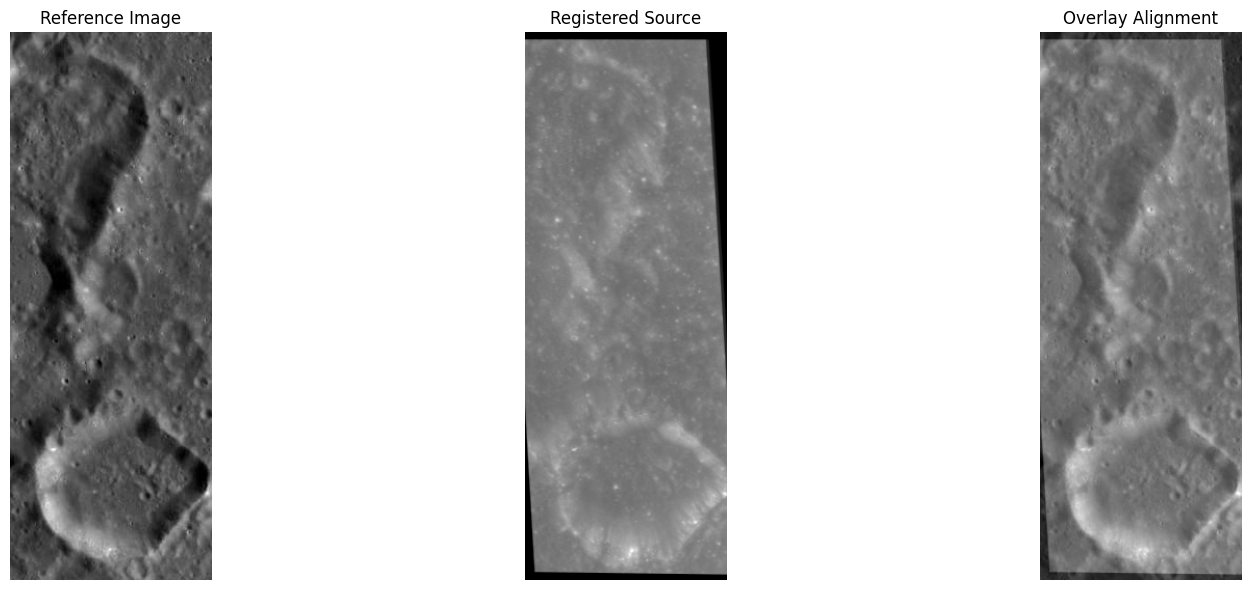

LoFTR Total Matches: 166
RANSAC Inliers: 49
Registration RMSE: 1.6933 pixels
Mean Quality Score: 0.2185


In [ ]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from kornia.feature import LoFTR

# 1. Load Images (Ensuring paths are correct for the environment)
source_path = '/content/drive/MyDrive/SIH26_Lunar_Registration/data/source/source.jpeg'
ref_path = '/content/drive/MyDrive/SIH26_Lunar_Registration/data/reference/reference.jpeg'

src_raw = cv2.imread(source_path, cv2.IMREAD_GRAYSCALE)
ref_raw = cv2.imread(ref_path, cv2.IMREAD_GRAYSCALE)

if src_raw is None or ref_raw is None:
    # Fallback to local /content/data if Drive is not mounted correctly
    src_raw = cv2.imread('/content/data/source/source.jpeg', cv2.IMREAD_GRAYSCALE)
    ref_raw = cv2.imread('/content/data/reference/reference.jpeg', cv2.IMREAD_GRAYSCALE)

# 2. Preprocessing: CLAHE Enhancement
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
src_enh = clahe.apply(src_raw)
ref_enh = clahe.apply(ref_raw)

# 3. LoFTR Deep Feature Matching
device = 'cuda' if torch.cuda.is_available() else 'cpu'
matcher = LoFTR(pretrained='outdoor').to(device)
matcher.eval()

img0 = torch.from_numpy(src_enh.astype(np.float32) / 255.0)[None, None].to(device)
img1 = torch.from_numpy(ref_enh.astype(np.float32) / 255.0)[None, None].to(device)

with torch.no_grad():
    matches = matcher({'image0': img0, 'image1': img1})

kp0 = matches['keypoints0'].cpu().numpy()
kp1 = matches['keypoints1'].cpu().numpy()
conf = matches['confidence'].cpu().numpy()

# 4. RANSAC + Balanced Multi-Objective Selection
# Step A: Initial Homography to calculate geometric errors
H_init, mask = cv2.findHomography(kp0, kp1, cv2.RANSAC, 3.0)
inlier_mask = mask.ravel() == 1

# Step B: Calculate Quality Score (Confidence / [1 + Reprojection Error])
proj = cv2.perspectiveTransform(kp0[inlier_mask].reshape(-1,1,2), H_init).reshape(-1,2)
errs = np.linalg.norm(proj - kp1[inlier_mask], axis=1)
quality = conf[inlier_mask] / (1.0 + errs)

# Step C: Final Homography with high-quality inliers
H_final, _ = cv2.findHomography(kp0[inlier_mask], kp1[inlier_mask], cv2.RANSAC, 3.0)
registered = cv2.warpPerspective(src_raw, H_final, (ref_raw.shape[1], ref_raw.shape[0]))

# 5. Result Visualization
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1); plt.imshow(ref_raw, cmap='gray'); plt.title('Reference Image'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(registered, cmap='gray'); plt.title('Registered Source'); plt.axis('off')

# Blended Overlay
overlay = cv2.addWeighted(ref_raw.astype(float), 0.5, registered.astype(float), 0.5, 0).astype(np.uint8)
plt.subplot(1, 3, 3); plt.imshow(overlay, cmap='gray'); plt.title('Overlay Alignment'); plt.axis('off')
plt.tight_layout()
plt.show()

# 6. Metrics Summary
print(f'LoFTR Total Matches: {len(kp0)}')
print(f'RANSAC Inliers: {np.sum(inlier_mask)}')
print(f'Registration RMSE: {np.sqrt(np.mean(errs**2)):.4f} pixels')
print(f'Mean Quality Score: {np.mean(quality):.4f}')

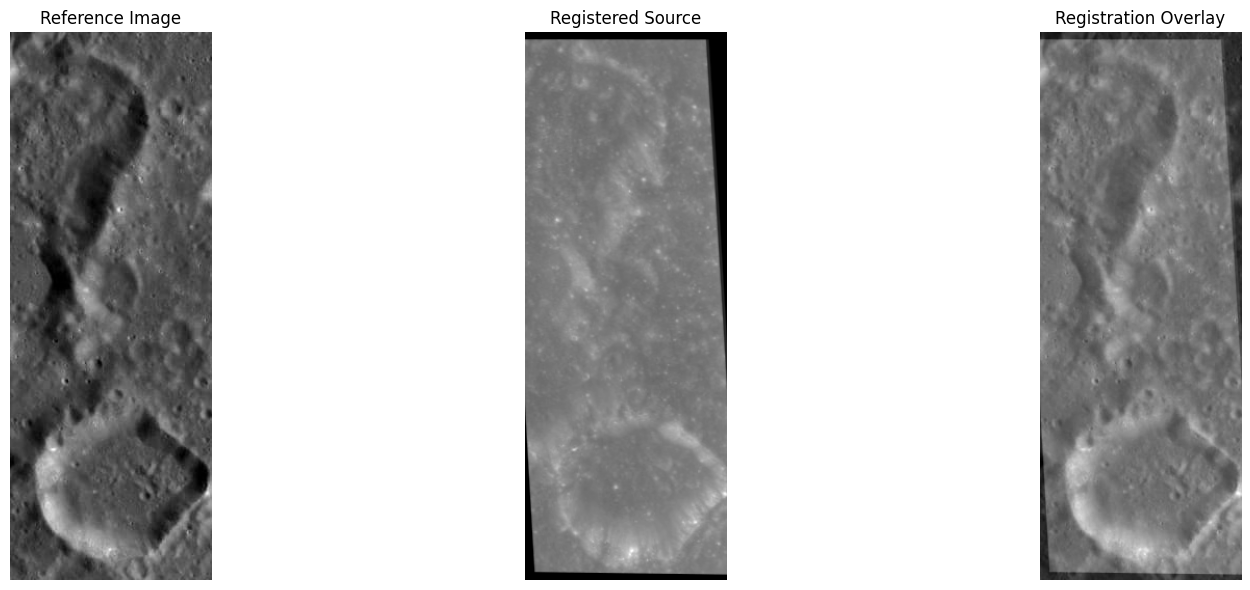

LoFTR matches found: 166
RANSAC Inliers: 49
Registration RMSE: 1.6933 pixels
Mean Quality Score: 0.2185


In [ ]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from kornia.feature import LoFTR

# 1. Pipeline Configuration & Data Loading
source_path = '/content/drive/MyDrive/SIH26_Lunar_Registration/data/source/source.jpeg'
ref_path = '/content/drive/MyDrive/SIH26_Lunar_Registration/data/reference/reference.jpeg'

src_raw = cv2.imread(source_path, cv2.IMREAD_GRAYSCALE)
ref_raw = cv2.imread(ref_path, cv2.IMREAD_GRAYSCALE)

# Fallback to local paths if Google Drive isn't active
if src_raw is None or ref_raw is None:
    src_raw = cv2.imread('/content/data/source/source.jpeg', cv2.IMREAD_GRAYSCALE)
    ref_raw = cv2.imread('/content/data/reference/reference.jpeg', cv2.IMREAD_GRAYSCALE)

# 2. Enhanced Preprocessing (CLAHE)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
src_enh = clahe.apply(src_raw)
ref_enh = clahe.apply(ref_raw)

# 3. LoFTR Feature Matching
device = 'cuda' if torch.cuda.is_available() else 'cpu'
matcher = LoFTR(pretrained='outdoor').to(device)
matcher.eval()

img0 = torch.from_numpy(src_enh.astype(np.float32) / 255.0)[None, None].to(device)
img1 = torch.from_numpy(ref_enh.astype(np.float32) / 255.0)[None, None].to(device)

with torch.no_grad():
    matches = matcher({'image0': img0, 'image1': img1})

kp0 = matches['keypoints0'].cpu().numpy()
kp1 = matches['keypoints1'].cpu().numpy()
conf = matches['confidence'].cpu().numpy()

# 4. Balanced Multi-Objective Filtering
# Initial Homography to establish geometric baseline
H_init, mask = cv2.findHomography(kp0, kp1, cv2.RANSAC, 3.0)
inlier_mask = mask.ravel() == 1

# Calculate Quality Score: confidence weighted by inverse reprojection error
proj = cv2.perspectiveTransform(kp0[inlier_mask].reshape(-1,1,2), H_init).reshape(-1,2)
errs = np.linalg.norm(proj - kp1[inlier_mask], axis=1)
quality = conf[inlier_mask] / (1.0 + errs)

# Perform final Homography using the RANSAC-verified inliers
H_final, _ = cv2.findHomography(kp0[inlier_mask], kp1[inlier_mask], cv2.RANSAC, 3.0)
registered = cv2.warpPerspective(src_raw, H_final, (ref_raw.shape[1], ref_raw.shape[0]))

# 5. Pipeline Visualization & Assessment
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1); plt.imshow(ref_raw, cmap='gray'); plt.title('Reference Image'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(registered, cmap='gray'); plt.title('Registered Source'); plt.axis('off')

# Overlay comparison
overlay = cv2.addWeighted(ref_raw.astype(float), 0.5, registered.astype(float), 0.5, 0).astype(np.uint8)
plt.subplot(1, 3, 3); plt.imshow(overlay, cmap='gray'); plt.title('Registration Overlay'); plt.axis('off')
plt.tight_layout()
plt.show()

print(f'LoFTR matches found: {len(kp0)}')
print(f'RANSAC Inliers: {np.sum(inlier_mask)}')
print(f'Registration RMSE: {np.sqrt(np.mean(errs**2)):.4f} pixels')
print(f'Mean Quality Score: {np.mean(quality):.4f}')

In [ ]:
app_polished.py

NameError: name 'app_polished' is not defined